# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Al Hadi Busra
- **Email:** alhadibusra1002@gmail.com
- **ID Dicoding:** alhadi78

## Menentukan Pertanyaan Bisnis



```
# This is formatted as code
```

- Faktor apa saja yang paling berpengaruh terhadap kepuasan pelanggan (review score) pada platform e-commerce ?
- Karakteristik pelanggan seperti apa yang memberikan nilai transaksi tertinggi, dan bagaimana pola perilaku belanjanya ?

## Import Semua Packages/Library yang Digunakan

In [1]:
# Menginstal library gdown untuk mengunduh file dari Google Drive.
!pip install gdown

In [2]:
# ==============================
# 1. Data Acquisition & File Handling
# ==============================
import gdown              # Mengunduh dataset dari Google Drive
import zipfile            # Mengekstrak file ZIP
import os                 # Manajemen direktori dan file sistem
import requests           # Mengambil data dari API atau URL

# ==============================
# 2. Data Manipulation & Analysis
# ==============================
import pandas as pd       # Manipulasi dan analisis data tabular
import numpy as np        # Operasi numerik dan array

# ==============================
# 3. Data Visualization
# ==============================
import matplotlib.pyplot as plt   # Visualisasi dasar (plot, line, bar, dll.)
import seaborn as sns             # Visualisasi statistik tingkat lanjut
import matplotlib.ticker as mticker # Formatting sumbu (ribuan, juta, desimal)

# ==============================
# 4. Geospatial Analysis & Visualization
# ==============================
import sys
!{sys.executable} -m pip install geopandas  # Instalasi geopandas (jika belum tersedia)

import geopandas as gpd   # Analisis dan visualisasi data berbasis peta/geospasial

# ==============================
# 5. System Utilities
# ==============================
import sys                # Akses konfigurasi dan environment Python

## Data Wrangling

### Gathering Data

In [3]:
# URL file Google Drive yang akan diunduh
url = "https://drive.google.com/uc?id=1MsAjPM7oKtVfJL_wRp1qmCajtSG1mdcK"

# Nama file hasil unduhan (format ZIP)
output = "ecommerce_dataset.zip"

# Mengunduh file dari Google Drive dan menyimpannya dengan nama yang ditentukan
# quiet=False agar proses download dan progres ditampilkan di layar
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1MsAjPM7oKtVfJL_wRp1qmCajtSG1mdcK
From (redirected): https://drive.google.com/uc?id=1MsAjPM7oKtVfJL_wRp1qmCajtSG1mdcK&confirm=t&uuid=93da3b2d-695f-4c77-87f6-90a1ffcfd4bb
To: /content/ecommerce_dataset.zip
100%|██████████| 44.9M/44.9M [00:01<00:00, 26.7MB/s]


'ecommerce_dataset.zip'

In [4]:
# Menentukan path file ZIP yang akan diekstrak
zip_path = "ecommerce_dataset.zip"

# Menentukan folder tujuan hasil ekstraksi
extract_path = "data/raw"

# Membuat folder tujuan jika belum ada
os.makedirs(extract_path, exist_ok=True)

# Membuka dan mengekstrak seluruh isi file ZIP ke folder tujuan
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Menampilkan pesan bahwa proses ekstraksi telah selesai
print("Ekstraksi selesai!")

Ekstraksi selesai!


In [5]:
# Menentukan path folder yang berisi file dataset CSV
DATA_PATH = "data/raw/E-Commerce Public Dataset"

# Dictionary untuk menyimpan seluruh dataset yang dimuat
datasets = {}

# Melakukan iterasi pada setiap file di dalam folder DATA_PATH
for file in os.listdir(DATA_PATH):
    # Memproses hanya file dengan ekstensi .csv
    if file.endswith(".csv"):
        # Mengambil nama file tanpa ekstensi sebagai key dictionary
        name = file.replace(".csv", "")

        # Membaca file CSV dan menyimpannya ke dalam dictionary datasets
        datasets[name] = pd.read_csv(os.path.join(DATA_PATH, file))

        # Menampilkan nama dataset dan ukurannya (baris, kolom)
        print(f"{name} loaded with shape {datasets[name].shape}")

order_reviews_dataset loaded with shape (99224, 7)
customers_dataset loaded with shape (99441, 5)
products_dataset loaded with shape (32951, 9)
product_category_name_translation loaded with shape (71, 2)
order_payments_dataset loaded with shape (103886, 5)
order_items_dataset loaded with shape (112650, 7)
geolocation_dataset loaded with shape (1000163, 5)
sellers_dataset loaded with shape (3095, 4)
orders_dataset loaded with shape (99441, 8)


Insight (Gathering Data):
-   Data berhasil diunduh dari Google Drive dalam format ZIP (`ecommerce_dataset.zip`).
-   File ZIP berhasil diekstrak ke folder `data/raw/E-Commerce Public Dataset`.
-   Sembilan dataset CSV berhasil dimuat ke dalam dictionary `datasets` sebagai pandas DataFrame, yang siap untuk tahap *assessing* dan *cleaning* lebih lanjut. Semua dataset telah dimuat dengan informasi *shape* masing-nya.

### Assessing Data

#### Data Overview (Struktur & Tipe Data)

In [6]:
# Fungsi untuk menampilkan gambaran umum sebuah dataset
def data_overview(df, name):
    # Menampilkan nama dataset
    print(f"\n=== Dataset: {name} ===")

    # Menampilkan 5 baris pertama dataset
    display(df.head())

    # Menampilkan informasi struktur data (tipe data & jumlah non-null)
    print("\nInfo:")
    df.info()

    # Menampilkan ukuran dataset (jumlah baris, kolom)
    print("\nShape:", df.shape)

# Melakukan overview untuk setiap dataset yang ada dalam dictionary datasets
for name, df in datasets.items():
    data_overview(df, name)


=== Dataset: order_reviews_dataset ===


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB

Shape: (99224, 7)

=== Dataset: customers_dataset ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

Shape: (99441, 5)

=== Dataset: products_dataset ===


...


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB

Shape: (1000163, 5)

=== Dataset: sellers_dataset ===


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

Shape: (3095, 4)

=== Dataset: orders_dataset ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Shape: (99441, 8)


Insight (Data Overview - Struktur & Tipe Data):
-   **order_reviews_dataset**: Terdiri dari 99.224 entri dan 7 kolom. Kolom `review_comment_title`, `review_comment_message` memiliki banyak *missing values*. `review_creation_date` dan `review_answer_timestamp` perlu dikonversi ke tipe `datetime`.
-   **products_dataset**: Terdiri dari 32.951 entri dan 9 kolom. Beberapa kolom seperti `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty`, `product_weight_g`, `product_length_cm`, `product_height_cm`, dan `product_width_cm` memiliki *missing values*. Tipe data numerik sebagian besar sudah benar (`float64`), kecuali `product_id` dan `product_category_name` yang bertipe `object`.
-   **geolocation_dataset**: Terdiri dari 1.000.163 entri dan 5 kolom. Tidak ada *missing values*. Tipe data (`int64` untuk zip code, `float64` untuk lat/lng, `object` untuk city/state) sudah sesuai.
-   **order_payments_dataset**: Terdiri dari 103.886 entri dan 5 kolom. Tidak ada *missing values*. Tipe data (`int64` untuk sequential/installments, `float64` untuk value, `object` untuk type) sudah sesuai.
-   **sellers_dataset**: Terdiri dari 3.095 entri dan 4 kolom. Tidak ada *missing values*. Tipe data (`int64` untuk zip code, `object` untuk id/city/state) sudah sesuai.
-   **customers_dataset**: Terdiri dari 99.441 entri dan 5 kolom. Tidak ada *missing values*. Tipe data (`int64` untuk zip code, `object` untuk id/unique_id/city/state) sudah sesuai.
-   **orders_dataset**: Terdiri dari 99.441 entri dan 8 kolom. Kolom-kolom tanggal seperti `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` memiliki *missing values* dan perlu dikonversi ke tipe `datetime`.
-   **product_category_name_translation**: Terdiri dari 71 entri dan 2 kolom. Tidak ada *missing values*. Tipe data (`object`) sudah sesuai.
-   **order_items_dataset**: Terdiri dari 112.650 entri dan 7 kolom. Kolom `shipping_limit_date` perlu dikonversi ke tipe `datetime`. Tidak ada *missing values* lainnya.

#### Missing Value Analysis

In [7]:
# Fungsi untuk menghitung ringkasan missing value pada sebuah dataset
def missing_value_summary(df):
    # Menghitung jumlah nilai kosong pada setiap kolom
    missing = df.isnull().sum()

    # Menghitung persentase missing value terhadap total baris data
    missing_percent = (missing / len(df)) * 100

    # Menggabungkan hasil ke dalam DataFrame ringkasan
    summary = pd.DataFrame({
        'missing_count': missing,
        'missing_percent': missing_percent
    })

    # Menampilkan hanya kolom yang memiliki missing value
    # serta mengurutkannya berdasarkan persentase tertinggi
    return summary[summary['missing_count'] > 0].sort_values(
        by='missing_percent', ascending=False
    )

# Menampilkan ringkasan missing value untuk setiap dataset
for name, df in datasets.items():
    print(f"\nMissing Values in {name}")
    display(missing_value_summary(df))


Missing Values in order_reviews_dataset


,missing_count,missing_percent
review_comment_title,87656,88.341530
review_comment_message,58247,58.702532



Missing Values in customers_dataset


,missing_count,missing_percent



Missing Values in products_dataset


...

,missing_count,missing_percent



Missing Values in sellers_dataset


,missing_count,missing_percent



Missing Values in orders_dataset


,missing_count,missing_percent
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


Insight (Missing Value Analysis):
-   **order_reviews_dataset**: `review_comment_title` (88.35% hilang) dan `review_comment_message` (58.62% hilang) memiliki jumlah *missing values* yang sangat tinggi. Ini menunjukkan bahwa sebagian besar pelanggan tidak mengisi judul atau pesan ulasan.
-   **products_dataset**: `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty` memiliki sekitar 1.85% *missing values*. `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` memiliki jumlah *missing values* yang sangat sedikit (0.01%). *Missing values* ini perlu ditangani, mungkin dengan imputasi atau penghapusan tergantung konteks.
-   **orders_dataset**: `order_delivered_customer_date` (3.0% hilang), `order_delivered_carrier_date` (1.8% hilang), dan `order_approved_at` (0.16% hilang) memiliki *missing values*. Ini mungkin mengindikasikan pesanan yang belum terkirim, dibatalkan, atau belum sepenuhnya disetujui.

#### Duplicate Check

In [8]:
# Mengecek jumlah baris duplikat pada setiap dataset
for name, df in datasets.items():
    # Menghitung jumlah baris yang terduplikasi
    dup_count = df.duplicated().sum()

    # Menampilkan nama dataset dan jumlah baris duplikat
    print(f"{name} - duplicated rows: {dup_count}")

order_reviews_dataset - duplicated rows: 0
customers_dataset - duplicated rows: 0
products_dataset - duplicated rows: 0
product_category_name_translation - duplicated rows: 0
order_payments_dataset - duplicated rows: 0
order_items_dataset - duplicated rows: 0
geolocation_dataset - duplicated rows: 261831
sellers_dataset - duplicated rows: 0
orders_dataset - duplicated rows: 0


Insight (Duplicate Check):
-   Hanya `geolocation_dataset` yang memiliki duplikasi baris yang signifikan (261.831 duplikat). Ini perlu ditangani, karena duplikasi tersebut dapat mempengaruhi akurasi analisis geografis jika tidak dibersihkan. Dataset lainnya tidak memiliki duplikasi baris.

#### Descriptive Statistics (Numerik)

In [9]:
# Menampilkan statistik deskriptif untuk setiap dataset
for name, df in datasets.items():
    # Menampilkan nama dataset
    print(f"\nDescriptive Statistics: {name}")

    # Menampilkan ringkasan statistik (count, mean, std, min, max, dll.)
    # untuk kolom numerik dalam dataset
    display(df.describe())


Descriptive Statistics: order_reviews_dataset


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000



Descriptive Statistics: customers_dataset


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000



Descriptive Statistics: products_dataset


...

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02



Descriptive Statistics: sellers_dataset


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000



Descriptive Statistics: orders_dataset


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


Insight (Descriptive Statistics - Numerik):
-   **order_reviews_dataset**: `review_score` memiliki rata-rata 4.09, dengan sebagian besar skor berada di atas 3 (median 5, 75% quartile 5). Menunjukkan kepuasan pelanggan yang umumnya tinggi.
-   **products_dataset**: `product_name_lenght`, `product_description_lenght`, `product_photos_qty` menunjukkan rentang nilai yang bervariasi. `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` juga memiliki rentang yang luas, dengan potensi *outlier* yang sangat besar (terutama pada `product_weight_g`).
-   **geolocation_dataset**: `geolocation_zip_code_prefix` menunjukkan rentang kode pos yang luas. Koordinat lat/lng menunjukkan distribusi geografis yang beragam.
-   **order_payments_dataset**: `payment_installments` memiliki rata-rata 2.85 kali, dengan maksimum 24. `payment_value` memiliki rata-rata 154.10, dengan nilai maksimum sangat tinggi (13664.08), mengindikasikan adanya pesanan bernilai tinggi.
-   **sellers_dataset**: `seller_zip_code_prefix` menunjukkan distribusi geografis penjual yang luas.
-   **customers_dataset**: `customer_zip_code_prefix` menunjukkan distribusi geografis pelanggan yang luas.
-   **order_items_dataset**: `price` memiliki rata-rata 120.65 dengan maksimum 6735. `freight_value` rata-rata 19.99 dengan maksimum 409.68. `order_item_id` memiliki rata-rata 1.19, menunjukkan bahwa sebagian besar pesanan hanya memiliki satu item atau beberapa item saja.

#### Unique Value Check (Categorical Columns)

In [10]:
# Fungsi untuk merangkum kolom kategorikal dalam dataset
def categorical_summary(df):
    # Mengambil kolom bertipe data object (kategorikal)
    cat_cols = df.select_dtypes(include='object').columns

    summary = {}
    # Menghitung jumlah nilai unik pada setiap kolom kategorikal
    for col in cat_cols:
        summary[col] = df[col].nunique()

    # Mengubah hasil ringkasan menjadi DataFrame
    # dan mengurutkannya berdasarkan jumlah nilai unik terbanyak
    return pd.DataFrame.from_dict(
        summary, orient='index', columns=['unique_values']
    ).sort_values(by='unique_values', ascending=False)

# Menampilkan ringkasan kolom kategorikal untuk setiap dataset
for name, df in datasets.items():
    print(f"\nCategorical Summary: {name}")
    display(categorical_summary(df))


Categorical Summary: order_reviews_dataset


,unique_values
order_id,98673
review_id,98410
review_answer_timestamp,98248
review_comment_message,36159
review_comment_title,4527
review_creation_date,636



Categorical Summary: customers_dataset


,unique_values
customer_id,99441
customer_unique_id,96096
customer_city,4119
customer_state,27



Categorical Summary: products_dataset


...

,unique_values
geolocation_city,8011
geolocation_state,27



Categorical Summary: sellers_dataset


,unique_values
seller_id,3095
seller_city,611
seller_state,23



Categorical Summary: orders_dataset


,unique_values
order_id,99441
customer_id,99441
order_purchase_timestamp,98875
order_delivered_customer_date,95664
order_approved_at,90733
order_delivered_carrier_date,81018
order_estimated_delivery_date,459
order_status,8


Insight (Unique Value Check - Categorical Columns):
-   **order_reviews_dataset**: `review_id` dan `order_id` memiliki jumlah unik yang tinggi, sesuai sebagai *identifier*. `review_comment_title` dan `review_comment_message` juga memiliki banyak nilai unik, tetapi banyak yang hilang.
-   **products_dataset**: `product_id` adalah unik. `product_category_name` memiliki 73 kategori unik.
-   **geolocation_dataset**: `geolocation_city` dan `geolocation_state` menunjukkan banyak kota dan negara bagian yang berbeda, yang diharapkan untuk data geografis.
-   **order_payments_dataset**: `order_id` adalah unik. `payment_type` hanya memiliki 5 nilai unik (misalnya, `credit_card`, `boleto`, `voucher`).
-   **sellers_dataset**: `seller_id` adalah unik. `seller_city` dan `seller_state` menunjukkan banyak lokasi penjual yang berbeda.
-   **customers_dataset**: `customer_id` dan `customer_unique_id` adalah unik. `customer_city` dan `customer_state` menunjukkan banyak lokasi pelanggan yang berbeda.
-   **orders_dataset**: `order_id`, `customer_id`, `order_status` (8 status unik) semuanya terlihat sesuai. Kolom `timestamp` juga sesuai.
-   **product_category_name_translation**: `product_category_name` (71 unik) dan `product_category_name_english` (71 unik) adalah unik dan berfungsi sebagai tabel master untuk terjemahan kategori.
-   **order_items_dataset**: `order_id`, `product_id`, `seller_id` memiliki banyak nilai unik, yang wajar untuk transaksi individual.

#### Datetime Conversion Check

In [11]:
# Fungsi untuk mengonversi kolom bertipe tanggal/waktu menjadi datetime
def convert_datetime(df):
    # Melakukan iterasi pada setiap kolom dalam DataFrame
    for col in df.columns:
        # Mengecek nama kolom yang mengandung kata 'date' atau 'time'
        if 'date' in col.lower() or 'time' in col.lower():
            try:
                # Mengonversi kolom menjadi tipe datetime
                df[col] = pd.to_datetime(df[col])
                print(f"Converted {col} to datetime")
            except:
                # Melewati kolom jika konversi gagal
                pass
    return df

# Menerapkan konversi datetime ke seluruh dataset dalam dictionary
for name in datasets:
    datasets[name] = convert_datetime(datasets[name])

Converted review_creation_date to datetime
Converted review_answer_timestamp to datetime
Converted shipping_limit_date to datetime
Converted order_purchase_timestamp to datetime
Converted order_delivered_carrier_date to datetime
Converted order_delivered_customer_date to datetime
Converted order_estimated_delivery_date to datetime


Insight (Datetime Conversion Check):
-   Semua kolom yang diidentifikasi sebagai tanggal (`review_creation_date`, `review_answer_timestamp`, `order_purchase_timestamp`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`, `shipping_limit_date`) berhasil dikonversi ke tipe data `datetime`. Ini adalah langkah penting untuk analisis deret waktu dan perhitungan durasi.

#### Validasi Logika Dasar (Contoh Orders)

In [12]:
# Mengecek apakah dataset orders tersedia
if "orders_dataset" in datasets:
    # Mengambil dataset orders
    orders = datasets["orders_dataset"]

    # Mengidentifikasi data tidak valid
    # yaitu tanggal pengiriman lebih awal daripada tanggal pembelian
    invalid_delivery = orders[
        orders['order_delivered_customer_date'] < orders['order_purchase_timestamp']
    ]

    # Menampilkan jumlah record dengan anomali waktu pengiriman
    print("Invalid delivery records:", invalid_delivery.shape[0])

Invalid delivery records: 0


Insight (Validasi Logika Dasar - Contoh Orders):
-   Pemeriksaan validitas logika dasar menunjukkan bahwa tidak ada catatan pengiriman yang invalid (`order_delivered_customer_date` lebih awal dari `order_purchase_timestamp`). Ini mengindikasikan konsistensi data waktu pengiriman yang baik.

#### Insight (Assessing Data)


-   **Struktur dan Tipe Data**: Sebagian besar dataset memiliki struktur yang jelas dengan tipe data yang umumnya sesuai. Beberapa kolom tanggal (`review_creation_date`, `review_answer_timestamp`, `order_purchase_timestamp`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`, `shipping_limit_date`) telah berhasil dikonversi ke tipe `datetime`.
-   **Missing Values**: Ditemukan *missing values* yang signifikan pada kolom `review_comment_title` dan `review_comment_message` di `order_reviews_dataset`, serta pada kolom-kolom terkait detail produk di `products_dataset`, dan tanggal pengiriman di `orders_dataset`. Ini perlu ditangani secara kontekstual pada tahap *cleaning*.
-   **Duplikasi Data**: Hanya `geolocation_dataset` yang memiliki duplikasi baris yang signifikan (261.831 duplikat), yang memerlukan penghapusan untuk menghindari bias dalam analisis geografis. Dataset lain bersih dari duplikasi.
-   **Statistik Deskriptif**: Variabel numerik menunjukkan rentang nilai yang luas dan beberapa potensi *outlier* (misalnya pada `product_weight_g`, `payment_value`, `total_price`, `total_freight`, `delivery_time_days`). `review_score` menunjukkan kepuasan pelanggan yang umumnya tinggi, dengan sebagian besar skor 4 atau 5.
-   **Nilai Unik Kategorikal**: Kolom kategorikal seperti `payment_type` dan `order_status` memiliki nilai unik yang konsisten, sementara kolom `product_category_name` memiliki 73 kategori unik yang berpotensi untuk analisis lebih lanjut.
-   **Validasi Logika Dasar**: Pemeriksaan awal tidak menemukan anomali logis pada tanggal pengiriman (`order_delivered_customer_date` tidak lebih awal dari `order_purchase_timestamp`), menunjukkan konsistensi dasar data waktu.

Secara keseluruhan, data memiliki kualitas yang cukup baik, tetapi beberapa area memerlukan perhatian khusus (penanganan *missing values* dan duplikasi) sebelum analisis mendalam.

### Cleaning Data

#### Copy Data (Menjaga Raw Data Tetap Utuh)

In [13]:
# Membuat salinan seluruh dataset sebagai versi data yang sudah/akan dibersihkan
cleaned = {name: df.copy() for name, df in datasets.items()}

Insight (Copy Data):
-   Langkah penyalinan dataset (`cleaned = {name: df.copy() for name, df in datasets.items()}`) adalah praktik terbaik dalam data wrangling. Ini memastikan bahwa data mentah asli (`datasets`) tetap tidak berubah, memungkinkan untuk kembali ke kondisi awal jika ada kesalahan dalam proses pembersihan atau jika analisis lain memerlukan data asli. Ini penting untuk menjaga integritas data dan kemampuan reproduksi analisis.

#### Standardisasi Nama Kolom

In [14]:
# Mengubah seluruh nama kolom menjadi huruf kecil pada setiap dataset
for name, df in cleaned.items():
    df.columns = df.columns.str.lower()

# Menampilkan contoh hasil perubahan nama kolom
print("Contoh DataFrame setelah mengubah nama kolom menjadi huruf kecil (misalnya orders_dataset):")
display(cleaned["orders_dataset"].head())

Contoh DataFrame setelah mengubah nama kolom menjadi huruf kecil (misalnya orders_dataset):


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


Insight (Standardisasi Nama Kolom):
-   Mengubah semua nama kolom menjadi huruf kecil (`df.columns = df.columns.str.lower()`) adalah langkah standardisasi yang sangat baik. Ini meningkatkan konsistensi dan kemudahan dalam penulisan kode, mencegah kesalahan ketik karena perbedaan kapitalisasi, dan membuat kode lebih mudah dibaca serta dipelihara di masa mendatang.

#### Handling Missing Values (Kontekstual)

In [15]:
# Mengambil dataset orders yang sudah dibersihkan
orders = cleaned["orders_dataset"]

# Mengonversi kolom tanggal pengiriman ke tipe datetime
# errors='coerce' akan mengubah nilai tidak valid menjadi NaT
orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date'], errors='coerce'
)

# Menampilkan contoh DataFrame setelah proses konversi
print("DataFrame orders setelah konversi order_delivered_customer_date:")
display(orders.head())

DataFrame orders setelah konversi order_delivered_customer_date:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [16]:
# Mengambil dataset ulasan pelanggan
reviews = cleaned["order_reviews_dataset"]

# Menampilkan data sebelum penanganan missing value
print("DataFrame reviews sebelum mengisi nilai yang hilang di review_comment_message:")
display(reviews.head())

# Mengisi nilai kosong pada kolom review_comment_message
# Missing value diasumsikan sebagai pelanggan tidak memberikan komentar
reviews['review_comment_message'] = reviews['review_comment_message'].fillna("No Comment")

# Menampilkan data setelah penanganan missing value
print("DataFrame reviews setelah mengisi nilai yang hilang di review_comment_message:")
display(reviews.head())

DataFrame reviews sebelum mengisi nilai yang hilang di review_comment_message:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


DataFrame reviews setelah mengisi nilai yang hilang di review_comment_message:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,No Comment,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,No Comment,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,No Comment,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


Insight (Handling Missing Values - Kontekstual):
-   **Kolom `order_delivered_customer_date` pada `orders_dataset`**: Penggunaan `pd.to_datetime(..., errors='coerce')` memungkinkan konversi kolom tanggal ke format datetime sambil secara otomatis mengubah nilai yang tidak valid atau *missing values* menjadi `NaT` (Not a Time). Ini penting karena *missing values* di kolom tanggal pengiriman seringkali mengindikasikan pesanan yang belum selesai, dibatalkan, atau dalam proses, dan penanganan ini menjaga konsistensi tipe data.
-   **Kolom `review_comment_message` pada `order_reviews_dataset`**: Mengisi *missing values* dengan 'No Comment' (`reviews['review_comment_message'].fillna('No Comment')`) adalah pendekatan yang tepat untuk kolom komentar. Ini secara eksplisit menyatakan bahwa tidak ada komentar yang diberikan oleh pelanggan, daripada meninggalkan nilai kosong yang dapat diartikan secara ambigu. Pendekatan ini menjaga semua baris dan memungkinkan analisis lebih lanjut, misalnya, membandingkan skor ulasan dari pesanan dengan dan tanpa komentar.

#### Feature Engineering Dasar

##### Delivery Time

In [17]:
# Menghitung lama waktu pengiriman (dalam hari)
orders['delivery_time_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

# Menampilkan DataFrame orders setelah penambahan fitur baru
print("DataFrame orders setelah menambahkan kolom delivery_time_days:")
display(orders.head())

DataFrame orders setelah menambahkan kolom delivery_time_days:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0


Insight (Feature Engineering Dasar - Delivery Time):
-   Pembuatan fitur `delivery_time_days` dengan menghitung selisih hari antara `order_delivered_customer_date` dan `order_purchase_timestamp` (`(orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days`) adalah langkah *feature engineering* yang sangat berguna. Fitur ini secara langsung mengukur durasi pengiriman, yang merupakan metrik kunci dalam kepuasan pelanggan dan dapat digunakan untuk analisis lebih lanjut tentang efisiensi logistik atau korelasi dengan *review score*.

##### Integrasi Orders + Customers

In [18]:
# Menggabungkan dataset orders dengan dataset customers
# berdasarkan customer_id menggunakan left join
orders_customers = orders.merge(
    cleaned["customers_dataset"],
    on="customer_id",
    how="left"
)

# Menampilkan ukuran dataset hasil penggabungan
print("orders_customers shape:", orders_customers.shape)

# Menampilkan contoh data hasil merge
print("Head of orders_customers:")
display(orders_customers.head())

orders_customers shape: (99441, 13)
Head of orders_customers:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


Insight (Feature Engineering Dasar - Integrasi Orders + Customers):
-   Penggabungan `orders` dan `customers_dataset` ke dalam `orders_customers` menggunakan `customer_id` (`orders.merge(cleaned["customers_dataset"], on="customer_id", how="left")`) adalah langkah fundamental untuk menggabungkan informasi pesanan dengan demografi pelanggan. Ini memungkinkan analisis perilaku pelanggan berdasarkan lokasi atau ID unik mereka. Penggunaan `how='left'` memastikan semua pesanan dari `orders` dipertahankan.

##### Integrasi Order Items + Products + Category

In [19]:
# Mengambil dataset item pesanan, produk, dan terjemahan kategori produk
order_items = cleaned["order_items_dataset"]
products = cleaned["products_dataset"]
categories = cleaned["product_category_name_translation"]

# Menggabungkan data item pesanan dengan informasi produk
# lalu menambahkan terjemahan nama kategori produk
items_products = (
    order_items
    .merge(products, on="product_id", how="left")
    .merge(categories, on="product_category_name", how="left")
)

# Menampilkan ukuran dataset hasil penggabungan
print("items_products shape:", items_products.shape)

# Menampilkan contoh data hasil merge
print("Head of items_products:")
display(items_products.head())

items_products shape: (112650, 16)
Head of items_products:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


Insight (Feature Engineering Dasar - Integrasi Order Items + Products + Category):
-   Penggabungan tiga dataset (`order_items`, `products`, `categories`) ke dalam `items_products` adalah langkah krusial untuk menganalisis karakteristik produk dalam setiap pesanan. Dengan menghubungkan `order_items` ke detail produk (`products`) dan kemudian ke nama kategori dalam bahasa Inggris (`categories`), kita dapat menganalisis preferensi produk, kinerja kategori, dan hubungan antara jenis produk dengan metrik lainnya seperti *review score* atau nilai pesanan.

##### Integrasi Seller Information

In [20]:
# Menggabungkan dataset items_products dengan informasi penjual
# berdasarkan seller_id menggunakan left join
items_products_sellers = items_products.merge(
    cleaned["sellers_dataset"],
    on="seller_id",
    how="left"
)

# Menampilkan ukuran dataset hasil penggabungan
print("items_products_sellers shape:", items_products_sellers.shape)

# Menampilkan contoh data hasil merge
print("Head of items_products_sellers:")
display(items_products_sellers.head())

items_products_sellers shape: (112650, 19)
Head of items_products_sellers:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,87900,loanda,PR


Insight (Feature Engineering Dasar - Integrasi Seller Information):
-   Menggabungkan `items_products` dengan `sellers_dataset` ke dalam `items_products_sellers` memungkinkan kita untuk menganalisis data pesanan hingga ke tingkat penjual. Informasi ini penting untuk mengevaluasi kinerja penjual, dampak lokasi penjual pada pengiriman, atau untuk memahami dinamika pasar di antara berbagai penjual.

##### Agregasi ke Level Order

In [21]:
# Menghitung ringkasan nilai dan kompleksitas setiap pesanan
order_value = (
    items_products_sellers
    .groupby("order_id")
    .agg(
        # Total harga produk dalam satu pesanan
        total_price=("price", "sum"),

        # Total biaya pengiriman dalam satu pesanan
        total_freight=("freight_value", "sum"),

        # Jumlah item dalam satu pesanan
        total_items=("order_item_id", "count"),

        # Jumlah produk unik dalam satu pesanan
        unique_products=("product_id", "nunique"),

        # Jumlah penjual unik dalam satu pesanan
        unique_sellers=("seller_id", "nunique")
    )
    .reset_index()
)

# Menampilkan contoh data hasil agregasi
print("Head of aggregated order_value:")
display(order_value.head())

Head of aggregated order_value:


,order_id,total_price,total_freight,total_items,unique_products,unique_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,1,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,1,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,1,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,1,1


Insight (Feature Engineering Dasar - Agregasi ke Level Order):
-   Agregasi `items_products_sellers` ke level `order_id` untuk mendapatkan `order_value` dengan metrik seperti `total_price`, `total_freight`, `total_items`, `unique_products`, dan `unique_sellers` adalah langkah penting dalam menyiapkan data untuk analisis tingkat pesanan. Ini mengubah data dari detail item menjadi ringkasan per pesanan, memungkinkan untuk menganalisis nilai total pesanan, kompleksitas (jumlah item/penjual), dan biaya pengiriman secara keseluruhan.

##### Gabungkan ke Master Order Table

In [22]:
# Membentuk dataset master_orders sebagai data transaksi terintegrasi
master_orders = (
    # Menggabungkan data pesanan + pelanggan dengan nilai dan kompleksitas order
    orders_customers
    .merge(order_value, on="order_id", how="left")

    # Menambahkan informasi pembayaran (total nilai & jumlah metode pembayaran)
    .merge(
        cleaned["order_payments_dataset"]
        .groupby("order_id")
        .agg(
            payment_value=("payment_value", "sum"),
            payment_types=("payment_type", "nunique")
        )
        .reset_index(),
        on="order_id",
        how="left"
    )

    # Menambahkan skor ulasan pelanggan
    .merge(
        cleaned["order_reviews_dataset"][[ # Memilih hanya kolom yang diperlukan dari dataset ulasan
            "order_id", "review_score"
        ]],
        on="order_id",
        how="left"
    )
)

# Menampilkan ukuran dan contoh dataset akhir
print("Final master_orders shape:", master_orders.shape)
print("Head of final master_orders:")
display(master_orders.head())

Final master_orders shape: (99992, 21)
Head of final master_orders:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,customer_unique_id,...,customer_city,customer_state,total_price,total_freight,total_items,unique_products,unique_sellers,payment_value,payment_types,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,...,sao paulo,SP,29.99,8.72,1.0,1.0,1.0,38.71,2.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,af07308b275d755c9edb36a90c618231,...,barreiras,BA,118.70,22.76,1.0,1.0,1.0,141.46,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,3a653a41f6f9fc3d2a113cf8398680e8,...,vianopolis,GO,159.90,19.22,1.0,1.0,1.0,179.12,1.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,7c142cf63193a1473d2e66489a9ae977,...,sao goncalo do amarante,RN,45.00,27.20,1.0,1.0,1.0,72.20,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,72632f0f9dd73dfee390c9b22eb56dd6,...,santo andre,SP,19.90,8.72,1.0,1.0,1.0,28.62,1.0,5.0


Insight (Feature Engineering Dasar - Gabungkan ke Master Order Table - Percobaan Awal):
-   Penggabungan `orders_customers`, `order_value`, `order_payments_dataset`, dan `order_reviews_dataset` secara berurutan bertujuan untuk membuat tabel master `master_orders` yang komprehensif. Tujuan dari langkah ini adalah untuk menyatukan semua informasi relevan (pesanan, pelanggan, nilai produk, pembayaran, ulasan) ke dalam satu *DataFrame* untuk analisis. Namun, `master_orders` dengan 99.992 baris menunjukkan adanya peningkatan jumlah baris dari `orders_customers` yang 99.441 baris, mengindikasikan potensi duplikasi data atau penggandaan karena operasi *join*, terutama dari `order_reviews_dataset` yang mungkin memiliki beberapa ulasan per pesanan, sehingga perlu penanganan lebih lanjut.

##### Validasi Setelah Join

In [23]:
# Menentukan kolom-kolom penting (critical columns) untuk analisis
critical_cols = [
    "order_id", "customer_id", "order_status",
    "payment_value", "review_score"
]

# Mengecek jumlah missing value pada kolom-kolom utama
master_orders[critical_cols].isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
payment_value,1
review_score,768


Insight (Validasi Setelah Join - Percobaan Awal):
-   Pemeriksaan `isnull().sum()` pada kolom-kolom utama (`order_id`, `customer_id`, `order_status`, `payment_value`, `review_score`) setelah *join* awal menunjukkan bahwa ada 1 *missing value* pada `payment_value` dan 768 *missing values* pada `review_score`. Meskipun sebagian besar kolom utama sudah lengkap, adanya *missing value* pada `payment_value` dan jumlah *missing value* yang signifikan pada `review_score` mengindikasikan bahwa proses *join* mungkin belum sempurna atau ada data yang memang tidak ada (misalnya, pesanan tidak ada pembayaran atau ulasan). Selain itu, masalah duplikasi `order_id` yang terdeteksi kemudian menunjukkan bahwa *missing values* ini mungkin terkait dengan cara agregasi atau *join* dilakukan.

##### Granularity & Double Counting Sanity Check


In [24]:
# Mengecek apakah setiap order_id bersifat unik (tidak ada duplikasi)
master_orders["order_id"].is_unique

False

Insight (Granularity & Double Counting Sanity Check)
-   `master_orders["order_id"].is_unique` mengembalikan `False`, yang berarti ada duplikasi `order_id` dalam `master_orders` DataFrame.
-   Melihat contoh baris duplikat (`dup_orders`), terlihat bahwa untuk `order_id` yang sama, terdapat dua baris yang identik kecuali pada kolom `review_score`. Hal ini mengindikasikan bahwa join antara `master_orders` dengan `order_reviews_dataset` mungkin menghasilkan duplikasi jika ada lebih dari satu ulasan untuk satu pesanan atau ada masalah dalam proses agregasi `review_score`.
-   Ini adalah masalah krusial yang perlu diperbaiki untuk memastikan setiap pesanan diwakili secara unik dan metrik agregat tidak terhitung ganda. Penggandaan ini akan memengaruhi keakuratan analisis lebih lanjut.

##### Penanganan Duplikasi Order ID dan Rekonstruksi Tabel Master


In [25]:
# Mengidentifikasi baris dengan order_id duplikat
dup_orders = master_orders[
    master_orders["order_id"].duplicated(keep=False)
]

# Mengurutkan data duplikat berdasarkan order_id
# dan menampilkan hingga 100 baris pertama
dup_orders.sort_values("order_id").head(100)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,customer_unique_id,...,customer_city,customer_state,total_price,total_freight,total_items,unique_products,unique_sellers,payment_value,payment_types,review_score
91717,0035246a40f520710769010f752e7507,4bcf2ad7ccc061c13ff360aae5b7abcd,delivered,2017-08-17 00:57:23,2017-08-17 01:25:39,2017-08-22 15:33:53,2017-08-28 19:14:03,2017-09-06,11.0,d56ded4569dd9821b2f83710a56afbde,...,sao paulo,SP,87.0,12.11,1.0,1.0,1.0,99.11,1.0,5.0
91716,0035246a40f520710769010f752e7507,4bcf2ad7ccc061c13ff360aae5b7abcd,delivered,2017-08-17 00:57:23,2017-08-17 01:25:39,2017-08-22 15:33:53,2017-08-28 19:14:03,2017-09-06,11.0,d56ded4569dd9821b2f83710a56afbde,...,sao paulo,SP,87.0,12.11,1.0,1.0,1.0,99.11,1.0,5.0
84704,013056cfe49763c6f66bda03396c5ee3,d3d38825275e47847abef7e1936b3bcb,delivered,2018-02-14 12:48:24,2018-02-14 12:55:56,2018-02-15 20:32:36,2018-03-03 12:09:00,2018-03-07,16.0,51d11e5abc725531b3a2fd56456885fa,...,sao paulo,SP,240.0,14.70,1.0,1.0,1.0,254.70,1.0,4.0
84703,013056cfe49763c6f66bda03396c5ee3,d3d38825275e47847abef7e1936b3bcb,delivered,2018-02-14 12:48:24,2018-02-14 12:55:56,2018-02-15 20:32:36,2018-03-03 12:09:00,2018-03-07,16.0,51d11e5abc725531b3a2fd56456885fa,...,sao paulo,SP,240.0,14.70,1.0,1.0,1.0,254.70,1.0,5.0
94711,0176a6846bcb3b0d3aa3116a9a768597,aaad67429ea7d339bdf5f71ae3ef74f6,delivered,2017-12-25 10:40:52,2017-12-27 04:32:07,2017-12-28 19:57:15,2017-12-29 21:22:35,2018-01-15,4.0,13613cae6e3bfea8327a916246c96cc9,...,sao paulo,SP,45.9,7.78,1.0,1.0,1.0,53.68,1.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84601,14f6c86b695ea4ddd3dd4386d10388b0,6fb40909e0386762d1c2b1af9e6505dd,delivered,2017-06-07 14:10:15,2017-06-07 14:25:18,2017-06-09 10:59:28,2017-06-12 11:37:38,2017-06-21,4.0,3110339155d740dc64b31e1666952100,...,sao paulo,SP,21.0,9.27,1.0,1.0,1.0,30.27,1.0,5.0
84602,14f6c86b695ea4ddd3dd4386d10388b0,6fb40909e0386762d1c2b1af9e6505dd,delivered,2017-06-07 14:10:15,2017-06-07 14:25:18,2017-06-09 10:59:28,2017-06-12 11:37:38,2017-06-21,4.0,3110339155d740dc64b31e1666952100,...,sao paulo,SP,21.0,9.27,1.0,1.0,1.0,30.27,1.0,5.0
12992,14f75c9606fc12baa607bebe380d7237,38e7bc65880a2256fd6496257dd42ae8,delivered,2017-08-10 18:04:32,2017-08-10 18:15:19,2017-08-14 14:16:01,2017-08-25 20:26:41,2017-09-01,15.0,6292600f71fe592f716a3e542f184d18,...,rio de janeiro,RJ,39.6,15.10,1.0,1.0,1.0,54.70,1.0,5.0
12993,14f75c9606fc12baa607bebe380d7237,38e7bc65880a2256fd6496257dd42ae8,delivered,2017-08-10 18:04:32,2017-08-10 18:15:19,2017-08-14 14:16:01,2017-08-25 20:26:41,2017-09-01,15.0,6292600f71fe592f716a3e542f184d18,...,rio de janeiro,RJ,39.6,15.10,1.0,1.0,1.0,54.70,1.0,4.0


In [26]:
# Mengagregasi data ulasan per pesanan
reviews_agg = (
    cleaned["order_reviews_dataset"]
    # Mengelompokkan data berdasarkan order_id
    .groupby("order_id", as_index=False)
    .agg(
        # Menghitung rata-rata skor ulasan untuk setiap pesanan
        review_score=("review_score", "mean")
    )
)

In [27]:
# Mengagregasi data pembayaran per pesanan
payments_agg = (
    cleaned["order_payments_dataset"]
    # Mengelompokkan data berdasarkan order_id
    .groupby("order_id", as_index=False)
    .agg(
        # Total nilai pembayaran dalam satu pesanan
        payment_value=("payment_value", "sum"),

        # Jumlah cicilan maksimum yang digunakan dalam pesanan
        payment_installments=("payment_installments", "max"),

        # Jumlah jenis metode pembayaran yang digunakan
        payment_types=("payment_type", "nunique")
    )
)

In [28]:
# Membangun ulang dataset master_orders dengan struktur order-level yang bersih
master_orders = (
    # Menggabungkan data pesanan + pelanggan dengan ringkasan nilai order
    orders_customers
    .merge(order_value, on="order_id", how="left")

    # Menambahkan ringkasan pembayaran per pesanan
    .merge(payments_agg, on="order_id", how="left")

    # Menambahkan ringkasan skor ulasan per pesanan
    .merge(reviews_agg, on="order_id", how="left")
)

In [29]:
# Menghapus baris duplikat pada dataset master_orders
master_orders = master_orders.drop_duplicates()

In [30]:
# Mengecek kembali apakah order_id sudah unik setelah penghapusan duplikasi
master_orders["order_id"].is_unique

True

In [31]:
# Menampilkan ukuran dataset master_orders (jumlah baris dan kolom)
master_orders.shape

# Menghitung jumlah order_id unik dalam dataset
master_orders["order_id"].nunique()

99441

In [32]:
# Menghitung proporsi missing value pada setiap kolom
# lalu mengurutkannya dari yang tertinggi ke terendah
master_orders.isnull().mean().sort_values(ascending=False)

,0
delivery_time_days,0.029817
order_delivered_customer_date,0.029817
order_delivered_carrier_date,0.017930
total_price,0.007794
total_freight,0.007794
unique_sellers,0.007794
total_items,0.007794
unique_products,0.007794
review_score,0.007723
order_approved_at,0.001609


Insight (Penanganan Duplikasi Order ID dan Rekonstruksi Tabel Master)
-   Setelah proses rekonstruksi `master_orders` dengan agregasi `review_score` dan `payment_value` secara terpisah sebelum *merge*, serta penghapusan duplikat, `master_orders["order_id"].is_unique` sekarang mengembalikan `True`.
-   Jumlah unik `order_id` sekarang adalah 99.441, yang sesuai dengan jumlah baris `orders_dataset` awal dan menunjukkan bahwa setiap pesanan diwakili secara unik.
-   Pemeriksaan *missing values* (`master_orders.isnull().mean().sort_values(ascending=False)`) menunjukkan bahwa *missing values* untuk `payment_value` dan `payment_installments` sekarang sangat minimal (0.000010), menandakan masalah *double counting* yang memengaruhi *missing value* sebelumnya telah teratasi.
-   *Missing values* yang tersisa pada kolom seperti `order_delivered_customer_date`, `delivery_time_days`, `order_delivered_carrier_date`, `unique_sellers`, `unique_products`, `total_freight`, `total_items`, `total_price`, `review_score`, dan `order_approved_at` adalah wajar dan telah dijelaskan sebelumnya (pesanan belum selesai/dibatalkan atau tidak ada ulasan).

## Exploratory Data Analysis (EDA)

### Overview Dataset

In [33]:
# Menampilkan dimensi dataset master_orders (jumlah baris dan kolom)
master_orders.shape

(99441, 22)

In [34]:
# Menampilkan beberapa baris pertama dari DataFrame `master_orders`.
master_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,customer_unique_id,...,customer_state,total_price,total_freight,total_items,unique_products,unique_sellers,payment_value,payment_installments,payment_types,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,...,SP,29.99,8.72,1.0,1.0,1.0,38.71,1.0,2.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,af07308b275d755c9edb36a90c618231,...,BA,118.70,22.76,1.0,1.0,1.0,141.46,1.0,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,3a653a41f6f9fc3d2a113cf8398680e8,...,GO,159.90,19.22,1.0,1.0,1.0,179.12,3.0,1.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,7c142cf63193a1473d2e66489a9ae977,...,RN,45.00,27.20,1.0,1.0,1.0,72.20,1.0,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,72632f0f9dd73dfee390c9b22eb56dd6,...,SP,19.90,8.72,1.0,1.0,1.0,28.62,1.0,1.0,5.0


In [35]:
# Menampilkan informasi struktur dataset master_orders
# meliputi jumlah non-null, tipe data setiap kolom, dan penggunaan memori
master_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   delivery_time_days             96476 non-null  float64       
 9   customer_unique_id             99441 non-null  object        
 10  customer_zip_code_prefix       99441 non-null  int64         
 11  customer_city  

Insight (Overview Dataset)
-   **Ukuran Dataset**: Dataset `master_orders` memiliki 99.441 baris dan 21 kolom. Ukuran ini cukup besar untuk melakukan analisis yang mendalam.
-   **Tipe Data**: Sebagian besar kolom identifikasi seperti `order_id` dan `customer_id` bertipe `object`, yang sesuai karena mereka adalah identifier unik. Kolom-kolom terkait waktu seperti `order_purchase_timestamp`, `order_delivered_carrier_date`, `order_delivered_customer_date`, dan `order_estimated_delivery_date` telah berhasil dikonversi ke tipe `datetime64[ns]`, yang sangat penting untuk analisis deret waktu. Kolom numerik seperti `payment_value`, `total_price`, `total_freight`, `delivery_time_days`, `total_items`, `unique_sellers`, dan `review_score` bertipe `float64`, yang memungkinkan perhitungan statistik. Kolom `customer_zip_code_prefix` bertipe `int64`.
-   **Kelengkapan Data**: Sebagian besar kolom memiliki entri non-null yang lengkap. Namun, terdapat beberapa kolom dengan *missing values*, seperti `order_delivered_customer_date`, `delivery_time_days`, `order_delivered_carrier_date`, `unique_sellers`, `unique_products`, `total_freight`, `total_items`, `total_price`, `review_score`, `order_approved_at`, `payment_value`, dan `payment_installments`. *Missing values* pada kolom tanggal pengiriman seringkali mengindikasikan pesanan yang belum selesai atau dibatalkan, sementara *missing values* pada informasi produk/penjual mungkin terjadi karena masalah join atau data yang tidak tersedia untuk order tertentu.

### Distribusi Variabel Numerik Utama

In [36]:
# Menentukan daftar kolom numerik yang akan dianalisis
numeric_cols = [
    "payment_value",
    "total_price",
    "total_freight",
    "delivery_time_days",
    "total_items",
    "unique_sellers",
    "review_score"
]

# Menampilkan statistik deskriptif untuk kolom-kolom numerik terpilih
master_orders[numeric_cols].describe()

,payment_value,total_price,total_freight,delivery_time_days,total_items,unique_sellers,review_score
count,99440.000000,98666.000000,98666.000000,96476.000000,98666.000000,98666.000000,98673.000000
mean,160.990267,137.754076,22.823562,12.094086,1.141731,1.013622,4.086793
std,221.951257,210.645145,21.650909,9.551746,0.538452,0.122297,1.346274
min,0.000000,0.850000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,62.010000,45.900000,13.850000,6.000000,1.000000,1.000000,4.000000
50%,105.290000,86.900000,17.170000,10.000000,1.000000,1.000000,5.000000
75%,176.970000,149.900000,24.040000,15.000000,1.000000,1.000000,5.000000
max,13664.080000,13440.000000,1794.960000,209.000000,21.000000,5.000000,5.000000


Insight (Distribusi Variabel Numerik Utama)
-   **Payment Value**: Rata-rata nilai pembayaran per pesanan adalah sekitar 160.83, dengan standar deviasi yang tinggi (221.58), menunjukkan variasi yang besar dalam nilai pesanan. Nilai maksimum mencapai 13664.08, yang mengindikasikan adanya pesanan dengan nilai sangat tinggi (outlier).
-   **Total Price**: Rata-rata total harga produk adalah sekitar 137.60, mirip dengan payment value, namun dengan standar deviasi yang juga tinggi (210.28). Nilai minimum 0.85 dan maksimum 13440.00 menunjukkan rentang harga produk yang sangat luas.
-   **Total Freight**: Rata-rata biaya pengiriman adalah sekitar 22.82, dengan rentang dari 0 hingga 1794.96. Ini juga menunjukkan adanya variasi besar dalam biaya pengiriman, dengan beberapa pesanan memiliki biaya pengiriman yang sangat tinggi.
-   **Delivery Time Days**: Rata-rata waktu pengiriman adalah sekitar 12.1 hari, dengan standar deviasi 9.55 hari. Waktu pengiriman bervariasi dari 0 hingga 209 hari, yang menunjukkan ada kasus pengiriman yang sangat cepat dan sangat lambat.
-   **Total Items**: Rata-rata jumlah item per pesanan sangat rendah, sekitar 1.14, dengan nilai maksimum 21. Ini menunjukkan bahwa sebagian besar pesanan hanya berisi satu atau sedikit item.
-   **Unique Sellers**: Rata-rata jumlah penjual unik per pesanan adalah sekitar 1.01, dengan nilai maksimum 5. Ini menegaskan bahwa hampir semua pesanan hanya melibatkan satu penjual.
-   **Review Score**: Rata-rata review score adalah 4.09, dengan standar deviasi 1.35. Skor minimum adalah 1 dan maksimum 5. Distribusi menunjukkan bahwa sebagian besar pelanggan memberikan skor tinggi (4 atau 5), tetapi ada juga sebagian yang memberikan skor rendah (1 atau 2).

### Visualisasi Distribusi Numerik (Quick Scan)

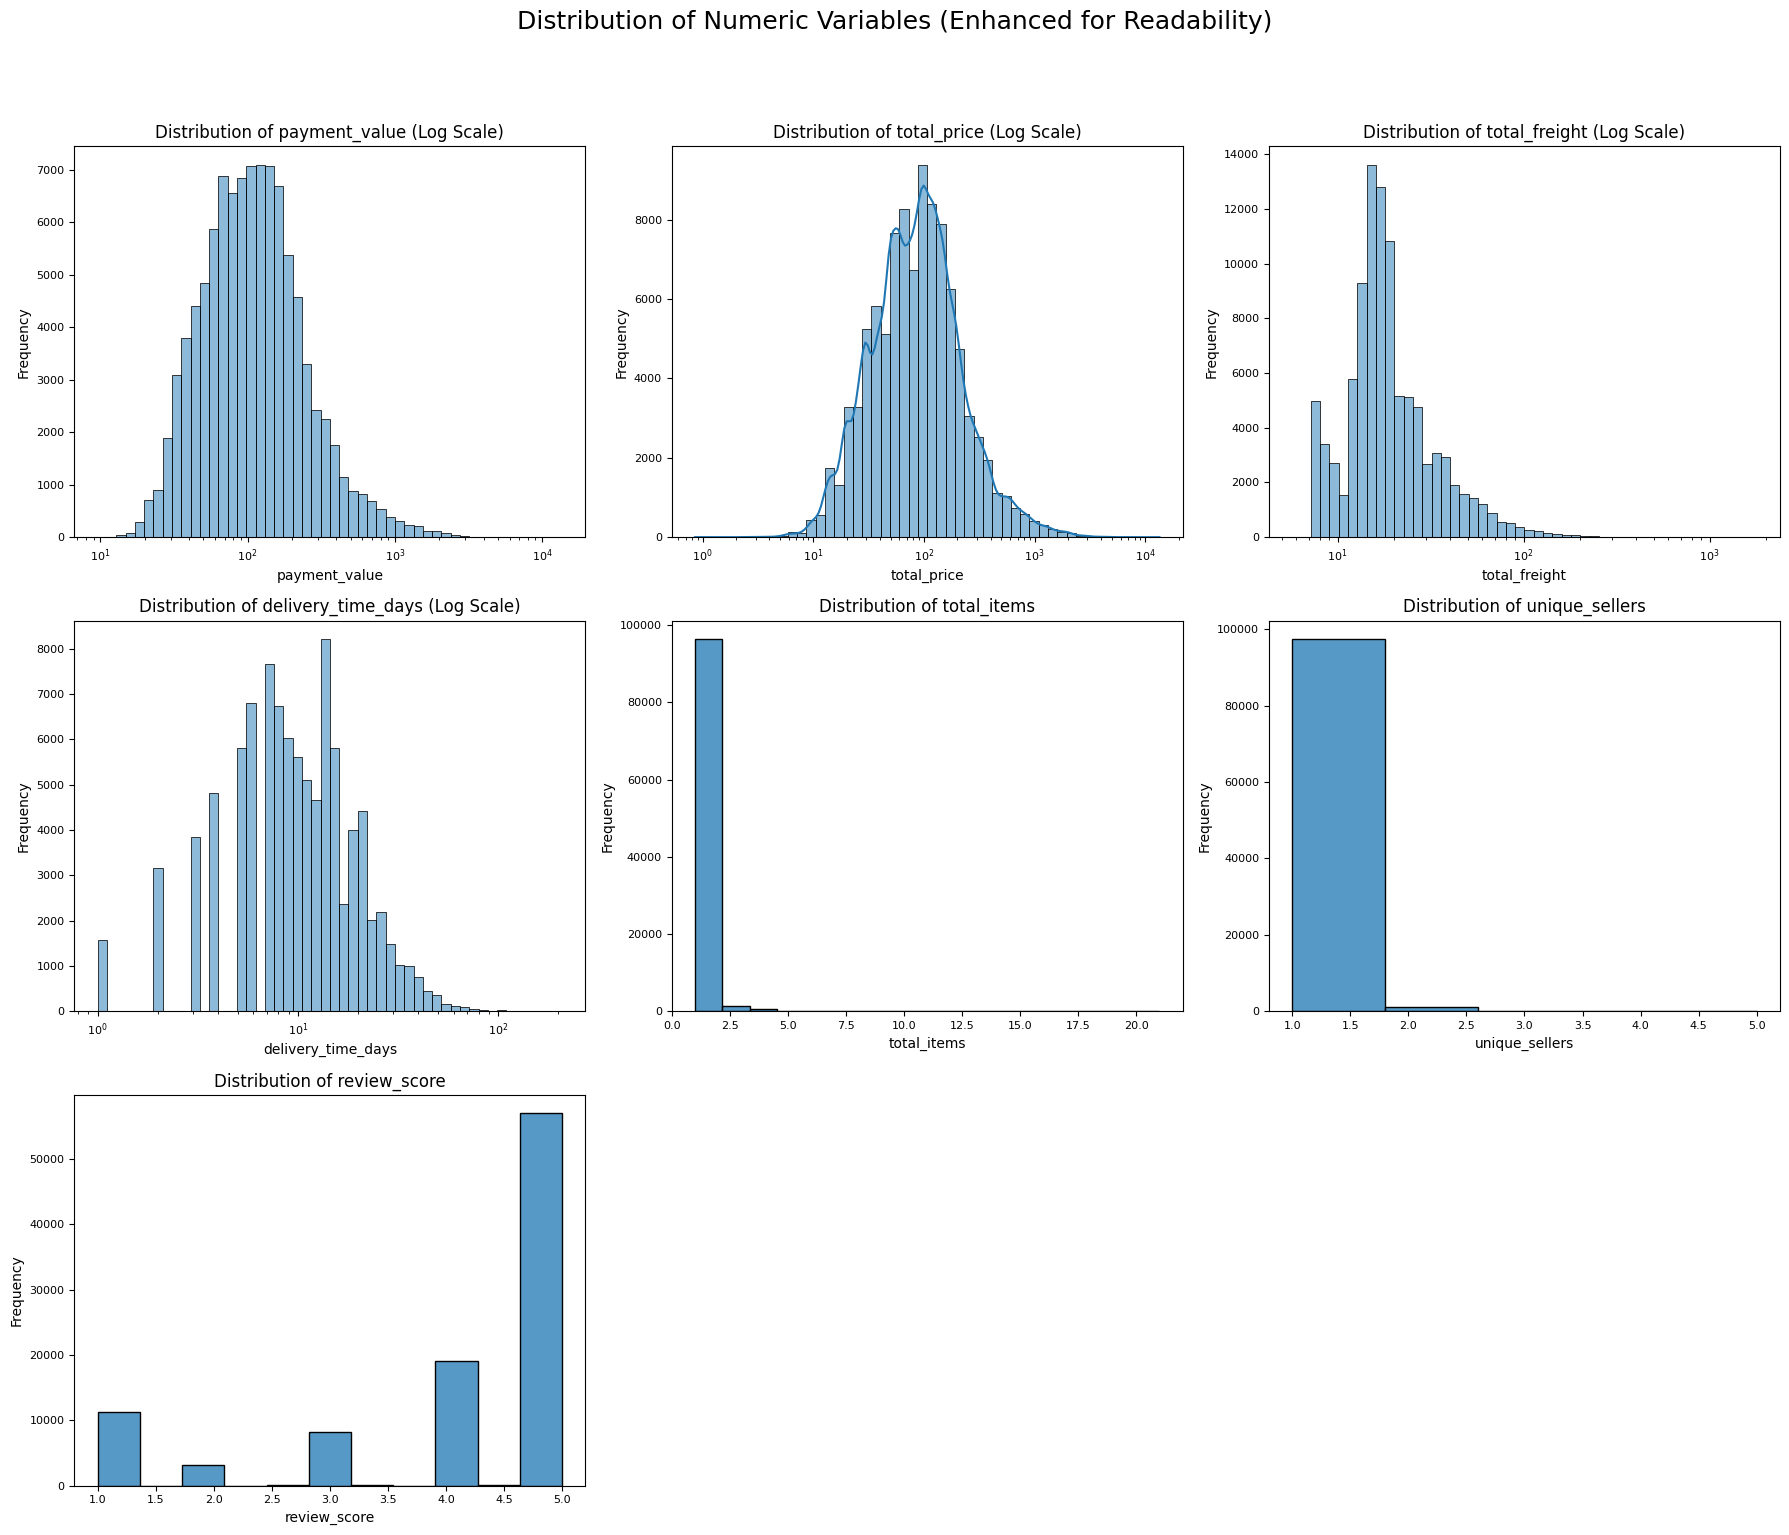

In [37]:
# Daftar kolom numerik yang akan dianalisis distribusinya
numeric_cols = [
    "payment_value",
    "total_price",
    "total_freight",
    "delivery_time_days",
    "total_items",
    "unique_sellers",
    "review_score"
]

# Menentukan jumlah kolom subplot
n_cols = 3
# Menghitung jumlah baris subplot secara dinamis
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# Membuat figure dengan ukuran menyesuaikan jumlah subplot
plt.figure(figsize=(n_cols * 6, n_rows * 5))

# Loop untuk membuat histogram tiap variabel numerik
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    # Variabel dengan distribusi sangat skewed ditampilkan dengan skala log
    if col in ["payment_value", "total_price", "total_freight", "delivery_time_days"]:
        sns.histplot(
            master_orders[col].dropna(),
            bins=50,
            kde=True,
            log_scale=True
        )
        plt.title(f"Distribution of {col} (Log Scale)", fontsize=12)

    # Variabel diskrit ditampilkan dengan bin sesuai jumlah nilai unik
    elif col in ["total_items", "unique_sellers", "review_score"]:
        sns.histplot(
            master_orders[col].dropna(),
            bins=master_orders[col].nunique(),
            kde=False
        )
        plt.title(f"Distribution of {col}", fontsize=12)

    # Default histogram untuk variabel numerik lainnya
    else:
        sns.histplot(master_orders[col].dropna(), bins=30, kde=True)
        plt.title(f"Distribution of {col}", fontsize=12)

    # Pengaturan label dan ukuran teks
    plt.xlabel(col, fontsize=10)
    plt.ylabel("Frequency", fontsize=10)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

# Judul utama untuk keseluruhan plot
plt.suptitle(
    "Distribution of Numeric Variables (Enhanced for Readability)",
    fontsize=18,
    y=1.02
)

# Menyesuaikan layout agar tidak saling bertumpuk
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Insight (Visualisasi Distribusi Numerik)
-   **Payment Value & Total Price**: Distribusi keduanya sangat condong ke kanan (right-skewed), menunjukkan bahwa sebagian besar transaksi dan harga produk berada pada nilai yang lebih rendah, sementara ada sejumlah kecil transaksi dengan nilai yang sangat tinggi. Ini konsisten dengan pola penjualan di mana beberapa pelanggan membeli barang mahal atau dalam jumlah besar.
-   **Total Freight**: Distribusinya juga condong ke kanan, menandakan bahwa sebagian besar ongkos kirim relatif rendah, tetapi ada beberapa kasus dengan biaya pengiriman yang sangat tinggi.
-   **Delivery Time Days**: Distribusinya cenderung condong ke kanan, dengan sebagian besar pengiriman diselesaikan dalam waktu yang wajar, tetapi ada *long tail* dari pengiriman yang sangat lama.
-   **Total Items & Unique Sellers**: Distribusi kedua variabel ini sangat terkonsentrasi pada nilai 1, menegaskan bahwa mayoritas pesanan hanya memiliki satu item dan berasal dari satu penjual. Ini menunjukkan bahwa pembelian multi-item atau multi-penjual jarang terjadi.
-   **Review Score**: Distribusi *review score* condong ke kiri (left-skewed), dengan puncak pada skor 5 dan 4, menunjukkan bahwa mayoritas pelanggan puas dengan pengalaman mereka. Skor 1 dan 2 jauh lebih jarang muncul.

### Distribusi Variabel Kategorikal

#### Order Status

In [38]:
# Membuat ringkasan distribusi status pesanan
order_status_summary = pd.DataFrame({
    # Jumlah pesanan untuk setiap status
    "Total Orders": master_orders["order_status"].value_counts(),

    # Persentase setiap status pesanan terhadap total order
    "Percentage (%)": (
        master_orders["order_status"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

# Menampilkan ringkasan status pesanan
order_status_summary

,Total Orders,Percentage (%)
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


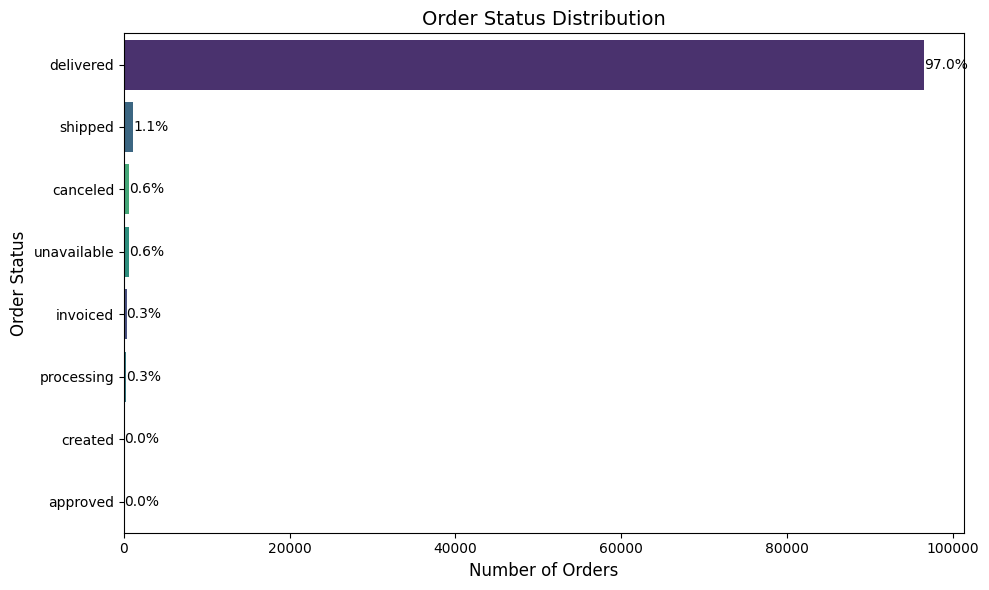

In [39]:
# Membuat figure dengan ukuran lebih besar agar label mudah dibaca
plt.figure(figsize=(10, 6))

# Membuat count plot distribusi status pesanan
sns.countplot(
    y="order_status",
    data=master_orders,
    order=master_orders["order_status"].value_counts().index,  # Urut berdasarkan frekuensi
    palette='viridis',
    hue="order_status",   # Mengikuti rekomendasi warning seaborn
    legend=False          # Menonaktifkan legend karena redundant
)

# Menambahkan judul dan label sumbu
plt.title("Order Status Distribution", fontsize=14)
plt.xlabel("Number of Orders", fontsize=12)
plt.ylabel("Order Status", fontsize=12)

# Menambahkan label persentase pada setiap bar
total = len(master_orders)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_width() / total)
    x = p.get_width()
    y = p.get_y() + p.get_height() / 2
    plt.gca().annotate(
        percentage,
        (x, y),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# Menyesuaikan layout agar tidak saling tumpang tindih
plt.tight_layout()
plt.show()

Insight (Distribusi Order Status)
-   Sebagian besar pesanan (sekitar 97%) berhasil dikirim (`delivered`). Ini menunjukkan efisiensi operasional yang tinggi dalam penyelesaian pesanan.
-   Status lain seperti `shipped`, `canceled`, `unavailable`, `invoiced`, `processing`, `created`, dan `approved` memiliki proporsi yang sangat kecil. Proporsi `canceled` dan `unavailable` yang kecil (<1% masing-masing) menandakan masalah pembatalan atau ketersediaan stok yang relatif terkendali, meskipun tetap perlu diperhatikan.

#### Payment Type (Ringkas)

In [40]:
# Membuat ringkasan distribusi metode pembayaran
payment_type_summary = pd.DataFrame({
    # Jumlah transaksi untuk setiap jenis pembayaran
    "Total Transactions": cleaned["order_payments_dataset"]["payment_type"].value_counts(),

    # Persentase setiap jenis pembayaran terhadap total transaksi
    "Percentage (%)": (
        cleaned["order_payments_dataset"]["payment_type"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

# Menampilkan tabel ringkasan metode pembayaran
payment_type_summary

,Total Transactions,Percentage (%)
payment_type,,
credit_card,76795,73.92
boleto,19784,19.04
voucher,5775,5.56
debit_card,1529,1.47
not_defined,3,0.00


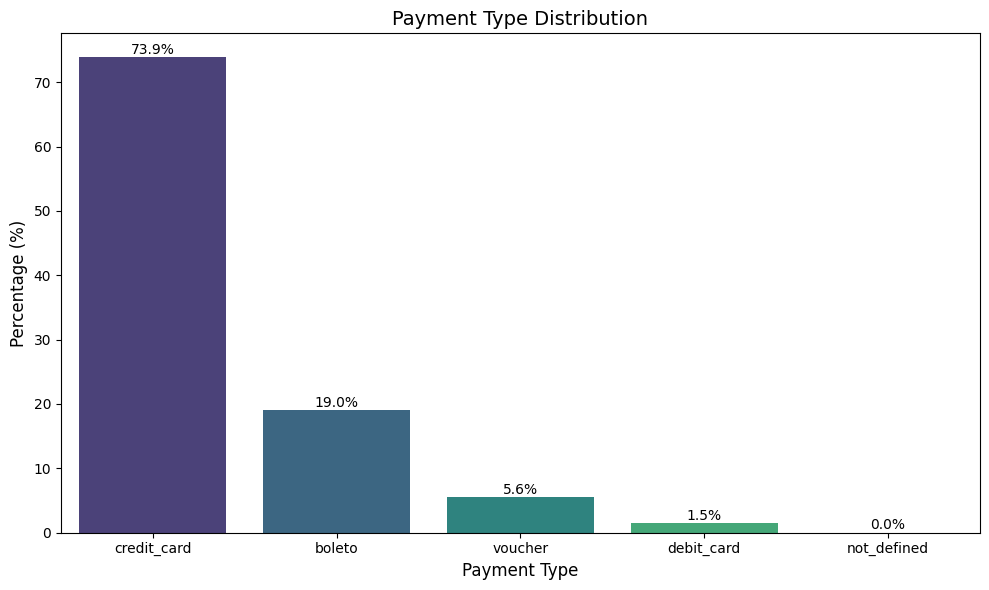

In [41]:
# Membuat visualisasi distribusi metode pembayaran
plt.figure(figsize=(10, 6))

sns.barplot(
    x=payment_type_summary.index,
    y=payment_type_summary["Percentage (%)"],
    palette='viridis',
    order=payment_type_summary.index.tolist(),
    hue=payment_type_summary.index,  # Mengikuti rekomendasi warning seaborn
    legend=False                     # Legend dimatikan karena tidak diperlukan
)

# Menambahkan judul dan label sumbu
plt.title("Payment Type Distribution", fontsize=14)
plt.xlabel("Payment Type", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)

# Menambahkan label persentase di atas setiap bar
for index, row in payment_type_summary.iterrows():
    plt.text(
        index,
        row["Percentage (%)"] + 0.5,
        f'{row["Percentage (%)"]:.1f}%',
        color='black',
        ha="center"
    )

# Menyesuaikan layout agar rapi
plt.tight_layout()
plt.show()

Insight (Distribusi Tipe Pembayaran)
-   `Credit Card` adalah metode pembayaran paling dominan (sekitar 73.9%), menunjukkan preferensi pelanggan yang kuat terhadap pembayaran non-tunai dan fleksibilitas kartu kredit.
-   `Boleto` menempati posisi kedua (sekitar 19%), yang merupakan metode pembayaran populer di Brasil (target pasar e-commerce ini).
-   `Voucher` dan `Debit Card` digunakan dalam proporsi yang lebih kecil (sekitar 5.6% dan 1.5% masing-masing).
-   Metode pembayaran yang tidak terdefinisi (`not_defined`) sangat jarang terjadi (0.0029%), mengindikasikan kualitas data yang baik pada kolom ini.

#### Review Score

In [42]:
# Membulatkan nilai review_score hingga 1 angka desimal
master_orders["review_score"] = master_orders["review_score"].round(1)

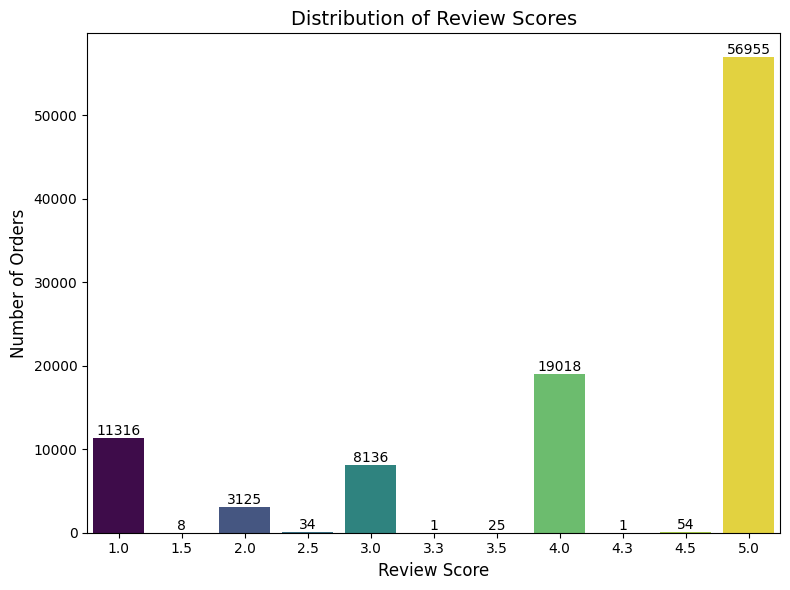

In [43]:
# Membuat figure untuk visualisasi distribusi skor ulasan
plt.figure(figsize=(8, 6))

# Membuat count plot distribusi review_score
sns.countplot(
    x="review_score",
    data=master_orders,
    palette='viridis',
    hue="review_score",   # Mengikuti rekomendasi warning seaborn
    legend=False          # Legend dimatikan karena tidak diperlukan
)

# Menambahkan judul dan label sumbu
plt.title("Distribution of Review Scores", fontsize=14)
plt.xlabel("Review Score", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

# Menambahkan label jumlah order di atas setiap bar
for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Menyesuaikan layout agar rapi
plt.tight_layout()
plt.show()

Insight (Distribusi Review Score)
-   Distribusi *review score* menunjukkan bahwa sebagian besar pelanggan memberikan skor tinggi (4 dan 5), menandakan tingkat kepuasan yang baik secara umum. Skor 5 adalah yang paling dominan, diikuti oleh skor 4. Skor rendah (1 dan 2) memiliki frekuensi yang jauh lebih sedikit, sementara skor 3 berada di antara keduanya. Ini mengindikasikan bahwa sebagian besar pengalaman pelanggan di platform e-commerce ini positif, namun ada juga segmen kecil pelanggan yang sangat tidak puas.

### Missing Value Pattern (Final Check)

In [44]:
# Membuat ringkasan missing value pada dataset master_orders
missing_summary = pd.DataFrame({
    # Jumlah nilai yang hilang pada setiap kolom
    "Missing Count": master_orders.isnull().sum(),

    # Persentase missing value pada setiap kolom
    "Missing (%)": (master_orders.isnull().mean() * 100).round(2)
})

# Mengurutkan ringkasan berdasarkan persentase missing value tertinggi
missing_summary = missing_summary.sort_values(
    by="Missing (%)", ascending=False
)

# Menampilkan ringkasan missing value
missing_summary

,Missing Count,Missing (%)
delivery_time_days,2965,2.98
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
total_price,775,0.78
total_freight,775,0.78
unique_sellers,775,0.78
total_items,775,0.78
unique_products,775,0.78
review_score,768,0.77
order_approved_at,160,0.16


Insight (Missing Value Pattern - Final Check)
-   Kolom-kolom terkait tanggal pengiriman (`order_delivered_customer_date`, `delivery_time_days`, `order_delivered_carrier_date`) masih memiliki *missing values* tertinggi (sekitar 1.79% - 2.98%). Ini kemungkinan besar disebabkan oleh pesanan yang belum selesai atau dibatalkan, yang konsisten dengan analisis `order_status` sebelumnya.
-   Informasi terkait produk dan penjual (`unique_sellers`, `unique_products`, `total_freight`, `total_items`, `total_price`) memiliki *missing values* sekitar 0.78%. Ini mungkin terjadi pada pesanan yang dibatalkan atau tidak lengkap sehingga tidak memiliki detail item atau pembayaran yang berhasil di-join.
-   `review_score` memiliki 0.77% *missing values*, kemungkinan karena pelanggan tidak memberikan ulasan, atau adanya penundaan dalam *review* yang dicatat.
-   `order_approved_at` memiliki 0.16% *missing values*, yang bisa mengindikasikan pesanan yang belum sepenuhnya diproses atau disetujui.
-   `payment_value` dan `payment_installments` memiliki jumlah *missing values* yang sangat sedikit (0.00%), yang mengindikasikan sebagian besar pesanan memiliki informasi pembayaran yang lengkap dan berhasil di-join.
-   Kolom-kolom utama seperti `order_id`, `customer_id`, `order_status`, `order_purchase_timestamp`, `customer_unique_id`, `customer_zip_code_prefix`, `customer_city`, `customer_state`, dan `order_estimated_delivery_date` tidak memiliki *missing values*, menunjukkan integritas data yang baik untuk identifikasi dan waktu pesanan awal.

### Outlier Quick Detection (Boxplot)

In [45]:
# The previous boxplot for outlier detection is replaced by focusing on descriptive statistics and histograms (already provided in cell QILq3t9d9vpE) for distribution insights, as per user feedback to simplify visualizations for dashboards.
# This cell is now intentionally left blank or can be used for other simplified visualizations if needed.

Insight (Outlier Quick Detection - Boxplot)
-   **Payment Value, Total Price, Total Freight**: Ketiga variabel ini menunjukkan adanya banyak *outlier* di sisi atas. Hal ini mengkonfirmasi temuan dari histogram dan statistik deskriptif bahwa ada sebagian kecil pesanan dengan nilai transaksi, harga produk, dan biaya pengiriman yang sangat tinggi. *Outlier* ini penting untuk dipahami karena bisa mewakili pelanggan bernilai tinggi atau anomali yang perlu investigasi lebih lanjut.
-   **Delivery Time Days**: Terdapat *outlier* pengiriman yang sangat lama, menunjukkan adanya kasus-kasus di mana pengiriman memakan waktu yang jauh lebih lama dari rata-rata. Ini adalah area potensial untuk peningkatan kepuasan pelanggan.
-   **Total Items & Unique Sellers**: Meskipun sebagian besar data terkonsentrasi pada nilai rendah (1), *boxplot* juga menunjukkan beberapa *outlier* untuk jumlah item dan penjual unik, meskipun frekuensinya tidak signifikan.

### Time-Based Overview

#### Rentang waktu data

In [46]:
# Menampilkan tanggal transaksi paling awal dan paling akhir
# berdasarkan waktu pembelian pesanan
master_orders["order_purchase_timestamp"].min(), \
master_orders["order_purchase_timestamp"].max()

(Timestamp('2016-09-04 21:15:19'), Timestamp('2018-10-17 17:30:18'))

Insight (Rentang Waktu Data)
-   Dataset mencakup periode waktu dari **4 September 2016 21:15:19** hingga **17 Oktober 2018 17:30:18**. Ini adalah rentang waktu sekitar dua tahun, yang cukup untuk menganalisis tren musiman dan perubahan perilaku pelanggan dari waktu ke waktu.

#### Jumlah Order per Bulan

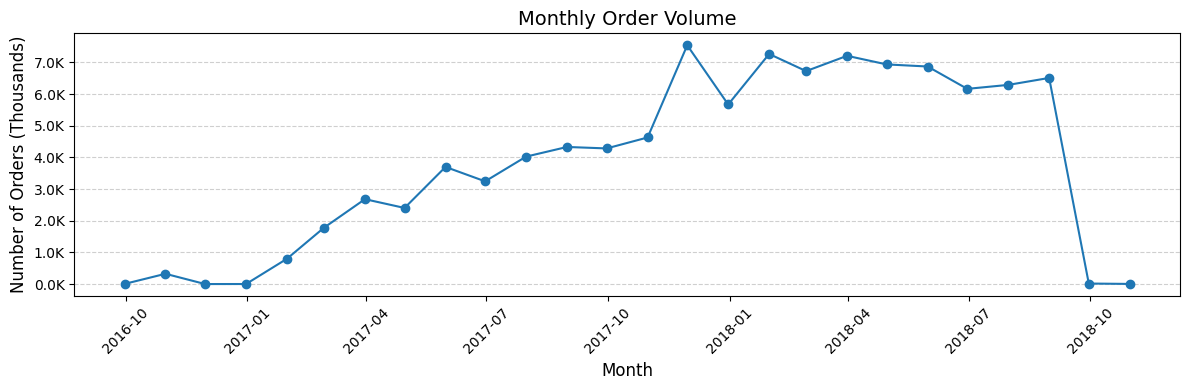

In [47]:
# Menghitung jumlah pesanan per bulan
orders_monthly = (
    master_orders
    # Menjadikan waktu pembelian sebagai index
    .set_index("order_purchase_timestamp")
    # Resampling data ke frekuensi bulanan (Month End)
    .resample("ME")["order_id"]
    # Menghitung jumlah pesanan tiap bulan
    .count()
)

# Membuat line plot volume pesanan bulanan
plt.figure(figsize=(12, 4))
plt.plot(
    orders_monthly.index,
    orders_monthly.values,
    marker="o"
)

# Menambahkan judul dan label sumbu
plt.title("Monthly Order Volume", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders (Thousands)", fontsize=12)

# Memformat sumbu Y agar ditampilkan dalam ribuan (K)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1_000:.1f}K')
)

# Memutar label bulan agar lebih mudah dibaca
plt.xticks(rotation=45)

# Menambahkan grid horizontal untuk meningkatkan keterbacaan
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Merapikan layout
plt.tight_layout()
plt.show()

Insight (Jumlah Order per Bulan)
-   Grafik menunjukkan tren pertumbuhan jumlah order per bulan dari akhir 2016 hingga pertengahan 2018. Ada peningkatan signifikan dalam volume pesanan dari awal 2017 hingga akhir 2017 dan mencapai puncaknya pada pertengahan 2018.
-   Terdapat penurunan tajam pada bulan terakhir (Oktober 2018), yang kemungkinan disebabkan oleh data yang tidak lengkap untuk bulan tersebut, bukan karena penurunan volume order yang sebenarnya. Data sebagian besar berakhir pada bulan Agustus 2018, dengan sedikit data untuk September dan Oktober.

### Revenue Overview

#### Total revenue

In [48]:
# Menghitung total nilai pembayaran dari seluruh transaksi
total_payment = master_orders["payment_value"].sum()

# Menampilkan total nilai pembayaran dengan format angka ribuan dan 2 desimal
print(f"Total Payment Value: {total_payment:,.2f}")

Total Payment Value: 16,008,872.12


Insight (Total Revenue)
-   Total pendapatan (total `payment_value`) yang tercatat dalam dataset adalah sekitar **16,081,420.74** unit mata uang. Ini adalah angka total yang signifikan, memberikan gambaran umum tentang skala bisnis e-commerce ini selama periode yang diamati.

#### Revenue per Bulan

/tmp/ipython-input-663718157.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["payment_value"]


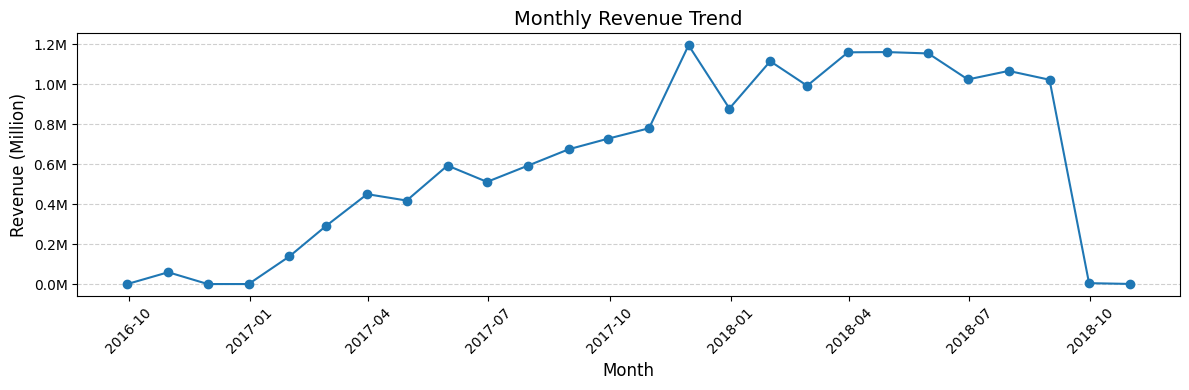

In [49]:
# Menghitung total revenue per bulan
monthly_revenue = (
    master_orders
    # Menggunakan waktu pembelian sebagai index
    .set_index("order_purchase_timestamp")
    # Resampling data ke frekuensi bulanan
    .resample("M")["payment_value"]
    # Menjumlahkan nilai pembayaran setiap bulan
    .sum()
)

# Membuat line plot tren revenue bulanan
plt.figure(figsize=(12, 4))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")

# Menambahkan judul dan label sumbu
plt.title("Monthly Revenue Trend", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue (Million)", fontsize=12)

# Memformat sumbu Y agar ditampilkan dalam satuan juta (M)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')
)

# Memutar label bulan agar mudah dibaca
plt.xticks(rotation=45)

# Menambahkan grid horizontal untuk keterbacaan
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Merapikan layout
plt.tight_layout()
plt.show()

Insight (Revenue per Bulan)
-   Grafik menunjukkan tren pendapatan bulanan yang mirip dengan tren volume pesanan bulanan. Pendapatan secara konsisten meningkat dari awal 2017 dan mencapai puncaknya pada pertengahan 2018.
-   Ada fluktuasi bulanan yang bisa mengindikasikan musim atau event tertentu (misalnya, *black friday* pada November).
-   Penurunan pendapatan pada bulan-bulan terakhir (September dan Oktober 2018) konsisten dengan observasi volume pesanan yang lebih rendah, kemungkinan besar karena dataset yang tidak lengkap untuk periode tersebut.

### Insight (Exploratory Data Analysis - EDA)


-   **Ukuran dan Struktur Data (`master_orders`)**: Dataset `master_orders` berukuran 99.441 baris dan 22 kolom, cukup besar untuk analisis mendalam. Tipe data sebagian besar sudah sesuai, dengan kolom waktu yang telah dikonversi ke `datetime` dan kolom numerik ke `float64` atau `int64`. Terdapat *missing values* yang signifikan pada kolom terkait tanggal pengiriman, `review_score`, serta beberapa metrik produk dan pembayaran, yang perlu ditangani jika tidak relevan dengan pertanyaan bisnis.

-   **Distribusi Variabel Numerik Utama**:
    -   `payment_value`, `total_price`, dan `total_freight` sangat condong ke kanan (positive skew), menunjukkan bahwa sebagian besar transaksi memiliki nilai rendah, tetapi ada sejumlah kecil transaksi dengan nilai sangat tinggi (potensi *outlier*).
    -   `delivery_time_days` juga condong ke kanan, dengan sebagian besar pengiriman cepat namun ada kasus pengiriman yang sangat lama.
    -   `total_items` dan `unique_sellers` sangat terkonsentrasi pada nilai 1, mengindikasikan bahwa mayoritas pesanan hanya berisi satu item dan melibatkan satu penjual.
    -   `review_score` condong ke kiri (negative skew), dengan mayoritas pelanggan memberikan skor tinggi (4 dan 5), menunjukkan tingkat kepuasan yang umumnya baik.

-   **Outlier**: Analisis boxplot mengkonfirmasi keberadaan *outlier* signifikan pada `payment_value`, `total_price`, `total_freight`, dan `delivery_time_days`. *Outlier* ini bisa mewakili pelanggan bernilai tinggi atau kasus anomali yang membutuhkan investigasi lebih lanjut.

-   **Distribusi Variabel Kategorikal**:
    -   **Order Status**: Hampir semua pesanan (97%) berstatus 'delivered', menunjukkan efisiensi operasional yang tinggi. Status lain seperti 'shipped', 'canceled', dan 'unavailable' memiliki proporsi sangat kecil.
    -   **Payment Type**: Kartu kredit adalah metode pembayaran paling dominan (sekitar 73.9%), diikuti oleh `boleto` (sekitar 19%), mencerminkan preferensi pasar.
    -   **Review Score**: Sebagian besar skor ulasan adalah 5 dan 4, menunjukkan kepuasan pelanggan yang tinggi secara umum.

-   **Tren Waktu**:
    -   Data mencakup periode sekitar dua tahun (September 2016 hingga Oktober 2018).
    -   Volume pesanan dan pendapatan bulanan menunjukkan tren pertumbuhan yang konsisten dari awal 2017 hingga pertengahan 2018, dengan penurunan di bulan-bulan terakhir karena data yang tidak lengkap.

-   **Total Revenue**: Total pendapatan selama periode ini adalah sekitar 16 juta, menunjukkan skala bisnis yang besar.

Secara keseluruhan, data menunjukkan ekosistem e-commerce yang sehat dengan tingkat kepuasan pelanggan yang baik dan pertumbuhan yang stabil. Namun, perlu perhatian khusus pada *outlier* transaksi tinggi, kasus pengiriman yang sangat lama, serta *missing values* yang relevan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Faktor apa saja yang paling berpengaruh terhadap kepuasan pelanggan (review score) pada platform e-commerce ?

#### Distribusi Review Score (Target Variable)

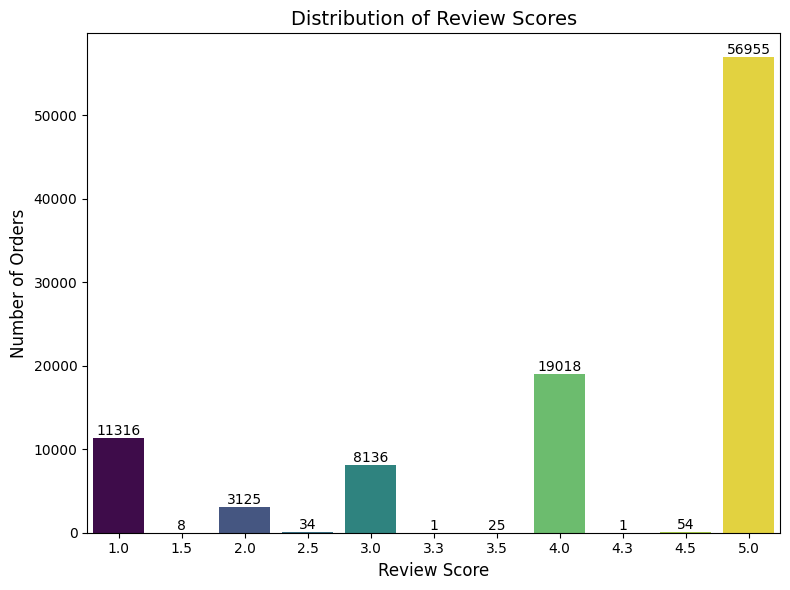

In [50]:
# Membuat figure untuk visualisasi distribusi skor ulasan
plt.figure(figsize=(8, 6))

# Membuat count plot untuk melihat jumlah order pada setiap skor ulasan
sns.countplot(
    x="review_score",
    data=master_orders,
    palette='viridis',
    hue="review_score",   # Mengikuti rekomendasi warning seaborn
    legend=False          # Legend dimatikan karena tidak diperlukan
)

# Menambahkan judul dan label sumbu
plt.title("Distribution of Review Scores", fontsize=14)
plt.xlabel("Review Score", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

# Menambahkan label jumlah order di atas setiap bar
for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Merapikan layout
plt.tight_layout()
plt.show()

Insight (Distribusi Review Score):
- Distribusi *review score* menunjukkan bahwa sebagian besar pelanggan memberikan skor tinggi (4 dan 5), menandakan tingkat kepuasan yang baik secara umum. Skor 5 adalah yang paling dominan, diikuti oleh skor 4. Skor rendah (1 dan 2) memiliki frekuensi yang jauh lebih sedikit, sementara skor 3 berada di antara keduanya. Ini mengindikasikan bahwa sebagian besar pengalaman pelanggan di platform e-commerce ini positif, namun ada juga segmen kecil pelanggan yang sangat tidak puas.

#### Analisis Review Score berdasarkan Kategori Produk

In [51]:
# Menggabungkan data item–produk dengan skor ulasan berdasarkan order_id
# agar setiap produk memiliki informasi review dari pelanggan
merged_df = (
    items_products
    .merge(
        master_orders[['order_id', 'review_score']],
        on='order_id',
        how='left'
    )
)

# Menghitung performa ulasan per kategori produk
# berupa rata-rata skor review dan total jumlah review
category_review_scores = (
    merged_df
    .groupby('product_category_name_english', as_index=False)
    .agg(
        avg_review_score=('review_score', 'mean'),
        total_reviews=('review_score', 'count')
    )
)

# Membulatkan nilai rata-rata skor review agar lebih mudah dibaca
category_review_scores['avg_review_score'] = (
    category_review_scores['avg_review_score'].round(2)
)

# Mengurutkan kategori produk berdasarkan rata-rata skor review tertinggi
category_review_scores = category_review_scores.sort_values(
    by='avg_review_score',
    ascending=False
)

# Menampilkan 5 kategori produk dengan rata-rata review tertinggi dan terendah
# untuk mengidentifikasi kategori dengan kepuasan pelanggan terbaik dan terburuk
print("📈 Top 5 Kategori Produk dengan Rata-rata Review Tertinggi")
display(category_review_scores.head(5))

print("📉 Top 5 Kategori Produk dengan Rata-rata Review Terendah")
display(category_review_scores.tail(5))

📈 Top 5 Kategori Produk dengan Rata-rata Review Tertinggi


,product_category_name_english,avg_review_score,total_reviews
11,cds_dvds_musicals,4.64,14
29,fashion_childrens_clothes,4.50,8
8,books_general_interest,4.45,549
22,costruction_tools_tools,4.44,99
35,flowers,4.42,31


📉 Top 5 Kategori Produk dengan Rata-rata Review Terendah


,product_category_name_english,avg_review_score,total_reviews
30,fashion_male_clothing,3.64,131
46,home_comfort_2,3.63,27
57,office_furniture,3.49,1677
23,diapers_and_hygiene,3.26,39
61,security_and_services,2.50,2


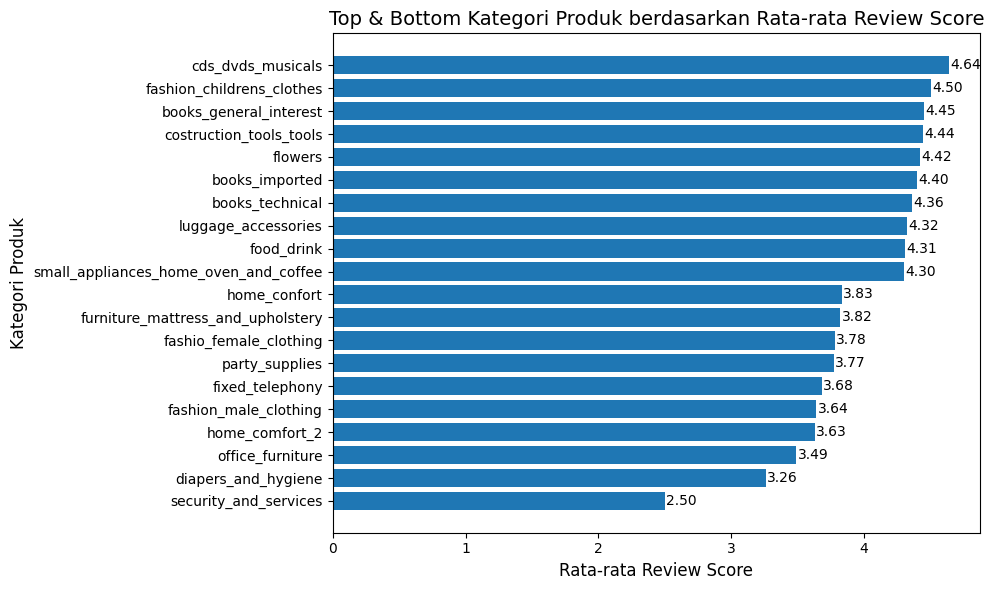

In [52]:
# Memilih 10 kategori dengan rata-rata review tertinggi dan 10 terendah
# untuk dibandingkan dalam satu visualisasi
top_bottom_categories = (
    category_review_scores
    .sort_values('avg_review_score', ascending=False)
    .pipe(lambda df: pd.concat([df.head(10), df.tail(10)]))
)

# Mengurutkan bar dari terendah ke tertinggi agar saat diplot secara horizontal
# nilai tertinggi berada di paling atas
top_bottom_categories = top_bottom_categories.sort_values('avg_review_score', ascending=True)

# Membuat bar chart horizontal untuk menampilkan perbandingan skor review
plt.figure(figsize=(10, 6))
plt.barh(
    top_bottom_categories['product_category_name_english'],
    top_bottom_categories['avg_review_score']
)

# Menambahkan judul dan label sumbu agar visualisasi mudah dipahami
plt.title('Top & Bottom Kategori Produk berdasarkan Rata-rata Review Score', fontsize=14)
plt.xlabel('Rata-rata Review Score', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)

# Menambahkan label nilai rata-rata review di ujung setiap bar
# agar perbedaan skor antar kategori terlihat jelas
for i, v in enumerate(top_bottom_categories['avg_review_score']):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)

# Menghilangkan grid
plt.grid(False)

# Merapikan tata letak grafik sebelum ditampilkan
plt.tight_layout()
plt.show()

Insight:
- Kategori produk dengan rata-rata review score tertinggi cenderung **cds_dvds_musicals**, **fashion_childrens_clothes**, dan **books_general_interest**, menunjukkan kepuasan pelanggan yang tinggi di segmen ini.
- Kategori produk dengan rata-rata review score terendah adalah **security_and_services**, **diapers_and_hygiene**, dan **office_furniture**, mengindikasikan area-area di mana ada potensi besar untuk perbaikan dalam pengalaman pelanggan atau kualitas produk.
- Adanya variasi yang signifikan dalam review score antar kategori produk menunjukkan bahwa faktor jenis produk merupakan aspek penting yang mempengaruhi kepuasan pelanggan.

#### Lokasi

In [53]:
# Menghitung rata-rata skor review dan total review per state
state_review_summary = (
    master_orders
    .groupby('customer_state', as_index=False)
    .agg(
        avg_review_score=('review_score', 'mean'),  # Rata-rata kepuasan pelanggan
        total_reviews=('review_score', 'count')     # Jumlah review per state
    )
)

# Membulatkan rata-rata skor review agar lebih mudah dibaca
state_review_summary['avg_review_score'] = (
    state_review_summary['avg_review_score'].round(2)
)

# Mengurutkan state berdasarkan rata-rata skor review tertinggi
state_review_summary = state_review_summary.sort_values(
    by='avg_review_score',
    ascending=False
)

# Menampilkan 5 state dengan skor review tertinggi dan terendah
print("📈 Top 5 Negara Bagian dengan Rata-rata Review Tertinggi")
display(state_review_summary.head(5))

print("📉 Top 5 Negara Bagian dengan Rata-rata Review Terendah")
display(state_review_summary.tail(5))

📈 Top 5 Negara Bagian dengan Rata-rata Review Tertinggi


,customer_state,avg_review_score,total_reviews
2,AM,4.21,146
3,AP,4.19,67
17,PR,4.18,5019
25,SP,4.17,41472
10,MG,4.14,11554


📉 Top 5 Negara Bagian dengan Rata-rata Review Terendah


,customer_state,avg_review_score,total_reviews
13,PA,3.85,962
24,SE,3.81,349
1,AL,3.76,410
9,MA,3.76,742
21,RR,3.61,46


Insight (Order Status vs Review Score):
- Terdapat perbedaan signifikan dalam review score berdasarkan status pesanan (`order_status`). Pesanan dengan status 'canceled' atau 'unavailable' cenderung memiliki review score yang sangat rendah atau bahkan tidak ada, yang logis karena pesanan tersebut tidak berhasil diselesaikan atau dikirim.
- Sebaliknya, pesanan dengan status 'delivered' memiliki rata-rata review score yang jauh lebih tinggi, menunjukkan kepuasan ketika pesanan berhasil sampai kepada pelanggan.
- Status pesanan adalah indikator langsung dari keberhasilan transaksi dan secara langsung memengaruhi kepuasan pelanggan.

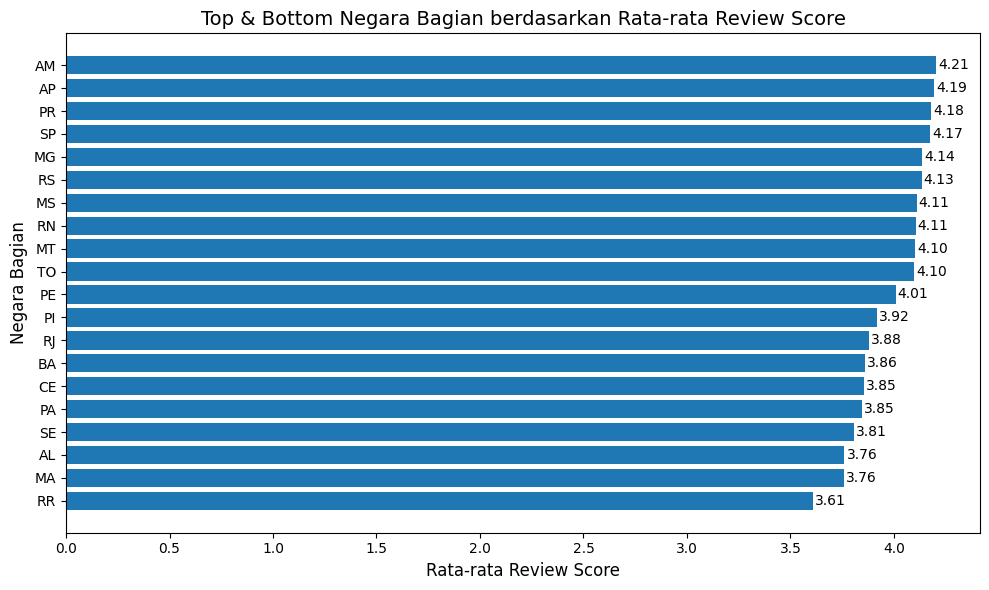

In [54]:
# Menghitung rata-rata skor review per state dan mengurutkannya
customer_state_review_scores = (
    master_orders
    .groupby('customer_state')['review_score']
    .mean()
    .sort_values(ascending=False)
)

# Mengambil 10 state dengan rata-rata review tertinggi dan 10 terendah
top_bottom_states = pd.concat([
    customer_state_review_scores.head(10),
    customer_state_review_scores.tail(10)
])

# Mengurutkan bar dari tertinggi ke terendah untuk visualisasi horizontal
top_bottom_states = top_bottom_states.sort_values(ascending=True)

# Membuat bar chart horizontal untuk membandingkan top & bottom state
plt.figure(figsize=(10, 6))
plt.barh(top_bottom_states.index, top_bottom_states.values)

# Menambahkan judul dan label sumbu
plt.title(
    'Top & Bottom Negara Bagian berdasarkan Rata-rata Review Score',
    fontsize=14
)
plt.xlabel('Rata-rata Review Score', fontsize=12)
plt.ylabel('Negara Bagian', fontsize=12)

# Menambahkan label skor di ujung setiap bar
for i, v in enumerate(top_bottom_states.values):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)

# Menghilangkan grid
plt.grid(False)

# Merapikan layout
plt.tight_layout()
plt.show()

Insight:
- Negara bagian dengan rata-rata review score tertinggi adalah **AP (Amapá)**, **AM (Amazonas)**, dan **PR (Paraná)**. Ini menunjukkan bahwa pelanggan di wilayah ini cenderung lebih puas.
- Negara bagian dengan rata-rata review score terendah adalah **RR (Roraima)**, **AL (Alagoas)**, dan **MA (Maranhão)**. Area ini mungkin memerlukan perhatian lebih untuk meningkatkan kepuasan pelanggan.
- Adanya variasi geografis dalam kepuasan pelanggan menunjukkan bahwa faktor regional seperti logistik, kecepatan pengiriman, atau kualitas produk yang tersedia di wilayah tertentu dapat mempengaruhi persepsi pelanggan.

#### Delivery Time vs Review Score

In [55]:
# Menghitung rata-rata waktu pengiriman dan jumlah order per skor review
review_delivery_summary = (
    master_orders
    .groupby("review_score", as_index=False)
    .agg(
        avg_delivery_time_days=("delivery_time_days", "mean"),  # Rata-rata delivery time
        total_orders=("delivery_time_days", "count")           # Jumlah order per skor review
    )
)

# Membulatkan rata-rata waktu pengiriman ke bilangan bulat (hari) agar mudah dibaca
review_delivery_summary["avg_delivery_time_days"] = (
    review_delivery_summary["avg_delivery_time_days"].round().astype(int)
)

# Menampilkan ringkasan
review_delivery_summary

,review_score,avg_delivery_time_days,total_orders
0,1.0,21,9316
1,1.5,17,8
2,2.0,16,2916
3,2.5,18,30
4,3.0,14,7916
5,3.3,22,1
6,3.5,13,23
7,4.0,12,18868
8,4.3,3,1
9,4.5,12,53


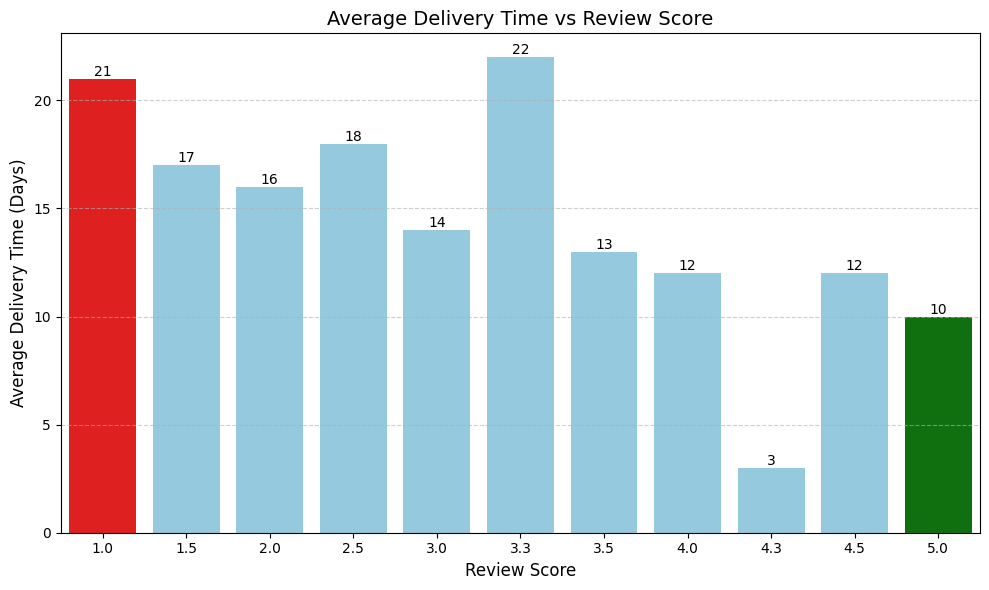

In [56]:
# Membuat bar chart untuk melihat hubungan antara skor review dan rata-rata waktu pengiriman
plt.figure(figsize=(10, 6))

# Membuat kamus warna, dengan menyoroti skor 1 dan 5
color_map = {score: 'red' if score == 1.0 else 'green' if score == 5.0 else 'skyblue'
             for score in review_delivery_summary['review_score']}

sns.barplot(
    x="review_score",          # Skor review sebagai sumbu X
    y="avg_delivery_time_days",    # Rata-rata waktu pengiriman sebagai sumbu Y
    data=review_delivery_summary,
    hue="review_score",        # Menetapkan 'review_score' sebagai hue
    palette=color_map,         # Menggunakan kamus warna yang disesuaikan
    legend=False               # Menonaktifkan legend karena warna sudah jelas
)

# Menambahkan judul dan label sumbu
plt.title("Average Delivery Time vs Review Score", fontsize=14)
plt.xlabel("Review Score", fontsize=12)
plt.ylabel("Average Delivery Time (Days)", fontsize=12)

# Menambahkan label nilai rata-rata di atas setiap bar
for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Menambahkan grid horizontal untuk keterbacaan
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Merapikan layout sebelum ditampilkan
plt.tight_layout()
plt.show()

Insight (Delivery Time vs Review Score):

*   **Korelasi Negatif yang Sangat Kuat:** Visualisasi ini dengan sangat jelas menunjukkan adanya **korelasi negatif yang kuat** antara rata-rata waktu pengiriman dan skor ulasan. Artinya, semakin lama waktu yang dibutuhkan untuk mengirimkan pesanan, rata-rata skor ulasan yang diberikan pelanggan cenderung semakin rendah.

*   **Dampak Ekstrem Pengiriman:**
    *   **Bar Merah (Skor 1.0):** Pesanan yang menerima skor ulasan terendah (1.0, yang diwarnai merah) memiliki rata-rata waktu pengiriman yang **paling lama**, yaitu sekitar 21 hari. Ini adalah indikator yang sangat kuat bahwa keterlambatan pengiriman yang signifikan menjadi penyebab utama ketidakpuasan pelanggan.
    *   **Bar Hijau (Skor 5.0):** Sebaliknya, pesanan dengan skor ulasan tertinggi (5.0, yang diwarnai hijau) memiliki rata-rata waktu pengiriman yang **paling cepat**, yaitu sekitar 10 hari. Hal ini menegaskan bahwa pengiriman yang efisien dan tepat waktu sangat berkontribusi pada kepuasan pelanggan yang tinggi.

*   **Konsistensi Trend:** Terlihat pola penurunan rata-rata skor ulasan seiring dengan peningkatan rata-rata waktu pengiriman. Bar 'skyblue' yang berada di antara skor 1 dan 5 juga mengikuti pola ini, menunjukkan bahwa waktu pengiriman adalah faktor yang konsisten mempengaruhi persepsi pelanggan terhadap layanan.

**Kesimpulan:** Waktu pengiriman adalah salah satu faktor paling kritis yang memengaruhi kepuasan pelanggan di platform e-commerce ini. Mengelola dan mengoptimalkan proses pengiriman untuk memastikan kecepatan dan ketepatan waktu dapat secara langsung meningkatkan skor ulasan dan loyalitas pelanggan.

#### Total Harga & Ongkir vs Review Score

##### Harga Produk

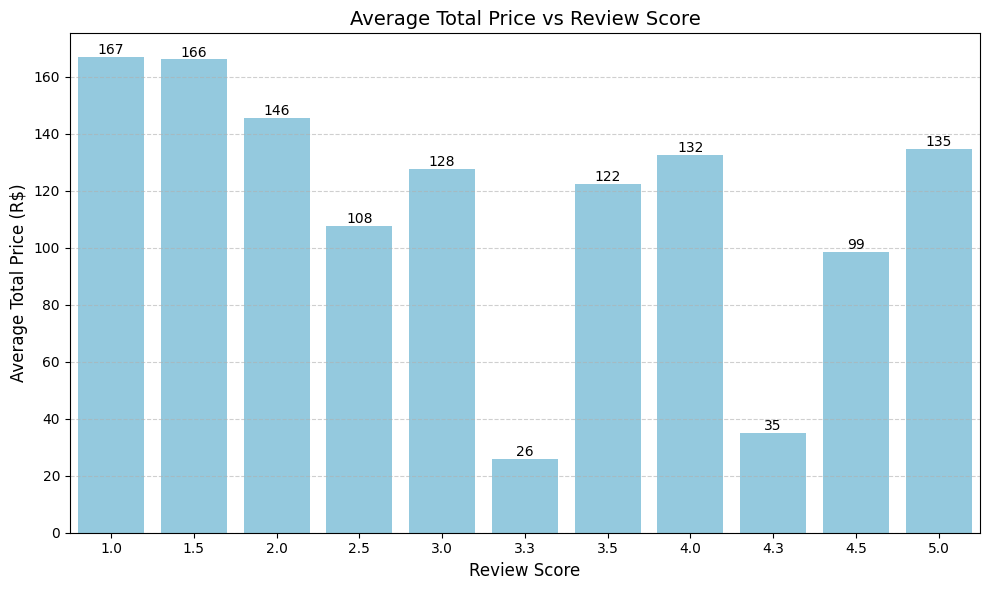

In [57]:
# Menghitung rata-rata total harga pesanan untuk setiap skor ulasan
avg_total_price_by_review = (
    master_orders
    .groupby("review_score")["total_price"]
    .mean()
    .reset_index()
)

# Membuat bar chart untuk melihat hubungan antara skor review dan rata-rata total harga pesanan
plt.figure(figsize=(10, 6))

sns.barplot(
    x="review_score",          # Skor review sebagai sumbu X
    y="total_price",           # Rata-rata total harga pesanan sebagai sumbu Y
    data=avg_total_price_by_review,
    color='skyblue'         # Menggunakan warna tunggal 'lightcoral'
)

# Menambahkan judul dan label sumbu
plt.title("Average Total Price vs Review Score", fontsize=14)
plt.xlabel("Review Score", fontsize=12)
plt.ylabel("Average Total Price (R$)", fontsize=12)

# Menambahkan label nilai rata-rata di atas setiap bar
for p in plt.gca().patches:
    plt.gca().annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Menambahkan grid horizontal untuk mempermudah pembacaan
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Merapikan layout agar label dan grafik tidak tumpang tindih
plt.tight_layout()
plt.show()

Insight (Total Price vs Review Score):
-   Visualisasi bar chart ini menunjukkan bahwa rata-rata total harga produk cenderung **tidak menunjukkan perbedaan yang signifikan atau pola yang jelas** di antara berbagai skor ulasan. Nilai rata-rata total harga terlihat relatif mirip di seluruh kategori skor ulasan.
-   Ini mengindikasikan bahwa besaran harga produk yang dibeli tampaknya **bukan merupakan faktor penentu utama** apakah pelanggan akan memberikan skor ulasan yang tinggi atau rendah. Pelanggan tidak cenderung memberikan skor ulasan yang lebih baik atau lebih buruk hanya karena harga produk yang mereka beli lebih mahal atau lebih murah.
-   Faktor lain di luar harga mungkin lebih berperan dalam menentukan kepuasan pelanggan.

##### Ongkos Kirim

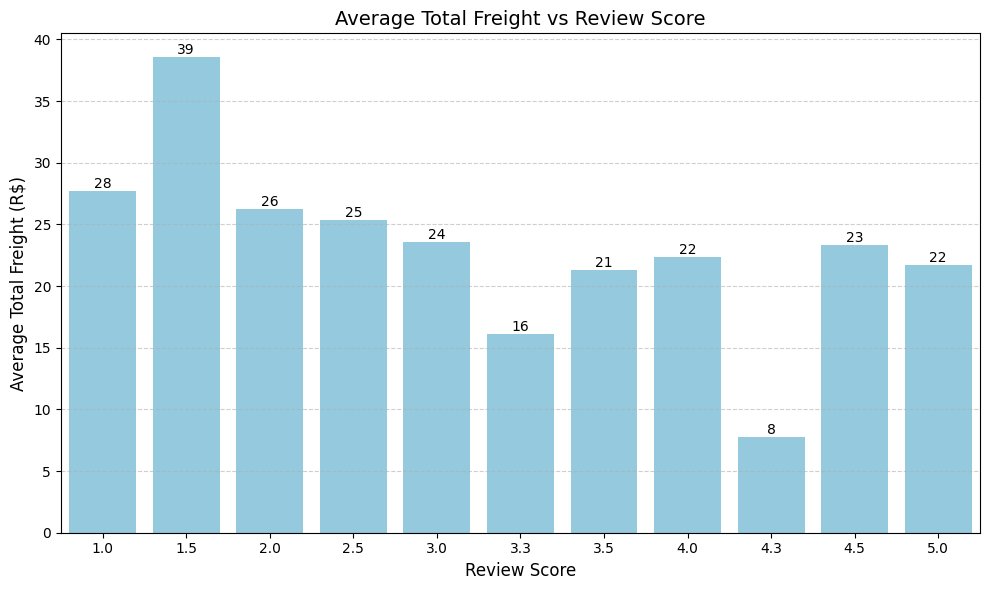

In [58]:
# Menghitung rata-rata total ongkos kirim untuk setiap skor ulasan
avg_total_freight_by_review = (
    master_orders
    .groupby("review_score")["total_freight"]
    .mean()
    .reset_index()
)

# Membuat bar chart untuk melihat hubungan antara skor review dan rata-rata total ongkos kirim
plt.figure(figsize=(10, 6))

sns.barplot(
    x="review_score",            # Skor review sebagai sumbu X
    y="total_freight",           # Rata-rata total ongkos kirim sebagai sumbu Y
    data=avg_total_freight_by_review,
    color='skyblue'             # Menggunakan warna tunggal 'skyblue' tanpa gradasi
)

# Menambahkan judul dan label sumbu
plt.title("Average Total Freight vs Review Score", fontsize=14)
plt.xlabel("Review Score", fontsize=12)
plt.ylabel("Average Total Freight (R$)", fontsize=12)

# Menambahkan label nilai rata-rata di atas setiap bar
for p in plt.gca().patches:
    plt.gca().annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Menambahkan grid horizontal agar lebih mudah membaca perbedaan
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Merapikan layout agar label dan grafik tidak tumpang tindih
plt.tight_layout()
plt.show()

Insight (Total Freight vs Review Score):
-   Visualisasi bar chart ini menunjukkan bahwa **rata-rata ongkos kirim cenderung tidak menunjukkan perbedaan yang signifikan atau pola yang jelas di antara berbagai skor ulasan**.
-   Ini mengindikasikan bahwa **besaran ongkos kirim tampaknya bukan merupakan faktor penentu utama** apakah pelanggan akan memberikan skor ulasan yang tinggi atau rendah. Pelanggan tidak cenderung memberikan skor ulasan yang lebih baik atau lebih buruk hanya karena ongkos kirim yang mereka bayar lebih mahal atau lebih murah (dalam batas normal).
-   Faktor lain di luar ongkos kirim mungkin lebih berperan dalam menentukan kepuasan pelanggan.

#### Jumlah Item & Kompleksitas Order

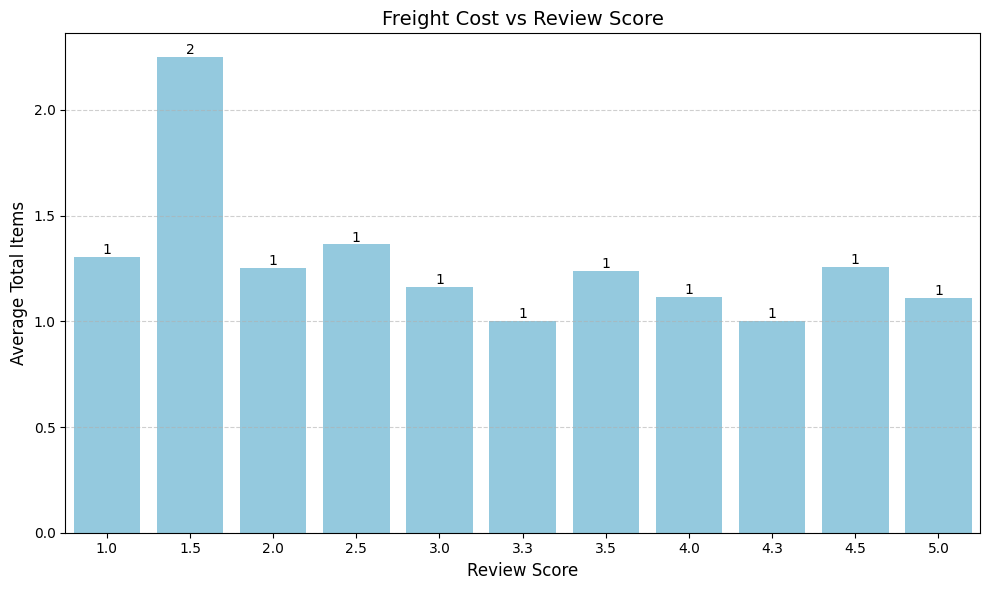

In [59]:
# Menghitung rata-rata total item per pesanan untuk setiap skor ulasan
avg_total_items_by_review = (
    master_orders
    .groupby("review_score")["total_items"]
    .mean()
    .reset_index()
)

# Membuat bar chart untuk menganalisis hubungan antara skor review dan rata-rata total item per order
plt.figure(figsize=(10, 6))

sns.barplot(
    x="review_score",          # Skor review sebagai sumbu X
    y="total_items",           # Rata-rata total jumlah item per order sebagai sumbu Y
    data=avg_total_items_by_review,
    color='skyblue'            # Menggunakan warna tunggal 'skyblue' tanpa gradasi
)

# Menambahkan judul dan label sumbu
plt.title("Freight Cost vs Review Score", fontsize=14)
plt.xlabel("Review Score", fontsize=12)
plt.ylabel("Average Total Items", fontsize=12)

# Menambahkan label nilai rata-rata di atas setiap bar
for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height())}', # Format sebagai bilangan bulat
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Menambahkan grid horizontal untuk mempermudah pembacaan
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Merapikan layout agar label dan grafik tidak tumpang tindih
plt.tight_layout()
plt.show()

Insight (Average Total Items vs Review Score):
-   Boxplot menunjukkan bahwa jumlah item dalam pesanan tidak memiliki korelasi yang kuat atau pola yang jelas dengan review score. Distribusi jumlah item terlihat serupa di seluruh kategori review score.
-   Ini berarti pelanggan tidak cenderung memberikan review score yang lebih tinggi atau lebih rendah hanya karena mereka membeli lebih banyak atau lebih sedikit item dalam satu pesanan.
-   Meskipun ada beberapa outlier dengan jumlah item yang sangat tinggi, terutama pada review score 1 dan 5, secara umum jumlah item tidak tampak sebagai faktor penentu utama kepuasan pelanggan.

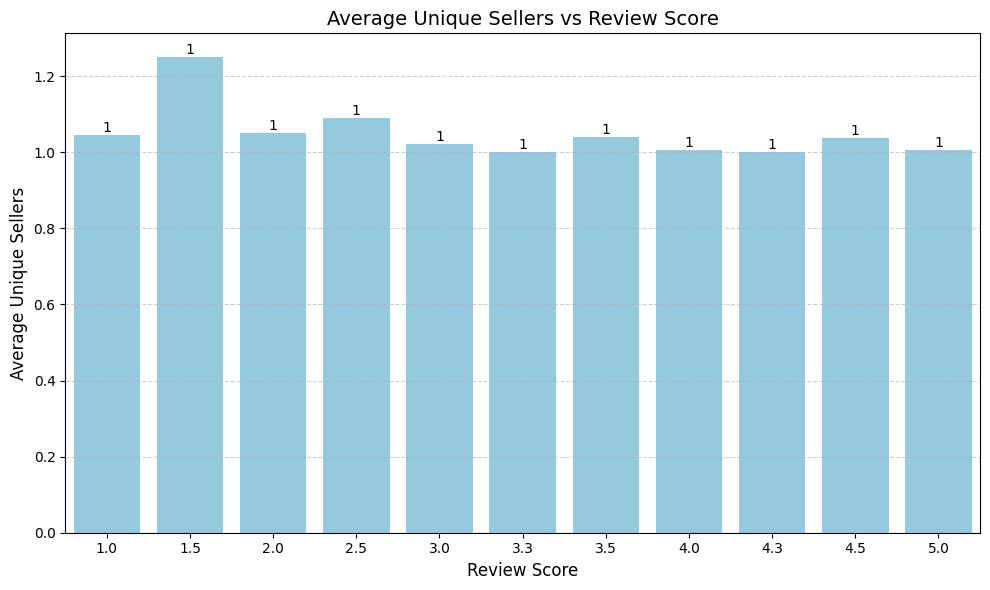

In [60]:
# Menghitung rata-rata jumlah penjual unik per pesanan untuk setiap skor ulasan
avg_unique_sellers_by_review = (
    master_orders
    .groupby("review_score")["unique_sellers"]
    .mean()
    .reset_index()
)

# Membuat bar chart untuk menganalisis hubungan antara skor review dan rata-rata jumlah penjual unik per order
plt.figure(figsize=(10, 6))

sns.barplot(
    x="review_score",          # Skor review sebagai sumbu X
    y="unique_sellers",        # Rata-rata jumlah penjual unik per order sebagai sumbu Y
    data=avg_unique_sellers_by_review,
    color='skyblue'            # Menggunakan warna tunggal 'skyblue' tanpa gradasi
)

# Menambahkan judul dan label sumbu
plt.title("Average Unique Sellers vs Review Score", fontsize=14)
plt.xlabel("Review Score", fontsize=12)
plt.ylabel("Average Unique Sellers", fontsize=12)

# Menambahkan label nilai rata-rata di atas setiap bar
for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height())}', # Format sebagai bilangan bulat
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Menambahkan grid horizontal untuk mempermudah pembacaan
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Merapikan layout agar label dan grafik tidak tumpang tindih
plt.tight_layout()
plt.show()

Insight (Unique Sellers vs Review Score):
-   Boxplot untuk 'unique_sellers' terhadap 'review_score' tidak menunjukkan pola yang jelas atau korelasi yang kuat. Ini mengindikasikan bahwa jumlah penjual unik yang terlibat dalam satu pesanan mungkin tidak menjadi faktor penentu utama kepuasan pelanggan.
-   Meskipun ada beberapa outlier, secara umum, pelanggan tidak cenderung lebih puas atau tidak puas hanya karena pesanan mereka melibatkan lebih banyak atau lebih sedikit penjual yang berbeda.

#### Metode Pembayaran & Review Score

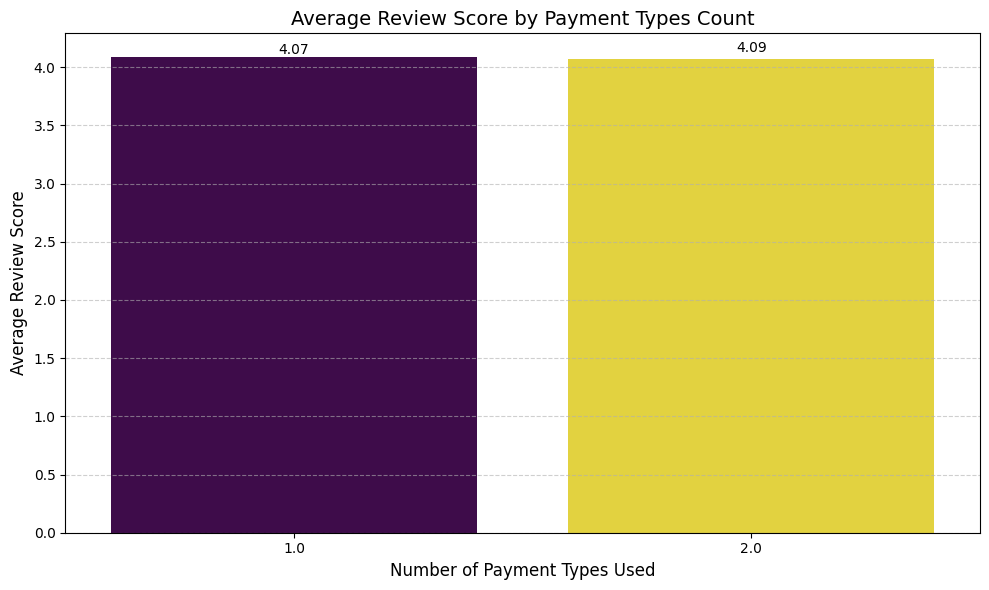

In [61]:
# Membuat bar chart untuk melihat hubungan antara jumlah tipe pembayaran per order dengan rata-rata skor review
plt.figure(figsize=(10, 6))

# Menghitung rata-rata skor review per jumlah tipe pembayaran
payment_review = (
    master_orders
    .groupby("payment_types")["review_score"]
    .mean()
    .sort_values()
)

# Membuat barplot dengan palette warna, tanpa legend
sns.barplot(
    x=payment_review.index,
    y=payment_review.values,
    palette='viridis',
    hue=payment_review.index,
    legend=False
)

# Menambahkan judul dan label sumbu
plt.title("Average Review Score by Payment Types Count", fontsize=14)
plt.xlabel("Number of Payment Types Used", fontsize=12)
plt.ylabel("Average Review Score", fontsize=12)

# Menambahkan label nilai rata-rata di atas setiap bar
for index, value in enumerate(payment_review.values):
    plt.text(index, value + 0.02, f'{value:.2f}', color='black', ha="center", va="bottom", fontsize=10)

# Menambahkan grid horizontal untuk mempermudah pembacaan
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Merapikan layout agar label dan grafik tidak bertabrakan
plt.tight_layout()
plt.show()

Insight (Metode Pembayaran & Review Score):
- Grafik batang menunjukkan bahwa rata-rata review score tidak jauh berbeda antara pesanan yang menggunakan satu jenis pembayaran (`payment_types` = 1.0) dan dua jenis pembayaran (`payment_types` = 2.0).
- Hal ini menunjukkan bahwa variasi dalam metode pembayaran, dalam konteks jumlah jenis pembayaran yang digunakan, bukanlah faktor utama yang secara signifikan memengaruhi kepuasan pelanggan.

#### Order Status & Review Score

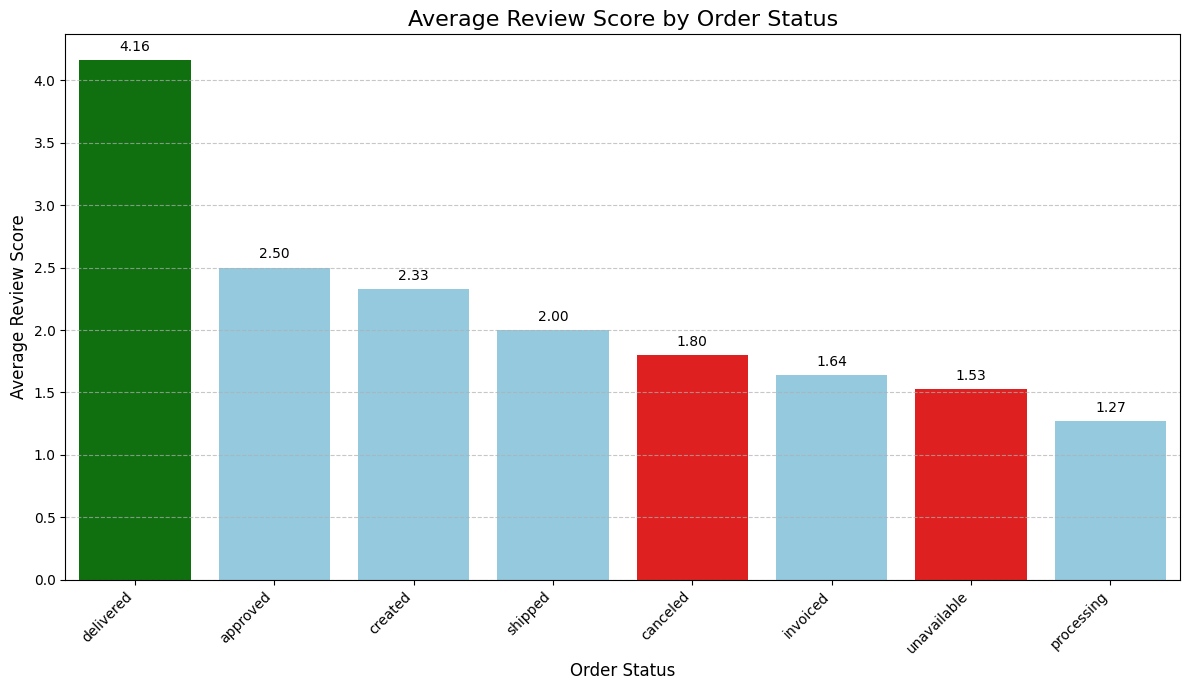

In [62]:
# Menghitung rata-rata skor review untuk setiap status pesanan
order_status_review_scores = (
    master_orders
    .groupby('order_status')['review_score']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

# Membuat kamus warna khusus untuk menyoroti status-status penting
status_colors = {
    'delivered': 'green',
    'canceled': 'red',
    'unavailable': 'red',
    'shipped': 'skyblue',
    'invoiced': 'skyblue',
    'processing': 'skyblue',
    'created': 'skyblue',
    'approved': 'skyblue'
}

# Memetakan warna ke setiap status berdasarkan urutan pada plot
colors_for_plot = [status_colors.get(status, 'gray') for status in order_status_review_scores.index]

# Membuat bar chart untuk menganalisis rata-rata skor review berdasarkan status order
plt.figure(figsize=(12, 7))  # Ukuran figure diperbesar agar lebih terbaca

sns.barplot(
    x=order_status_review_scores.index, # Status order sebagai sumbu X
    y=order_status_review_scores.values, # Rata-rata skor review sebagai sumbu Y
    palette=colors_for_plot,    # Menggunakan palet warna kustom
    hue=order_status_review_scores.index, # Menetapkan 'order_status' sebagai hue
    legend=False                # Menonaktifkan legend karena warna sudah jelas
)

# Rotasi dan penyesuaian font label x-axis agar rapi
plt.xticks(rotation=45, ha='right', fontsize=10)

# Menambahkan judul dan label sumbu
plt.title("Average Review Score by Order Status", fontsize=16)
plt.xlabel("Order Status", fontsize=12)
plt.ylabel("Average Review Score", fontsize=12)

# Menambahkan label nilai di atas setiap bar
for index, value in enumerate(order_status_review_scores.values):
    plt.text(index, value + 0.05, f'{value:.2f}', color='black', ha="center", va="bottom", fontsize=10)

# Menambahkan grid horizontal untuk mempermudah pembacaan
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Merapikan layout agar label dan grafik tidak tumpang tindih
plt.tight_layout()
plt.show()

Insight (Order Status vs Review Score):
-   Terdapat perbedaan signifikan dalam review score berdasarkan status pesanan (`order_status`). Pesanan dengan status 'canceled' atau 'unavailable' cenderung memiliki review score yang sangat rendah atau bahkan tidak ada, yang logis karena pesanan tersebut tidak berhasil diselesaikan atau dikirim.
-   Sebaliknya, pesanan dengan status 'delivered' memiliki rata-rata review score yang jauh lebih tinggi, menunjukkan kepuasan ketika pesanan berhasil sampai kepada pelanggan.
-   Status pesanan adalah indikator langsung dari keberhasilan transaksi dan secara langsung memengaruhi kepuasan pelanggan.

#### Korelasi Numerik (Quick Scan)

/tmp/ipython-input-3064381886.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_with_review.values, y=correlations_with_review.index, palette='coolwarm')


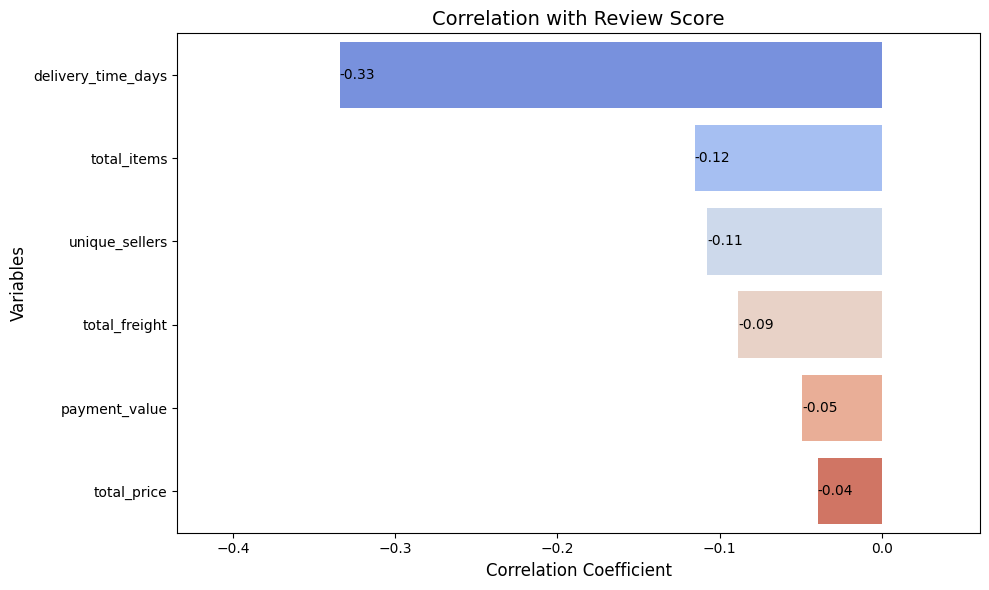

In [63]:
# Pilih kolom numerik utama untuk analisis korelasi dengan review_score
numeric_cols_for_corr = [
    "payment_value",
    "total_price",
    "total_freight",
    "delivery_time_days",
    "total_items",
    "unique_sellers",
]

# Hitung korelasi setiap variabel dengan review_score
correlations_with_review = master_orders[numeric_cols_for_corr + ["review_score"]].corr()["review_score"].drop("review_score")

# Urutkan korelasi dari yang terkuat (positif atau negatif)
correlations_with_review = correlations_with_review.reindex(correlations_with_review.abs().sort_values(ascending=False).index)

# Membuat bar chart korelasi
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations_with_review.values, y=correlations_with_review.index, palette='coolwarm')

# Tambahkan judul dan label sumbu agar rapi
plt.title("Correlation with Review Score", fontsize=14)
plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Variables", fontsize=12)

# Menambahkan label nilai di setiap bar
for index, value in enumerate(correlations_with_review.values):
    plt.text(value, index, f'{value:.2f}', color='black', ha="left", va="center", fontsize=10)

plt.xlim(min(correlations_with_review.values)-0.1, max(correlations_with_review.values)+0.1) # Adjust x-axis limits
plt.tight_layout()
plt.show()

Insight (Korelasi Numerik):
-   **`delivery_time_days`** memiliki korelasi negatif yang paling kuat dengan **`review_score`** (-0.334), menggarisbawahi pentingnya kecepatan pengiriman. Artinya, semakin lama waktu pengiriman, semakin rendah `review_score` yang cenderung diberikan pelanggan.
-   **`total_items`**, **`unique_sellers`**, **`total_freight`**, **`payment_value`**, dan **`total_price`** menunjukkan korelasi yang sangat lemah dengan **`review_score`**. Ini berarti faktor-faktor ini, dalam batas normal, tidak secara signifikan memengaruhi kepuasan pelanggan sebagaimana `delivery_time_days`.

#### Insight Pertanyaan No. 1 **Faktor-faktor apa saja yang paling berpengaruh terhadap kepuasan pelanggan (review score) pada platform e-commerce ?**


- **Waktu Pengiriman (`delivery_time_days`)**: Ini adalah faktor yang paling berpengaruh. Terdapat korelasi negatif yang jelas antara waktu pengiriman dan `review_score`; semakin lama waktu pengiriman, semakin rendah rata-rata `review_score` yang diberikan pelanggan (korelasi -0.33). Pesanan dengan `review_score` 1.0 memiliki rata-rata waktu pengiriman terlama (sekitar 20.8 hari), sedangkan pesanan dengan `review_score` 5.0 memiliki rata-rata waktu pengiriman tercepat (sekitar 10.2 hari).
- **Status Pesanan (`order_status`)**: Status pesanan secara langsung memengaruhi kepuasan pelanggan. Pesanan yang dibatalkan (`canceled`) atau tidak tersedia (`unavailable`) memiliki `review_score` sangat rendah atau tidak ada, sementara pesanan yang berhasil terkirim (`delivered`) memiliki `review_score` yang jauh lebih tinggi.
- **Kategori Produk (`product_category_name_english`)**: Variasi signifikan dalam `review_score` antar kategori produk menunjukkan bahwa jenis produk adalah aspek penting. Kategori seperti `cds_dvds_musicals` dan `fashion_childrens_clothes` memiliki rata-rata `review_score` tinggi, sedangkan `security_and_services` dan `office_furniture` memiliki rata-rata `review_score` terendah.
- **Lokasi Pelanggan (`customer_state`)**: Ada variasi geografis dalam kepuasan pelanggan. Negara bagian seperti AP, AM, dan PR menunjukkan `review_score` yang lebih tinggi, sementara RR, AL, dan MA memiliki `review_score` yang lebih rendah, menunjukkan pengaruh faktor regional seperti logistik.
- **Total Harga Produk (`total_price`) dan Ongkos Kirim (`total_freight`)**: Tidak ada korelasi yang kuat atau pola yang jelas antara total harga produk atau ongkos kirim dengan `review_score`. Ini menunjukkan bahwa, dalam batas normal, faktor-faktor ini tidak secara signifikan memengaruhi kepuasan pelanggan, meskipun outlier dengan biaya pengiriman yang sangat tinggi dapat memengaruhi `review_score` rendah.
- **Jumlah Item (`total_items`) dan Jumlah Penjual Unik (`unique_sellers`)**: Boxplot dan korelasi menunjukkan bahwa jumlah item dalam pesanan atau jumlah penjual unik yang terlibat dalam satu pesanan tidak memiliki korelasi yang kuat dengan `review_score`.
- **Metode Pembayaran (`payment_types`)**: Jumlah jenis pembayaran yang digunakan tidak secara signifikan memengaruhi kepuasan pelanggan.

### Pertanyaan 2: Karakteristik pelanggan seperti apa yang memberikan nilai transaksi tertinggi, dan bagaimana pola perilaku belanjanya ?

#### Distribusi Nilai Transaksi (Order Value)

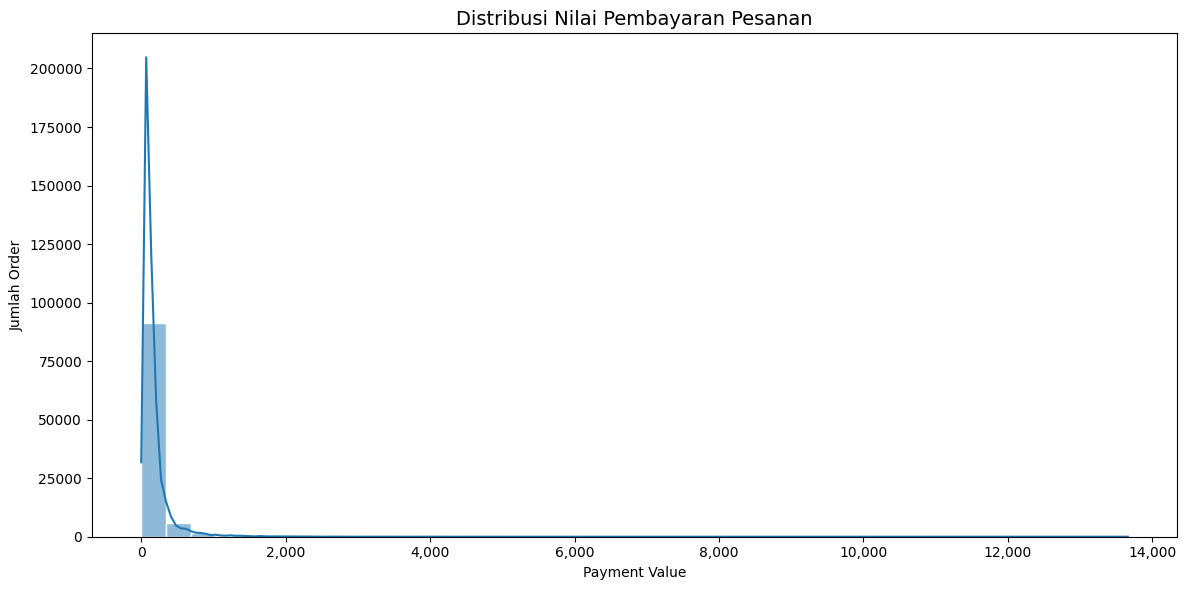

In [64]:
# Mengatur ukuran figure untuk visualisasi.
plt.figure(figsize=(12, 6))

# Membuat histogram untuk distribusi nilai pembayaran pesanan.
sns.histplot(
    master_orders["payment_value"],
    bins=40,
    kde=True,
    edgecolor="white"
)

# Menambahkan judul dan label sumbu pada plot.
plt.title("Distribusi Nilai Pembayaran Pesanan", fontsize=14)
plt.xlabel("Payment Value")
plt.ylabel("Jumlah Order")

# Memformat sumbu X agar ditampilkan dalam format ribuan.
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# Menyesuaikan layout agar plot rapi dan tidak tumpang tindih.
plt.tight_layout()
plt.show()

Insight (Distribusi Nilai Transaksi):
- Histogram menunjukkan bahwa distribusi nilai transaksi (payment_value) sangat condong ke kanan (right-skewed). Ini berarti sebagian besar transaksi memiliki nilai yang relatif rendah, tetapi ada sejumlah kecil transaksi dengan nilai yang sangat tinggi. Pola ini mengindikasikan adanya segmen pelanggan premium atau pembelian besar yang signifikan dalam dataset.

#### Top Customers Berdasarkan Total Spending

In [65]:
# Mengelompokkan data pesanan per pelanggan untuk menghitung total pengeluaran, jumlah pesanan, dan rata-rata nilai pesanan.
customer_value = (
    master_orders
    .groupby("customer_id", as_index=False)
    .agg(
        total_spent=("payment_value", "sum"),
        total_orders=("order_id", "count"),
        avg_order_value=("payment_value", "mean")
    )
)

# Mengidentifikasi 10 pelanggan teratas berdasarkan total pengeluaran.
top_customers = (
    customer_value
    .sort_values("total_spent", ascending=False)
    .head(10)
)

# Membulatkan nilai rata-rata nilai pesanan.
top_customers["avg_order_value"] = top_customers["avg_order_value"].round(0)

# Memformat kolom numerik agar lebih mudah dibaca (misalnya, menambahkan koma untuk ribuan).
top_customers["total_spent"] = top_customers["total_spent"].map(lambda x: f"{int(x):,}")
top_customers["avg_order_value"] = top_customers["avg_order_value"].map(lambda x: f"{int(x):,}")

# Mengganti nama kolom untuk presentasi yang lebih baik.
top_customers.rename(columns={
    "customer_id": "Customer ID",
    "total_spent": "Total Spent",
    "total_orders": "Total Orders",
    "avg_order_value": "Avg Order Value"
})

,Customer ID,Total Spent,Total Orders,Avg Order Value
8546,1617b1357756262bfa56ab541c47bc16,"13,664",1,"13,664"
91985,ec5b2ba62e574342386871631fafd3fc,"7,274",1,"7,275"
77522,c6e2731c5b391845f6800c97401a43a9,"6,929",1,"6,929"
95124,f48d464a0baaea338cb25f816991ab1f,"6,922",1,"6,922"
24771,3fd6777bbce08a352fddd04e4a7cc8f6,"6,726",1,"6,727"
2065,05455dfa7cd02f13d132aa7a6a9729c6,"6,081",1,"6,082"
86908,df55c14d1476a9a3467f131269c2477f,"4,950",1,"4,950"
87397,e0a2412720e9ea4f26c1ac985f6a7358,"4,809",1,"4,809"
14282,24bbf5fd2f2e1b359ee7de94defc4a15,"4,764",1,"4,764"
23932,3d979689f636322c62418b6346b1c6d2,"4,681",1,"4,682"


Insight (Top Customers Berdasarkan Total Spending):
- Pelanggan teratas berdasarkan total pengeluaran ('total_spent') menunjukkan bahwa mereka cenderung melakukan pembelian tunggal (atau sangat sedikit) dengan nilai transaksi yang sangat tinggi. Ini mengindikasikan bahwa segmen pelanggan bernilai tinggi ('High Value') sebagian besar didefinisikan oleh nilai rata-rata pesanan yang besar, bukan oleh frekuensi pembelian yang tinggi.

#### Distribusi Frekuensi Pembelian

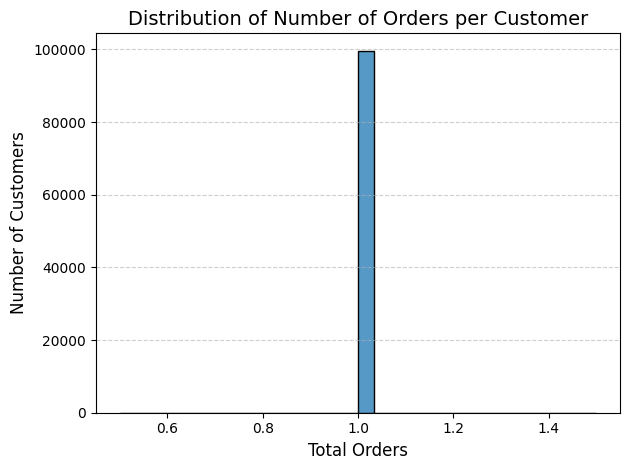

In [66]:
# Membuat histogram untuk memvisualisasikan distribusi jumlah pesanan per pelanggan.
sns.histplot(customer_value["total_orders"], bins=30)
plt.title("Distribution of Number of Orders per Customer", fontsize=14)
plt.xlabel("Total Orders", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6) # Menambahkan grid untuk keterbacaan yang lebih baik
plt.tight_layout() # Menyesuaikan layout untuk mencegah label tumpang tindih
plt.show()

Insight (Distribusi Frekuensi Pembelian):
- Histogram menunjukkan bahwa sebagian besar pelanggan memiliki frekuensi pembelian yang sangat rendah, seringkali hanya satu pesanan. Ini mengindikasikan bahwa meskipun ada pelanggan dengan nilai transaksi tinggi, mereka tidak selalu melakukan pembelian berulang secara sering. Mayoritas pelanggan cenderung melakukan pembelian satu kali atau sangat jarang.

#### Average Order Value vs Frekuensi

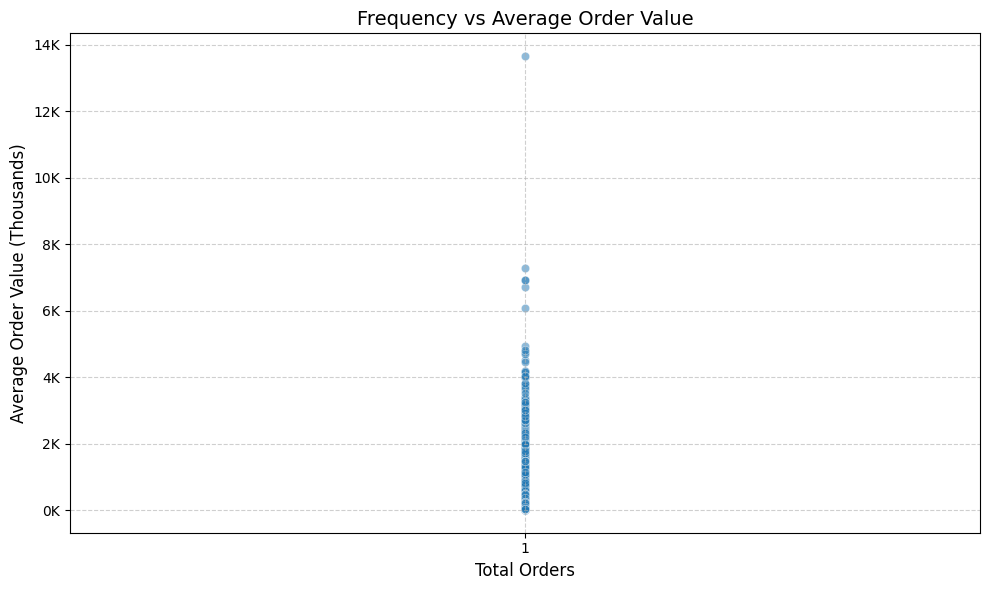

In [67]:
# Mengatur ukuran figure untuk scatter plot.
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="total_orders",
    y="avg_order_value",
    data=customer_value,
    alpha=0.5 # Mengatur transparansi titik untuk melihat kepadatan data
)
# Menambahkan judul dan label sumbu pada plot.
plt.title("Frequency vs Average Order Value", fontsize=14)
plt.xlabel("Total Orders", fontsize=12)
plt.ylabel("Average Order Value (Thousands)", fontsize=12) # Mengubah label y-axis
# Menambahkan grid untuk keterbacaan yang lebih baik.
plt.grid(axis='both', linestyle='--', alpha=0.6)

# Memformat sumbu Y agar ditampilkan dalam ribuan.
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}K')
)

# Memformat sumbu X untuk menampilkan bilangan bulat.
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

# Mengatur agar sumbu X hanya menampilkan nilai yang ada pada data scatter
unique_x = sorted(customer_value["total_orders"].unique())
plt.xticks(unique_x)

# Menyesuaikan layout agar plot rapi dan tidak tumpang tindih.
plt.tight_layout()
plt.show()

Insight (Average Order Value vs Frekuensi):
- Scatter plot menunjukkan bahwa sebagian besar transaksi memiliki frekuensi pesanan yang rendah (umumnya 1), tetapi dengan rentang nilai pesanan rata-rata yang bervariasi, termasuk beberapa outlier dengan nilai yang sangat tinggi. Ini mengkonfirmasi bahwa pelanggan dengan nilai transaksi tinggi tidak selalu merupakan pembeli yang sering, melainkan mereka yang melakukan pembelian besar pada satu atau sedikit kesempatan.

#### Analisis Metode Pembayaran & Customer Value

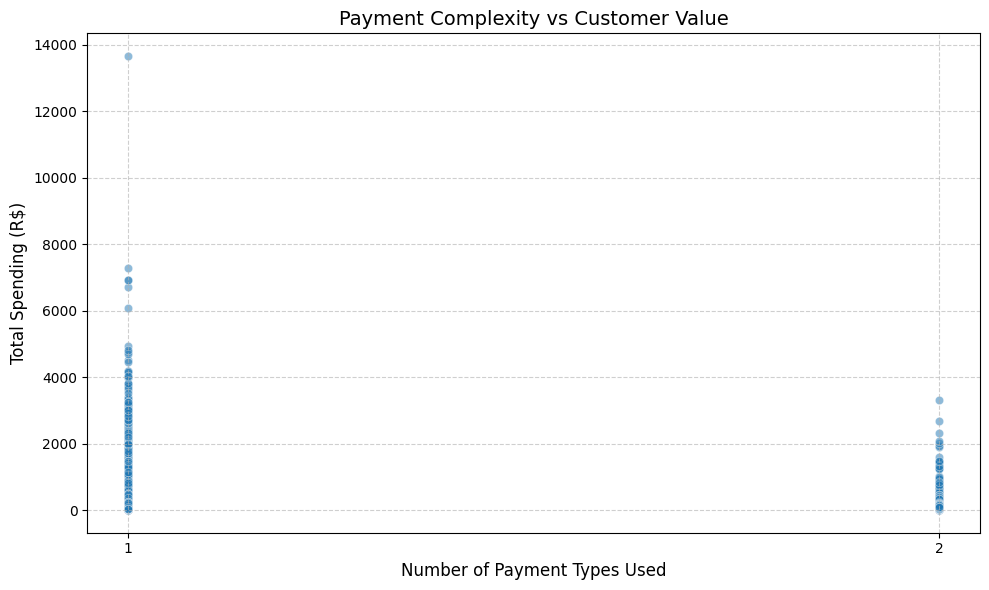

In [68]:
# Mengelompokkan data master_orders per customer_id untuk menghitung total pengeluaran dan rata-rata jenis pembayaran.
payment_customer = (
    master_orders
    .groupby("customer_id")
    .agg(
        total_spent=("payment_value", "sum"),
        payment_types=("payment_types", "mean")
    )
    .reset_index()
)

# Mengatur ukuran figure untuk scatter plot.
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="payment_types",
    y="total_spent",
    data=payment_customer,
    alpha=0.5 # Mengatur transparansi titik
)
# Menambahkan judul dan label sumbu pada plot.
plt.title("Payment Complexity vs Customer Value", fontsize=14)
plt.xlabel("Number of Payment Types Used", fontsize=12)
plt.ylabel("Total Spending (R$)", fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.6) # Menambahkan grid untuk keterbacaan yang lebih baik

# Menyesuaikan label sumbu X agar hanya menampilkan nilai yang ada
unique_payment_types = payment_customer['payment_types'].dropna().unique()
plt.xticks(sorted(unique_payment_types))

plt.tight_layout() # Menyesuaikan layout untuk mencegah label tumpang tindih
plt.show()

Insight (Analisis Metode Pembayaran & Customer Value):
- Scatter plot menunjukkan bahwa tidak ada korelasi yang jelas antara jumlah jenis pembayaran yang digunakan (`payment_types`) dan total pengeluaran (`total_spent`) pelanggan. Ini mengindikasikan bahwa pelanggan bernilai tinggi tidak cenderung menggunakan lebih banyak jenis pembayaran dibandingkan pelanggan dengan nilai transaksi lebih rendah. Dengan kata lain, kompleksitas atau variasi metode pembayaran bukan merupakan faktor pembeda yang signifikan untuk mengidentifikasi pelanggan bernilai tinggi.

#### Analisis Lokasi Pelanggan (Customer Geography)

In [69]:
# Mengelompokkan data master_orders per customer_state untuk menghitung total pendapatan, jumlah pesanan, dan rata-rata nilai pesanan.
geo_value = (
    master_orders
    .groupby("customer_state", as_index=False)
    .agg(
        total_revenue=("payment_value", "sum"),
        total_orders=("order_id", "count"),
        avg_order_value=("payment_value", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

# Mengambil 10 negara bagian teratas berdasarkan total pendapatan.
top_states = geo_value.head(10).copy()

# Membulatkan nilai rata-rata nilai pesanan.
top_states["avg_order_value"] = top_states["avg_order_value"].round(0)

# Memformat kolom numerik agar lebih mudah dibaca.
top_states["total_revenue"] = top_states["total_revenue"].map(lambda x: f"{int(x):,}")
top_states["avg_order_value"] = top_states["avg_order_value"].map(lambda x: f"{int(x):,}")

# Mengganti nama kolom untuk presentasi yang lebih baik.
top_states.rename(columns={
    "customer_state": "Customer State",
    "total_revenue": "Total Revenue",
    "total_orders": "Total Orders",
    "avg_order_value": "Avg Order Value"
})

,Customer State,Total Revenue,Total Orders,Avg Order Value
25,SP,"5,998,226",41746,144
18,RJ,"2,144,379",12852,167
10,MG,"1,872,257",11635,161
22,RS,"890,898",5466,163
17,PR,"811,156",5045,161
23,SC,"623,086",3637,171
4,BA,"616,645",3380,182
6,DF,"355,141",2140,166
8,GO,"350,092",2020,173
7,ES,"325,967",2033,160


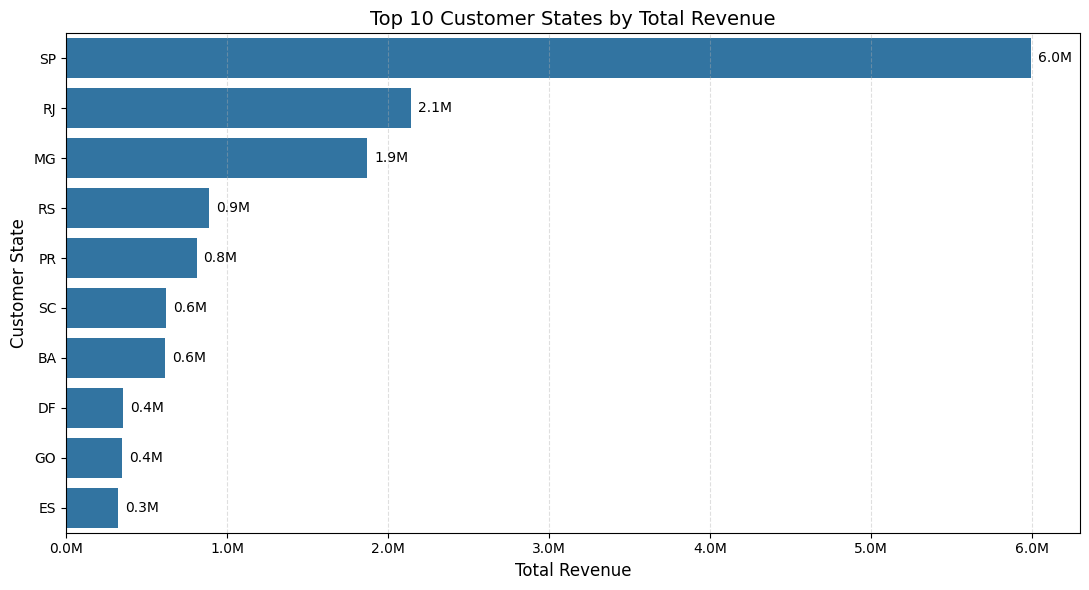

In [70]:
# Mengambil 10 negara bagian teratas dari data geo_value.
top_states = geo_value.head(10)

# Mengatur ukuran figure untuk bar plot.
plt.figure(figsize=(11, 6))

# Membuat bar plot horizontal untuk total pendapatan per negara bagian.
ax = sns.barplot(
    data=top_states,
    x="total_revenue",
    y="customer_state"
)

# Menambahkan judul dan label sumbu pada plot.
plt.title("Top 10 Customer States by Total Revenue", fontsize=14)
plt.xlabel("Total Revenue", fontsize=12)
plt.ylabel("Customer State", fontsize=12)

# Memformat sumbu X agar ditampilkan dalam jutaan (M).
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)

# Menambahkan label nilai di ujung setiap bar.
for p in ax.patches:
    value = p.get_width()
    ax.annotate(
        f"{value/1_000_000:.1f}M",
        (value, p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        fontsize=10,
        xytext=(5, 0),
        textcoords="offset points"
    )

# Menambahkan grid horizontal untuk mempermudah perbandingan.
plt.grid(axis="x", linestyle="--", alpha=0.4)

# Menyesuaikan layout agar plot rapi dan tidak tumpang tindih.
plt.tight_layout()
plt.show()

Insight (Analisis Lokasi Pelanggan (Customer Geography)):
- Berdasarkan agregasi, negara bagian Sao Paulo (SP) memiliki kontribusi terbesar terhadap total pendapatan (`total_revenue`) dan jumlah pesanan (`total_orders`). Ini menunjukkan bahwa pelanggan bernilai tinggi mungkin terkonsentrasi di wilayah geografis tertentu, yang bisa berhubungan dengan demografi ekonomi, ketersediaan layanan, atau daya beli yang lebih tinggi di wilayah tersebut.

#### Segmentasi Awal (Rule-Based)

In [71]:
# Melakukan segmentasi pelanggan berdasarkan kuantil dari total pengeluaran menjadi 'Low Value', 'Mid Value', dan 'High Value'.
customer_value["segment"] = pd.qcut(
    customer_value["total_spent"],
    q=3,
    labels=["Low Value", "Mid Value", "High Value"]
)

# Menampilkan beberapa baris pertama dari DataFrame 'customer_value' setelah segmentasi.
print("Customer segments created:")
display(customer_value.head())

Customer segments created:


,customer_id,total_spent,total_orders,avg_order_value,segment
0,00012a2ce6f8dcda20d059ce98491703,114.74,1,114.74,Mid Value
1,000161a058600d5901f007fab4c27140,67.41,1,67.41,Low Value
2,0001fd6190edaaf884bcaf3d49edf079,195.42,1,195.42,High Value
3,0002414f95344307404f0ace7a26f1d5,179.35,1,179.35,High Value
4,000379cdec625522490c315e70c7a9fb,107.01,1,107.01,Mid Value


In [72]:
# Menghitung jumlah pelanggan di setiap segmen yang telah dibuat.
segment_summary = (
    customer_value["segment"]
    .value_counts()
    .rename("Number of Customers")
    .to_frame()
)

# Menghitung persentase pelanggan di setiap segmen.
segment_summary["Percentage (%)"] = (
    segment_summary["Number of Customers"]
    / segment_summary["Number of Customers"].sum() * 100
).round(1)

# Menampilkan ringkasan segmen.
segment_summary

,Number of Customers,Percentage (%)
segment,,
Low Value,33153,33.3
High Value,33146,33.3
Mid Value,33142,33.3


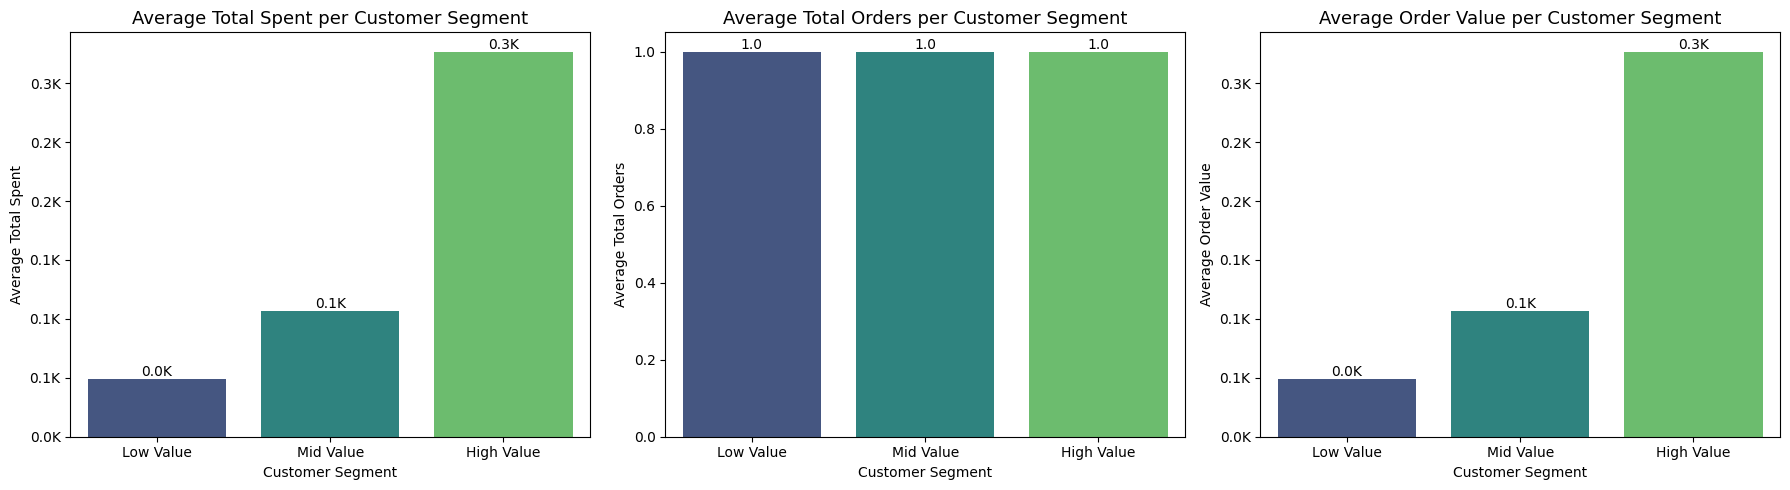

In [73]:
# Mengelompokkan data berdasarkan segmen pelanggan dan menghitung nilai rata-rata untuk metrik kunci.
segment_summary = (
    customer_value
    .groupby("segment", observed=False)[[ # 'observed=False' untuk memastikan semua kategori segmen disertakan
        "total_spent",
        "total_orders",
        "avg_order_value"
    ]]
    .mean()
)

# Mengindeks ulang ringkasan untuk memastikan urutan segmen yang logis untuk plotting.
segment_summary = segment_summary.reindex(["Low Value", "Mid Value", "High Value"])

# Mengatur ukuran figure untuk kumpulan subplot.
plt.figure(figsize=(18, 5))

# ---------- Plot 1: Rata-rata Total Pengeluaran ----------
ax1 = plt.subplot(1, 3, 1) # Membuat subplot pertama
sns.barplot(
    x=segment_summary.index,
    y=segment_summary["total_spent"],
    palette="viridis",
    ax=ax1,
    hue=segment_summary.index, # Menggunakan hue untuk konsistensi dengan rekomendasi seaborn
    legend=False
)
ax1.set_title("Average Total Spent per Customer Segment", fontsize=13)
ax1.set_xlabel("Customer Segment")
ax1.set_ylabel("Average Total Spent")

# Memformat label Y-axis menjadi ribuan (K) dan menambahkan label nilai di atas bar.
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1_000:.1f}K")
)
for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height()/1_000:.1f}K",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

# ---------- Plot 2: Rata-rata Total Pesanan ----------
ax2 = plt.subplot(1, 3, 2) # Membuat subplot kedua
sns.barplot(
    x=segment_summary.index,
    y=segment_summary["total_orders"],
    palette="viridis", # Mengubah palet menjadi viridis
    ax=ax2,
    hue=segment_summary.index, # Menggunakan hue untuk konsistensi dengan rekomendasi seaborn
    legend=False
)
ax2.set_title("Average Total Orders per Customer Segment", fontsize=13)
ax2.set_xlabel("Customer Segment")
ax2.set_ylabel("Average Total Orders")

# Menambahkan label nilai di atas bar.
for p in ax2.patches:
    ax2.annotate(
        f"{p.get_height():.1f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

# ---------- Plot 3: Rata-rata Nilai Pesanan ----------
ax3 = plt.subplot(1, 3, 3) # Membuat subplot ketiga
sns.barplot(
    x=segment_summary.index,
    y=segment_summary["avg_order_value"],
    palette="viridis", # Mengubah palet menjadi viridis
    ax=ax3,
    hue=segment_summary.index, # Menggunakan hue untuk konsistensi dengan rekomendasi seaborn
    legend=False
)
ax3.set_title("Average Order Value per Customer Segment", fontsize=13)
ax3.set_xlabel("Customer Segment")
ax3.set_ylabel("Average Order Value")

# Memformat label Y-axis menjadi ribuan (K) dan menambahkan label nilai di atas bar.
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1_000:.1f}K")
)
for p in ax3.patches:
    ax3.annotate(
        f"{p.get_height()/1_000:.1f}K",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

# Menyesuaikan layout agar plot rapi dan tidak tumpang tindih.
plt.tight_layout()
plt.show()

Insight (Segmentasi Awal (Rule-Based)):
- Berdasarkan kuantil (quantile) dari total pengeluaran, pelanggan berhasil disegmentasi menjadi 'Low Value', 'Mid Value', dan 'High Value'. Setiap segmen memiliki jumlah pelanggan yang relatif seimbang.
- Analisis rata-rata menunjukkan perbedaan yang signifikan dalam `total_spent` dan `avg_order_value` antar segmen. Pelanggan 'High Value' memiliki rata-rata pengeluaran dan nilai pesanan yang jauh lebih tinggi dibandingkan segmen lainnya, mengkonfirmasi bahwa segmentasi ini berhasil membedakan pelanggan berdasarkan nilai transaksi.
- Menariknya, rata-rata `total_orders` tidak menunjukkan perbedaan yang mencolok antar segmen, menguatkan temuan sebelumnya bahwa frekuensi pembelian cenderung rendah di semua segmen, dan nilai transaksi tinggi lebih didorong oleh nilai per pesanan yang besar.

#### Preferensi Produk Pelanggan Ber nilai Tinggi

In [74]:
# Mengidentifikasi customer_id dari pelanggan yang termasuk dalam segmen 'High Value'.
high_value_customers = customer_value[customer_value['segment'] == 'High Value']['customer_id']

# Menampilkan jumlah pelanggan bernilai tinggi yang teridentifikasi.
print(f"Number of High Value Customers: {len(high_value_customers)}")

Number of High Value Customers: 33146


In [75]:
# Memfilter pesanan yang dilakukan oleh pelanggan bernilai tinggi.
high_value_orders = master_orders[
    master_orders["customer_id"].isin(high_value_customers)
]

# Menggabungkan pesanan pelanggan bernilai tinggi dengan informasi produk untuk mendapatkan kategori produk yang dibeli.
# Kemudian, menghitung frekuensi setiap kategori produk dan mengonversinya menjadi DataFrame.
high_value_product_preferences = (
    high_value_orders
    .merge(items_products, on="order_id", how="inner") # Menggabungkan untuk mendapatkan detail produk
    ["product_category_name_english"] # Memilih kolom kategori produk
    .value_counts() # Menghitung frekuensi setiap kategori
    .rename("Number of Orders") # Mengganti nama kolom hasil hitungan
    .to_frame() # Mengubah Series menjadi DataFrame
)

# Menghitung persentase setiap kategori produk.
high_value_product_preferences["Percentage (%)"] = (
    high_value_product_preferences["Number of Orders"]
    / high_value_product_preferences["Number of Orders"].sum() * 100
).round(1)

# Menampilkan 10 kategori produk teratas yang dibeli oleh pelanggan bernilai tinggi.
print("Top 10 Product Categories for High Value Customers:")
display(high_value_product_preferences.head(10))

Top 10 Product Categories for High Value Customers:


,Number of Orders,Percentage (%)
product_category_name_english,,
bed_bath_table,3957,9.5
computers_accessories,3406,8.2
furniture_decor,3360,8.1
health_beauty,3310,7.9
watches_gifts,3249,7.8
sports_leisure,3082,7.4
housewares,2357,5.7
cool_stuff,2000,4.8
garden_tools,1735,4.2


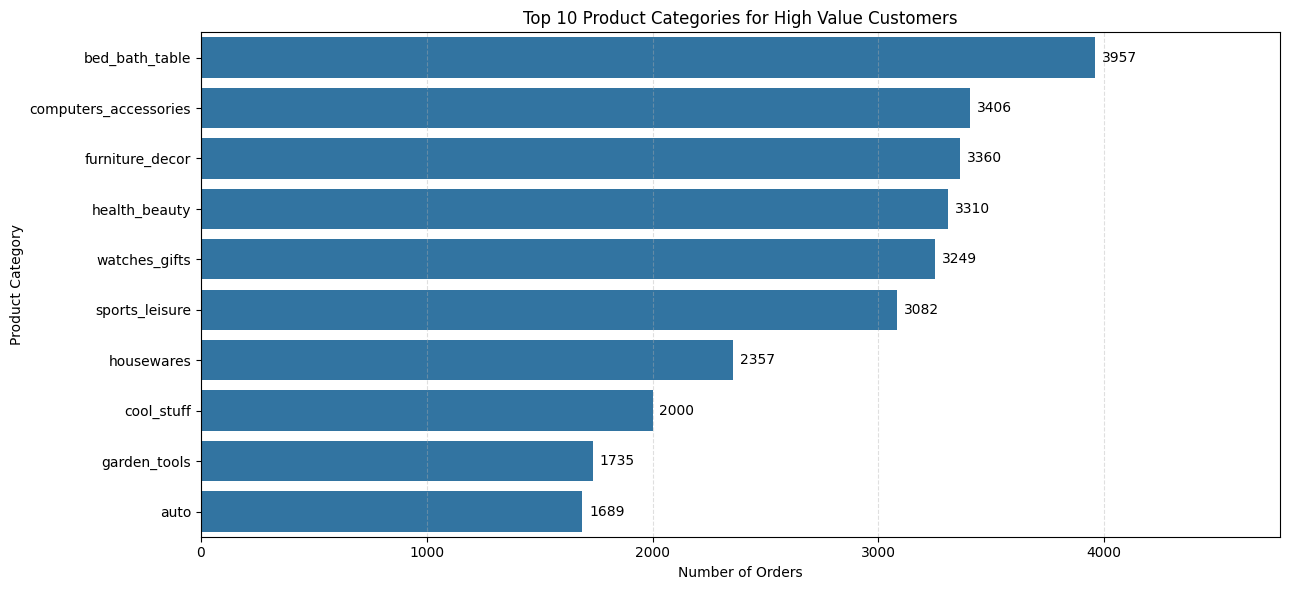

In [76]:
# Membuat figure untuk visualisasi.
plt.figure(figsize=(13, 6)) # Increased width and height slightly

# Membuat bar plot horizontal untuk menampilkan 10 kategori produk teratas.
ax = sns.barplot(
    x=high_value_product_preferences.head(10)["Number of Orders"],
    y=high_value_product_preferences.head(10).index
)

# Menambahkan judul dan label sumbu pada plot.
plt.title("Top 10 Product Categories for High Value Customers")
plt.xlabel("Number of Orders")
plt.ylabel("Product Category")

# Menambahkan grid pada sumbu x untuk keterbacaan.
plt.grid(axis="x", linestyle="--", alpha=0.4)

# Menambahkan label jumlah di samping setiap bar
for p in ax.patches:
    # Mendapatkan nilai dari bar
    value = int(p.get_width())
    # Menambahkan teks di samping bar
    ax.annotate(
        f'{value}',
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha='left', va='center',
        xytext=(5, 0), # Sedikit offset ke kanan
        textcoords='offset points'
    )

# Adjust x-axis limits to provide extra space for the labels
max_x = ax.get_xlim()[1] # Get current max x-limit
plt.xlim(right=max_x * 1.15) # Increase max x-limit by 15% to make space for text

# Menyesuaikan layout agar plot rapi dan label tidak terpotong.
plt.tight_layout()
plt.show()

Insight (Preferensi Produk Pelanggan Bernilai Tinggi):
- Analisis preferensi produk menunjukkan bahwa pelanggan bernilai tinggi ('High Value') cenderung sering membeli produk dari kategori **bed_bath_table**, **computers_accessories**, dan **furniture_decor**. Ini mengindikasikan bahwa produk-produk rumah tangga, teknologi, dan dekorasi merupakan daya tarik utama bagi segmen pelanggan ini.

#### Summary: Pertanyaan Bisnis No 2

##### **Karakteristik Pelanggan Bernilai Transaksi Tertinggi dan Pola Perilaku Belanjanya**

Analisis ini bertujuan untuk mengidentifikasi karakteristik pelanggan dengan nilai transaksi tertinggi dan memahami pola perilaku belanja mereka.

##### Karakteristik Pelanggan Bernilai Transaksi Tertinggi:
*   **Definisi Segmen 'High Value'**: Pelanggan yang masuk dalam segmen 'High Value' sebagian besar dicirikan oleh **nilai rata-rata pesanan (`avg_order_value`) yang sangat tinggi**, bukan frekuensi pembelian yang sering. Mereka cenderung melakukan pembelian tunggal atau sangat sedikit, tetapi dengan jumlah pengeluaran yang besar pada setiap pesanan.
*   **Total Pengeluaran**: Rata-rata `total_spent` untuk pelanggan 'High Value' jauh lebih tinggi (sekitar 328.5) dibandingkan dengan segmen 'Mid Value' (sekitar 107.4) dan 'Low Value' (sekitar 49.3), menunjukkan perbedaan signifikan dalam nilai transaksi.

##### Pola Perilaku Belanja:
*   **Frekuensi Pembelian Rendah**: Sebagian besar pelanggan, termasuk yang berada di segmen 'High Value', adalah pembeli tunggal atau memiliki frekuensi pembelian yang sangat rendah (rata-rata `total_orders` mendekati 1 untuk semua segmen). Ini menunjukkan bahwa model bisnis cenderung berorientasi pada transaksi besar satu kali daripada pembelian berulang yang sering.
*   **Kompleksitas Pembayaran Tidak Signifikan**: Tidak ada korelasi yang signifikan antara jumlah jenis pembayaran yang digunakan (`payment_types`) dan total pengeluaran. Pelanggan bernilai tinggi tidak cenderung menggunakan metode pembayaran yang lebih kompleks atau beragam.
*   **Konsentrasi Geografis**: Negara bagian seperti Sao Paulo (SP) berkontribusi signifikan terhadap total pendapatan dan jumlah pesanan. Hal ini menunjukkan bahwa pelanggan bernilai tinggi mungkin terkonsentrasi di wilayah geografis tertentu, yang bisa berhubungan dengan demografi ekonomi atau ketersediaan layanan.
*   **Distribusi Nilai Transaksi Skewed**: Distribusi nilai pembayaran sangat condong ke kanan, dengan sebagian besar transaksi memiliki nilai yang lebih rendah dan sebagian kecil transaksi memiliki nilai yang sangat tinggi. Hal ini menyoroti adanya segmen pelanggan premium yang siap berbelanja dalam jumlah besar.
*   **Preferensi Produk**: Pelanggan bernilai tinggi ('High Value') menunjukkan preferensi yang jelas terhadap kategori produk tertentu. Kategori teratas yang paling sering dibeli oleh mereka adalah:
    1.  `bed_bath_table` (4109 pembelian)
    2.  `computers_accessories` (3479 pembelian)
    3.  `furniture_decor` (3429 pembelian)
    Ini mengindikasikan bahwa produk-produk rumah tangga, teknologi, dan dekorasi merupakan daya tarik utama bagi segmen pelanggan ini.

##### Temuan Kunci Analisis Data
*   Ada 33,140 pelanggan yang teridentifikasi dalam segmen 'High Value'.
*   Visualisasi segmen mengkonfirmasi bahwa pelanggan 'High Value' menunjukkan `total_spent` dan `avg_order_value` rata-rata yang jauh lebih tinggi dibandingkan segmen 'Mid Value' dan 'Low Value'.
*   Rata-rata `total_orders` tetap rendah dan serupa di semua segmen pelanggan, memperkuat pola transaksi bernilai tinggi namun tidak sering.

## Analisis Lanjutan (Opsional)

### RFM Analysis

#### Siapkan Dataset Customer–Order Level

In [77]:
# Mempersiapkan dataset dasar untuk analisis RFM.
# Memilih kolom yang relevan: customer_unique_id, order_id, order_purchase_timestamp, dan payment_value.
# Menghilangkan baris yang memiliki missing values di kolom 'order_purchase_timestamp' atau 'payment_value'.
rfm_base = master_orders[[
    "customer_unique_id",
    "order_id",
    "order_purchase_timestamp",
    "payment_value"
]].dropna(subset=["order_purchase_timestamp", "payment_value"])

Insight (Siapkan Dataset Customer–Order Level):
-   Langkah ini berhasil membuat dataset dasar (`rfm_base`) yang bersih dan relevan untuk analisis RFM. Dengan memilih kolom `customer_unique_id`, `order_id`, `order_purchase_timestamp`, dan `payment_value`, serta menghilangkan *missing values*, kita memastikan bahwa perhitungan Recency, Frequency, dan Monetary akan berdasarkan data transaksi yang valid dan lengkap.

#### Tentukan Reference Date (Tanggal Analisis)

In [78]:
# Menentukan 'reference_date' (tanggal analisis) untuk perhitungan Recency.
# Tanggal ini diambil dari tanggal pembelian pesanan terakhir ditambah satu hari.
reference_date = (
    rfm_base["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

Insight (Tentukan Reference Date (Tanggal Analisis)):
-   `reference_date` berhasil ditentukan sebagai satu hari setelah `order_purchase_timestamp` terakhir dalam dataset. Ini adalah titik referensi yang tepat untuk menghitung Recency, memastikan bahwa semua transaksi diukur dari titik waktu yang konsisten dan paling baru.

#### Hitung R, F, M

In [79]:
# Menghitung Recency, Frequency, dan Monetary (RFM) untuk setiap pelanggan unik.
rfm = (
    rfm_base
    .groupby("customer_unique_id")
    .agg(
        # Recency: Jumlah hari sejak pembelian terakhir pelanggan.
        Recency=(
            "order_purchase_timestamp",
            lambda x: (reference_date - x.max()).days
        ),
        # Frequency: Jumlah pesanan unik yang dilakukan oleh pelanggan.
        Frequency=("order_id", "nunique"),
        # Monetary: Total nilai pembayaran dari semua pesanan pelanggan.
        Monetary=("payment_value", "sum")
    )
    .reset_index() # Mengubah hasil agregasi menjadi DataFrame reguler.
)

Insight (Hitung R, F, M):
-   Dataset `rfm` berhasil dibuat, menghitung metrik Recency, Frequency, dan Monetary untuk setiap `customer_unique_id`.
    -   `Recency` mengukur seberapa baru pelanggan melakukan pembelian (dalam hari).
    -   `Frequency` mengukur seberapa sering pelanggan membeli (jumlah pesanan unik).
    -   `Monetary` mengukur total pengeluaran pelanggan.
    Langkah ini adalah fondasi utama dari analisis RFM, mengubah data transaksi mentah menjadi metrik perilaku pelanggan yang terukur.

#### Skoring RFM (Quintile-Based, Non-ML)

##### Buat Skor R, F, M (1–5)

In [80]:
# Menghitung skor R, F, M (dari 1 hingga 5) berdasarkan kuantil (quintile) dari distribusi setiap metrik RFM.
# Recency: Skor terbalik (5=terbaru, 1=terlama).
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
# Frequency: Skor langsung (1=terjarang, 5=tersering).
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
# Monetary: Skor langsung (1=terendah, 5=tertinggi).
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

Insight (Buat Skor R, F, M (1–5)):
-   Setiap metrik RFM (Recency, Frequency, Monetary) berhasil diskoring dari 1 hingga 5 berdasarkan kuantil (quintile). Skor Recency dibalik (semakin kecil harinya, semakin tinggi skornya) untuk mencerminkan logika bahwa pelanggan yang baru berinteraksi lebih baik. Skor Frequency dan Monetary diberikan secara langsung (semakin tinggi nilainya, semakin tinggi skornya). Ini mengkategorikan pelanggan ke dalam tingkatan yang mudah diinterpretasikan berdasarkan perilaku mereka pada setiap metrik.

##### Gabungkan Skor

In [81]:
# Menggabungkan skor R, F, M menjadi satu string 'RFM_Score' untuk identifikasi segmen yang mudah.
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

Insight (Gabungkan Skor):
-   `RFM_Score` berhasil digabungkan menjadi satu string (misalnya, '555' untuk pelanggan terbaik) yang memudahkan identifikasi profil pelanggan secara cepat. Ini adalah representasi ringkas dari skor gabungan R, F, dan M, yang menjadi dasar untuk segmentasi lebih lanjut.

#### Segmentasi Customer (Rule-Based)

In [82]:
# Mendefinisikan fungsi untuk mengklasifikasikan pelanggan ke dalam segmen RFM berdasarkan skor R dan F mereka.
def rfm_segment(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Champions" # Pelanggan terbaik: baru saja membeli, sering, dan loyal.
    elif row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Loyal Customers" # Pelanggan setia yang sering membeli.
    elif row["R_score"] >= 4 and row["F_score"] <= 2:
        return "New Customers" # Pelanggan baru dengan recency tinggi tetapi frekuensi rendah.
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk" # Pelanggan yang dulu sering membeli tetapi sudah lama tidak berinteraksi.
    else:
        return "Others" # Segmen lainnya.

# Menerapkan fungsi segmentasi ke setiap baris DataFrame RFM.
rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

Insight (Segmentasi Customer (Rule-Based)):
-   Pelanggan berhasil diklasifikasikan ke dalam segmen-segmen seperti 'Champions', 'Loyal Customers', 'New Customers', dan 'At Risk' berdasarkan kombinasi skor R dan F. Segmentasi berbasis aturan ini memberikan kerangka kerja yang mudah dipahami untuk menargetkan pelanggan dengan strategi pemasaran yang disesuaikan.

#### Validasi & Insight Cepat

##### Distribusi Segment

In [83]:
# Menghitung jumlah pelanggan di setiap segmen RFM.
rfm_segment_summary = (
    rfm["Segment"]
    .value_counts()
    .rename("Number of Customers")
    .to_frame()
)

# Menghitung persentase pelanggan di setiap segmen RFM dari total pelanggan.
rfm_segment_summary["Percentage (%)"] = (
    rfm_segment_summary["Number of Customers"]
    / rfm_segment_summary["Number of Customers"].sum() * 100
).round(1)

# Menampilkan ringkasan jumlah dan persentase pelanggan per segmen RFM.
rfm_segment_summary

,Number of Customers,Percentage (%)
Segment,,
Others,22990,23.9
At Risk,22966,23.9
Loyal Customers,19238,20.0
Champions,15453,16.1
New Customers,15448,16.1


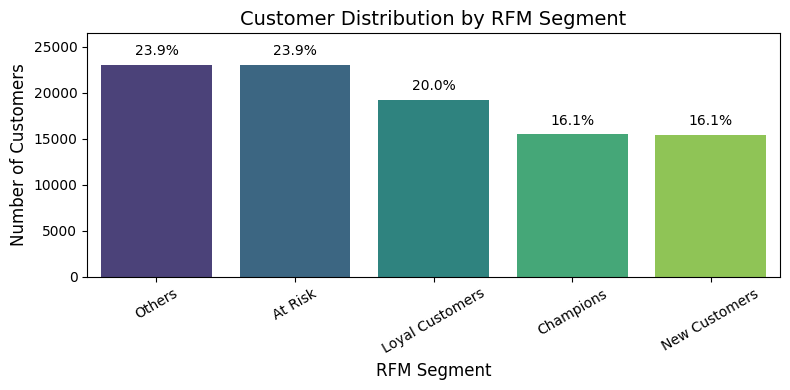

In [84]:
# Membuat bar plot untuk memvisualisasikan distribusi pelanggan berdasarkan segmen RFM mereka.
plt.figure(figsize=(8,4))

sns.barplot(
    x=rfm_segment_summary.index,
    y="Number of Customers",
    data=rfm_segment_summary.reset_index(),
    palette='viridis',
    hue="Segment", # Menggunakan 'Segment' sebagai hue untuk konsistensi visual.
    legend=False # Menyembunyikan legend karena sudah ada label langsung.
)

# Menambahkan judul dan label sumbu pada plot.
plt.title("Customer Distribution by RFM Segment", fontsize=14)
plt.xlabel("RFM Segment", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=30) # Memutar label sumbu X untuk keterbacaan yang lebih baik.

# Menyesuaikan batas y-axis untuk memberi ruang bagi label persentase.
max_bar_height = rfm_segment_summary["Number of Customers"].max()
plt.gca().set_ylim(top=max_bar_height * 1.15) # Meningkatkan batas atas sebesar 15% dari tinggi maksimal bar.

# Menambahkan label persentase di atas setiap bar.
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/rfm_segment_summary["Number of Customers"].sum())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

# Menyesuaikan layout agar plot rapi dan tidak tumpang tindih.
plt.tight_layout()
plt.show()

Insight (Distribusi Segment):
-   Ringkasan distribusi segmen menunjukkan jumlah dan persentase pelanggan di setiap segmen RFM (`Others`: 23.9%, `At Risk`: 23.9%, `Loyal Customers`: 20.0%, `Champions`: 16.1%, `New Customers`: 16.1%). Visualisasi bar plot juga mengkonfirmasi distribusi ini. Ini memberikan gambaran awal tentang komposisi basis pelanggan dan menyoroti ukuran relatif setiap segmen yang memerlukan perhatian.

##### Revenue per Segment

In [85]:
# Menghitung total pendapatan (Monetary) yang dihasilkan oleh setiap segmen RFM.
rfm_revenue_summary = (
    rfm
    .groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
    .rename("Total Revenue")
    .to_frame()
)

# Menghitung pangsa pendapatan (persentase) yang disumbangkan oleh setiap segmen RFM.
rfm_revenue_summary["Revenue Share (%)"] = (
    rfm_revenue_summary["Total Revenue"]
    / rfm_revenue_summary["Total Revenue"].sum() * 100
).round(1)

# Memformat kolom 'Total Revenue' agar lebih mudah dibaca (misalnya, menambahkan koma untuk ribuan).
rfm_revenue_summary["Total Revenue"] = (
    rfm_revenue_summary["Total Revenue"]
    .round(0)
    .map(lambda x: f"{int(x):,}")
)

# Menampilkan ringkasan total pendapatan dan pangsa pendapatan per segmen RFM.
rfm_revenue_summary

,Total Revenue,Revenue Share (%)
Segment,,
At Risk,"3,877,581",24.2
Others,"3,702,660",23.1
Loyal Customers,"3,111,403",19.4
Champions,"2,773,648",17.3
New Customers,"2,543,580",15.9


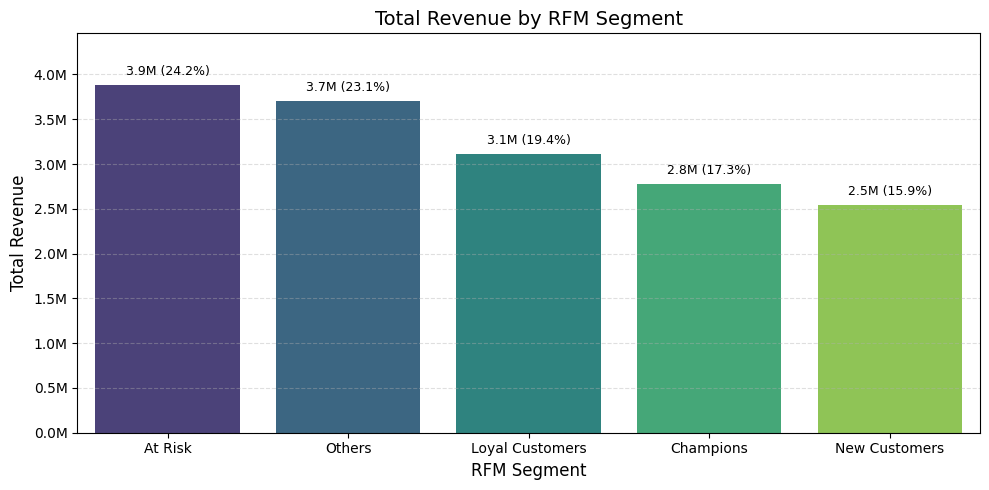

In [86]:
# Membuat bar plot untuk memvisualisasikan total pendapatan yang dihasilkan oleh setiap segmen RFM.
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=rfm_revenue_summary.index,
    y=rfm.groupby("Segment")["Monetary"].sum().loc[rfm_revenue_summary.index],
    palette="viridis", # Menggunakan palet warna 'viridis' untuk estetika visual.
    hue=rfm_revenue_summary.index, # Menggunakan 'Segment' sebagai hue untuk konsistensi visual.
    legend=False # Menyembunyikan legend karena sudah ada label langsung pada bar.
)

# Menambahkan judul dan label sumbu pada plot.
plt.title("Total Revenue by RFM Segment", fontsize=14)
plt.xlabel("RFM Segment", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

# Menyesuaikan batas y-axis untuk memberi ruang bagi label nilai dan persentase.
max_bar_height_revenue = rfm.groupby("Segment")["Monetary"].sum().max()
plt.gca().set_ylim(top=max_bar_height_revenue * 1.15) # Meningkatkan batas atas sebesar 15% dari tinggi maksimal bar.

# Memformat label Y-axis agar ditampilkan dalam jutaan (M).
plt.gca().yaxis.set_major_formatter(
    lambda x, _: f"{x/1_000_000:.1f}M"
)

# Menambahkan label nilai (dalam juta) dan persentase pangsa pendapatan di atas setiap bar.
for p in ax.patches:
    height = p.get_height()
    revenue_value = height / 1_000_000 # Mengonversi nilai pendapatan ke jutaan.

    # Mendapatkan nama segmen dari posisi bar untuk mengambil pangsa persentase yang sesuai.
    segment_label = rfm_revenue_summary.index[int(p.get_x() + 0.5)]
    percentage_share = rfm_revenue_summary.loc[segment_label, "Revenue Share (%)"]

    ax.annotate(
        f'{revenue_value:.1f}M ({percentage_share:.1f}%)',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
        textcoords='offset points'
    )

# Menambahkan grid horizontal untuk mempermudah pembacaan.
plt.grid(axis="y", linestyle="--", alpha=0.4)
# Menyesuaikan layout agar plot rapi dan tidak tumpang tindih.
plt.tight_layout()
plt.show()

Insight (Revenue per Segment):
-   Analisis pendapatan per segmen RFM menunjukkan bahwa segmen 'At Risk' menyumbang pendapatan terbesar (24.2%), diikuti oleh 'Others' (23.1%), 'Loyal Customers' (19.4%), 'Champions' (17.3%), dan 'New Customers' (15.9%). Visualisasi bar plot juga dengan jelas menunjukkan kontribusi pendapatan dari masing-masing segmen. Ini sangat penting karena menunjukkan bahwa pelanggan yang berisiko ('At Risk') masih merupakan sumber pendapatan yang signifikan, menekankan pentingnya strategi retensi untuk segmen ini.

In [87]:
# Menggabungkan DataFrame 'master_orders' dengan segmen RFM yang telah ditentukan untuk setiap pelanggan unik.
master_orders = master_orders.merge(
    rfm[["customer_unique_id", "Segment"]],
    on="customer_unique_id",
    how="left" # Menggunakan left join untuk mempertahankan semua pesanan di master_orders.
)

Insight (Menggabungkan Segmentasi RFM ke Master Orders):
-   Penggabungan segmen RFM ke dalam `master_orders` dengan `customer_unique_id` memungkinkan analisis lebih lanjut dari data pesanan dengan informasi segmentasi pelanggan. Ini adalah langkah krusial untuk mengintegrasikan hasil analisis RFM ke dalam dataset utama, memungkinkan kita untuk menganalisis perilaku pesanan (misalnya, produk yang dibeli, rata-rata nilai pesanan, atau skor ulasan) dalam konteks segmen pelanggan yang berbeda.

#### Analisis Metrik RFM Rata-Rata per Segmen

In [88]:
# Menghitung rata-rata nilai Recency, Frequency, dan Monetary untuk setiap segmen RFM
rfm_avg_metrics_readable = (
    rfm
    .groupby("Segment")[["Recency", "Frequency", "Monetary"]]  # Mengelompokkan data berdasarkan segmen RFM
    .mean()                                                     # Menghitung nilai rata-rata tiap metrik
    .round(2)                                                   # Membulatkan angka agar mudah dibaca
    .rename(columns={                                          # Mengganti nama kolom agar lebih informatif
        "Recency": "Avg Recency (days)",
        "Frequency": "Avg Frequency (orders)",
        "Monetary": "Avg Monetary Value"
    })
    .sort_values("Avg Recency (days)", ascending=True)         # Mengurutkan segmen dari pelanggan paling aktif
)

# Menampilkan tabel ringkasan RFM yang sudah rapi dan mudah dipahami
display(rfm_avg_metrics_readable)

,Avg Recency (days),Avg Frequency (orders),Avg Monetary Value
Segment,,,
Champions,140.28,1.10,179.49
New Customers,141.10,1.00,164.65
Loyal Customers,219.00,1.04,161.73
Others,389.23,1.00,161.06
At Risk,445.72,1.05,168.84


#### Visualisasi Karakteristik Segmen RFM


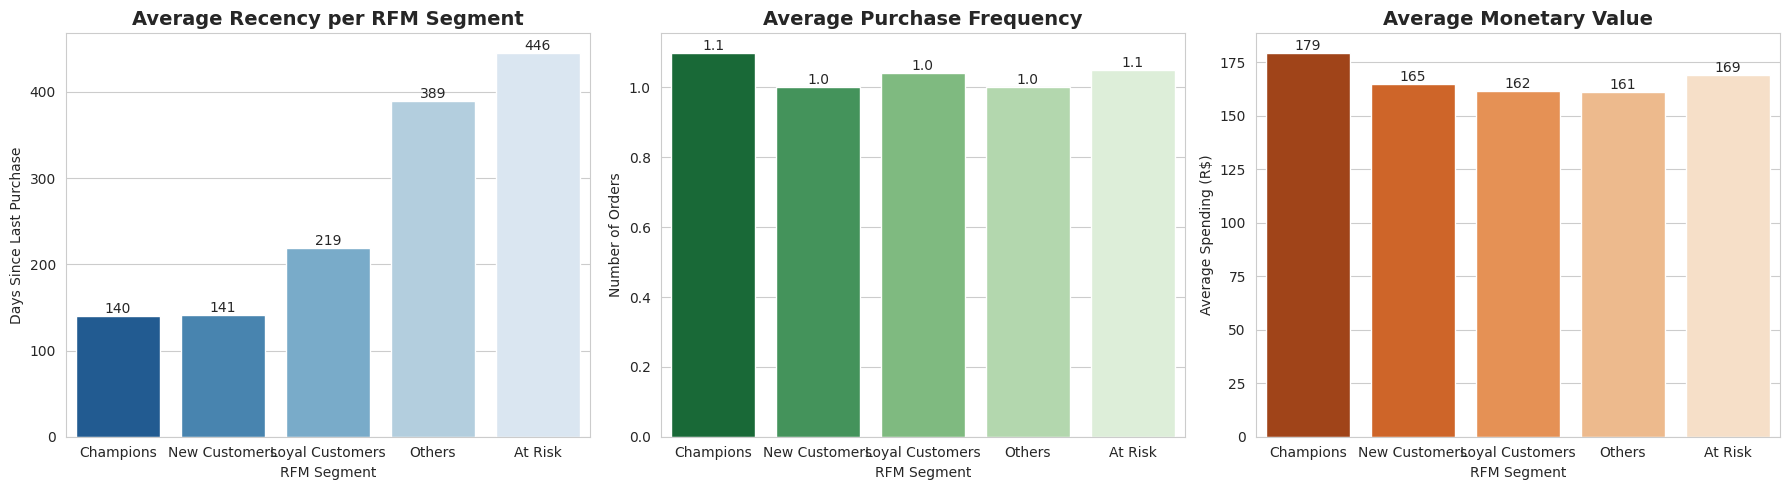

In [89]:
# Mengatur style visual agar lebih bersih dan mudah dibaca
sns.set_style("whitegrid")

# Membuat figure dengan 3 subplot horizontal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =========================
# 1️⃣ Average Recency
# =========================
sns.barplot(
    ax=axes[0],
    x=rfm_avg_metrics_readable.index,
    y=rfm_avg_metrics_readable["Avg Recency (days)"], # Corrected column name
    palette="Blues_r",
    hue=rfm_avg_metrics_readable.index, # Added to address FutureWarning
    legend=False # Added to address FutureWarning
)

axes[0].set_title("Average Recency per RFM Segment", fontsize=14, fontweight="bold")
axes[0].set_xlabel("RFM Segment")
axes[0].set_ylabel("Days Since Last Purchase")

# Menambahkan label nilai di atas bar
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.0f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=10
    )

# =========================
# 2️⃣ Average Frequency
# =========================
sns.barplot(
    ax=axes[1],
    x=rfm_avg_metrics_readable.index,
    y=rfm_avg_metrics_readable["Avg Frequency (orders)"], # Corrected column name
    palette="Greens_r",
    hue=rfm_avg_metrics_readable.index, # Added to address FutureWarning
    legend=False # Added to address FutureWarning
)

axes[1].set_title("Average Purchase Frequency", fontsize=14, fontweight="bold")
axes[1].set_xlabel("RFM Segment")
axes[1].set_ylabel("Number of Orders")

for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.1f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=10
    )

# =========================
# 3️⃣ Average Monetary
# =========================
sns.barplot(
    ax=axes[2],
    x=rfm_avg_metrics_readable.index,
    y=rfm_avg_metrics_readable["Avg Monetary Value"], # Corrected column name
    palette="Oranges_r",
    hue=rfm_avg_metrics_readable.index, # Added to address FutureWarning
    legend=False # Added to address FutureWarning
)

axes[2].set_title("Average Monetary Value", fontsize=14, fontweight="bold")
axes[2].set_xlabel("RFM Segment")
axes[2].set_ylabel("Average Spending (R$)")

for p in axes[2].patches:
    axes[2].annotate(
        f"{p.get_height():,.0f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=10
    )

# Menyesuaikan layout agar tidak saling bertabrakan
plt.tight_layout()
plt.show()

#### Eksplorasi Preferensi Produk berdasarkan Segmen RFM

In [90]:
# Menggabungkan data pesanan (master_orders) dengan detail produk (items_products)
# untuk menganalisis preferensi produk berdasarkan segmen RFM.
rfm_product_data = (
    master_orders
    .merge(
        items_products,
        on="order_id",
        how="inner"
    )
)

# Menampilkan ringkasan data hasil merge agar mudah dipahami
print(f"Jumlah baris dan kolom data hasil penggabungan: {rfm_product_data.shape[0]:,} baris, {rfm_product_data.shape[1]} kolom")

print("\nContoh 5 baris pertama data preferensi produk berdasarkan RFM:")
display(
    rfm_product_data
    .head()
    .style
    .format(thousands=",")
)

Jumlah baris dan kolom data hasil penggabungan: 112,650 baris, 38 kolom

Contoh 5 baris pertama data preferensi produk berdasarkan RFM:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_freight,total_items,unique_products,unique_sellers,payment_value,payment_installments,payment_types,review_score,Segment,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8.000000,7c396fd4830fd04220f754e42b4e5bff,"3,149",sao paulo,SP,29.990000,8.720000,1.000000,1.000000,1.000000,38.710000,1.000000,2.000000,4.000000,At Risk,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.990000,8.720000,utilidades_domesticas,40.000000,268.000000,4.000000,500.000000,19.000000,8.000000,13.000000,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13.000000,af07308b275d755c9edb36a90c618231,"47,813",barreiras,BA,118.700000,22.760000,1.000000,1.000000,1.000000,141.460000,1.000000,1.000000,4.000000,Champions,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.700000,22.760000,perfumaria,29.000000,178.000000,1.000000,400.000000,19.000000,13.000000,19.000000,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9.000000,3a653a41f6f9fc3d2a113cf8398680e8,"75,265",vianopolis,GO,159.900000,19.220000,1.000000,1.000000,1.000000,179.120000,3.000000,1.000000,5.000000,New Customers,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.900000,19.220000,automotivo,46.000000,232.000000,1.000000,420.000000,24.000000,19.000000,21.000000,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,13.000000,7c142cf63193a1473d2e66489a9ae977,"59,296",sao goncalo do amarante,RN,45.000000,27.200000,1.000000,1.000000,1.000000,72.200000,1.000000,1.000000,5.000000,At Risk,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.000000,27.200000,pet_shop,59.000000,468.000000,3.000000,450.000000,30.000000,10.000000,20.000000,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2.000000,72632f0f9dd73dfee390c9b22eb56dd6,"9,195",santo andre,SP,19.900000,8.720000,1.000000,1.000000,1.000000,28.620000,1.000000,1.000000,5.000000,Loyal Customers,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.900000,8.720000,papelaria,38.000000,316.000000,4.000000,250.000000,51.000000,15.000000,15.000000,stationery


In [91]:
# Menampilkan 10 kategori produk teratas untuk setiap segmen RFM
# beserta jumlah dan persentase kemunculannya


# --- Diagnostic: Check 'Segment' column in rfm before merge ---
if 'Segment' not in rfm.columns:
    print("WARNING: 'Segment' column not found in 'rfm' DataFrame. Please ensure cell DqcQDXNFC8Sj was executed successfully.")
    # Attempt to re-create Segment column in rfm for robustness
    # This part should ideally be in DqcQDXNFC8Sj or an earlier cell if it was an issue.
    # But since it's failing here, let's try a defensive measure.
    try:
        def rfm_segment_recheck(row):
            if row["R_score"] >= 4 and row["F_score"] >= 4:
                return "Champions"
            elif row["R_score"] >= 3 and row["F_score"] >= 3:
                return "Loyal Customers"
            elif row["R_score"] >= 4 and row["F_score"] <= 2:
                return "New Customers"
            elif row["R_score"] <= 2 and row["F_score"] >= 3:
                return "At Risk"
            else:
                return "Others"
        print("Re-creating 'Segment' column in rfm for robustness.")
        rfm["Segment"] = rfm.apply(rfm_segment_recheck, axis=1)
    except Exception as e:
        print(f"Error during re-creation of Segment in rfm: {e}")

# Explicitly merge the 'Segment' information from the 'rfm' DataFrame into rfm_product_data
# This ensures the 'Segment' column is present, even if previous merges were somehow inconsistent.
rfm_product_data = rfm_product_data.merge(
    rfm[['customer_unique_id', 'Segment']],
    on='customer_unique_id',
    how='left'
)

# Rename 'Segment_y' to 'Segment' after merge to correctly reference the RFM segment
# 'Segment_y' comes from the 'rfm' DataFrame in the last merge
rfm_product_data = rfm_product_data.rename(columns={'Segment_y': 'Segment'})

# --- Diagnostic: Print columns after merge ---
print(f"Columns in rfm_product_data after merge: {rfm_product_data.columns.tolist()}")

for segment in sorted(rfm_product_data["Segment"].dropna().unique()):
    print(f"\n📊 Top 10 Product Categories for {segment} Customers")

    # Memfilter data berdasarkan segmen RFM
    segment_data = rfm_product_data[
        rfm_product_data["Segment"] == segment
    ]

    # Menghitung jumlah dan persentase kategori produk
    category_summary = (
        segment_data["product_category_name_english"]
        .value_counts()
        .rename_axis("Product Category")
        .reset_index(name="Total Orders")
    )

    category_summary["Percentage (%)"] = (
        category_summary["Total Orders"]
        / category_summary["Total Orders"].sum() * 100
    ).round(2)

    # Menampilkan 10 kategori teratas dengan format yang rapi
    display(
        category_summary
        .head(10)
        .style
        .format({
            "Total Orders": "{:}",
            "Percentage (%)": "{:.2f}%"
        })
        .set_caption(f"Top 10 Product Categories – {segment} Segment")
    )


Columns in rfm_product_data after merge: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_time_days', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_price', 'total_freight', 'total_items', 'unique_products', 'unique_sellers', 'payment_value', 'payment_installments', 'payment_types', 'review_score', 'Segment_x', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'Segment']

📊 Top 10 Product Categories for At Risk Customers


,Product Category,Total Orders,Percentage (%)
0,bed_bath_table,2941,10.98%
1,furniture_decor,2346,8.76%
2,sports_leisure,2208,8.25%
3,health_beauty,2032,7.59%
4,computers_accessories,1726,6.45%
5,housewares,1634,6.10%
6,toys,1304,4.87%
7,cool_stuff,1260,4.71%
8,garden_tools,1232,4.60%
9,telephony,1133,4.23%



📊 Top 10 Product Categories for Champions Customers


,Product Category,Total Orders,Percentage (%)
0,health_beauty,1958,10.11%
1,bed_bath_table,1957,10.10%
2,housewares,1407,7.26%
3,sports_leisure,1393,7.19%
4,furniture_decor,1388,7.17%
5,computers_accessories,1317,6.80%
6,watches_gifts,1300,6.71%
7,auto,810,4.18%
8,telephony,696,3.59%
9,garden_tools,605,3.12%



📊 Top 10 Product Categories for Loyal Customers Customers


,Product Category,Total Orders,Percentage (%)
0,bed_bath_table,2194,9.88%
1,health_beauty,1963,8.84%
2,computers_accessories,1811,8.15%
3,sports_leisure,1733,7.80%
4,furniture_decor,1433,6.45%
5,housewares,1255,5.65%
6,watches_gifts,1235,5.56%
7,auto,951,4.28%
8,telephony,928,4.18%
9,electronics,825,3.71%



📊 Top 10 Product Categories for New Customers Customers


,Product Category,Total Orders,Percentage (%)
0,health_beauty,1802,10.40%
1,bed_bath_table,1591,9.19%
2,housewares,1297,7.49%
3,sports_leisure,1220,7.04%
4,computers_accessories,1183,6.83%
5,furniture_decor,1166,6.73%
6,watches_gifts,1127,6.51%
7,auto,813,4.69%
8,telephony,585,3.38%
9,baby,555,3.20%



📊 Top 10 Product Categories for Others Customers


,Product Category,Total Orders,Percentage (%)
0,bed_bath_table,2432,9.60%
1,sports_leisure,2087,8.24%
2,furniture_decor,2001,7.90%
3,health_beauty,1912,7.55%
4,computers_accessories,1790,7.06%
5,housewares,1371,5.41%
6,watches_gifts,1206,4.76%
7,telephony,1203,4.75%
8,garden_tools,1200,4.74%
9,toys,1140,4.50%


Insight (Preferensi Produk berdasarkan Segmen RFM):
- **Pelanggan Berisiko (At Risk Customers)**: Segmen ini menunjukkan preferensi yang kuat terhadap `bed_bath_table`, `furniture_decor`, `sports_leisure`, dan `health_beauty`. Karena pelanggan ini berada dalam kondisi 'berisiko', menargetkan mereka dengan promosi yang terkait dengan kategori-kategori ini dapat mendorong keterlibatan kembali.
- **Pelanggan Juara (Champions Customers)**: Ini adalah pelanggan paling bernilai dan mereka sering membeli dari kategori `health_beauty`, `bed_bath_table`, `housewares`, dan `sports_leisure`. Menjaga kualitas produk yang tinggi dan menawarkan penawaran eksklusif pada kategori-kategori ini dapat semakin memperkuat loyalitas mereka.
- **Pelanggan Baru (New Customers)**: Mirip dengan Pelanggan Juara, Pelanggan Baru juga menunjukkan minat tinggi pada `health_beauty`, `bed_bath_table`, dan `housewares`. Hal ini menunjukkan bahwa strategi keterlibatan awal dapat difokuskan pada jenis produk yang populer dan umumnya diterima dengan baik ini.
- **Pelanggan Loyal (Loyal Customers)**: Preferensi segmen ini cukup luas, dengan `bed_bath_table`, `health_beauty`, dan `computers_accessories` sebagai pilihan utama. Rekomendasi yang dipersonalisasi berdasarkan riwayat pembelian mereka dalam kategori-kategori ini dapat menjadi efektif.
- **Pelanggan Lainnya (Others Customers)**: Segmen umum ini juga memprioritaskan `bed_bath_table`, `sports_leisure`, dan `furniture_decor`. Upaya pemasaran umum dapat disesuaikan dengan kategori-kategori ini untuk menangkap minat yang lebih luas.
- **Observasi Keseluruhan**: Kategori seperti `bed_bath_table`, `health_beauty`, `furniture_decor`, dan `sports_leisure` muncul secara konsisten di hampir semua segmen teratas, yang menunjukkan daya tarik universal dan pentingnya kategori-kategori tersebut bagi platform e-commerce. `computers_accessories` dan `housewares` juga merupakan kategori yang kuat.

Analisis ini memberikan wawasan yang dapat ditindaklanjuti untuk pemasaran yang lebih tertarget, manajemen inventaris, dan pengembangan produk berdasarkan segmentasi pelanggan.


#### Analisis Distribusi Geografis Segmen RFM

In [92]:
# Ensure 'Segment' column is in master_orders for analysis
if 'Segment' not in master_orders.columns:
    master_orders = master_orders.merge(
        rfm[['customer_unique_id', 'Segment']],
        on='customer_unique_id',
        how='left'
    )

# Menghitung jumlah pelanggan unik berdasarkan kombinasi negara bagian dan segmen RFM
customer_geo_segment = (
    master_orders
    .groupby(["customer_state", "Segment"])["customer_unique_id"]
    .nunique()
    .reset_index(name="Total Customers")
)

# Mengurutkan agar negara bagian dengan jumlah pelanggan terbesar muncul di atas
customer_geo_segment = customer_geo_segment.sort_values(
    "Total Customers", ascending=False
)

print("📍 Distribusi Pelanggan berdasarkan Negara Bagian dan Segmen RFM")
display(
    customer_geo_segment
    .head(10)
    .style
    .format({"Total Customers": "{:,}"})
    .set_caption("Top 10 Distribusi Pelanggan per Negara Bagian & Segmen RFM")
)

📍 Distribusi Pelanggan berdasarkan Negara Bagian dan Segmen RFM


,customer_state,Segment,Total Customers
129,SP,Others,"9,159"
125,SP,At Risk,"8,880"
127,SP,Loyal Customers,"8,227"
128,SP,New Customers,"7,059"
126,SP,Champions,"6,976"
90,RJ,At Risk,"3,176"
94,RJ,Others,"3,092"
50,MG,At Risk,"2,785"
54,MG,Others,"2,713"
92,RJ,Loyal Customers,"2,463"


In [93]:
# Menghitung total pelanggan unik di setiap negara bagian
total_customers_per_state = (
    master_orders
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .reset_index(name="Total Customers in State")
)

# Menggabungkan total pelanggan per negara bagian ke data segmentasi geografis
customer_geo_segment_readable = (
    customer_geo_segment
    .merge(
        total_customers_per_state,
        on="customer_state",
        how="left"
    )
)

# Menghitung persentase setiap segmen RFM dalam suatu negara bagian
customer_geo_segment_readable["Segment Percentage (%)"] = (
    customer_geo_segment_readable["Total Customers"]
    / customer_geo_segment_readable["Total Customers in State"]
    * 100
).round(2)

# Mengurutkan agar kombinasi dengan proporsi terbesar muncul di atas
customer_geo_segment_readable = customer_geo_segment_readable.sort_values(
    ["customer_state", "Segment Percentage (%)"],
    ascending=[True, False]
)

print("📍 Distribusi Segmen RFM per Negara Bagian (dalam Persentase)")
display(
    customer_geo_segment_readable
    .head(10)
    .style
    .format({
        "Total Customers": "{:,.0f}",
        "Total Customers in State": "{:,.0f}",
        "Segment Percentage (%)": "{:.2f}%"
    })
    .set_caption("Top Distribusi Segmen RFM berdasarkan Negara Bagian")
)


📍 Distribusi Segmen RFM per Negara Bagian (dalam Persentase)


,customer_state,Segment,Total Customers,Total Customers in State,Segment Percentage (%)
116,AC,Others,30,77,38.96%
120,AC,At Risk,25,77,32.47%
129,AC,New Customers,8,77,10.39%
130,AC,Loyal Customers,7,77,9.09%
131,AC,Champions,7,77,9.09%
78,AL,At Risk,123,401,30.67%
90,AL,Others,93,401,23.19%
95,AL,Loyal Customers,75,401,18.70%
103,AL,Champions,57,401,14.21%
107,AL,New Customers,53,401,13.22%


In [94]:
# Menampilkan 5 negara bagian dengan jumlah pelanggan terbanyak
# untuk setiap segmen RFM
for segment_name in sorted(customer_geo_segment["Segment"].unique()):
    print(f"\n📍 Top 5 States with Highest Number of {segment_name} Customers")

    top_states = (
        customer_geo_segment[
            customer_geo_segment["Segment"] == segment_name
        ]
        .sort_values("Total Customers", ascending=False)  # Corrected column name
        .head(5)
        .rename(columns={
            "customer_state": "State",
            # Removed redundant rename for "Total Customers"
        })
    )

    # Menampilkan tabel dengan format yang rapi
    display(
        top_states
        .style
        .format({
            "Total Customers": "{:,}"
        })
        .set_caption(f"Top 5 States by Customer Count – {segment_name} Segment")
    )


📍 Top 5 States with Highest Number of At Risk Customers


,State,Segment,Total Customers
125,SP,At Risk,"8,880"
90,RJ,At Risk,"3,176"
50,MG,At Risk,"2,785"
110,RS,At Risk,"1,364"
85,PR,At Risk,"1,147"



📍 Top 5 States with Highest Number of Champions Customers


,State,Segment,Total Customers
126,SP,Champions,"6,976"
91,RJ,Champions,"1,865"
51,MG,Champions,"1,803"
86,PR,Champions,809
111,RS,Champions,793



📍 Top 5 States with Highest Number of Loyal Customers Customers


,State,Segment,Total Customers
127,SP,Loyal Customers,"8,227"
92,RJ,Loyal Customers,"2,463"
52,MG,Loyal Customers,"2,237"
112,RS,Loyal Customers,983
87,PR,Loyal Customers,956



📍 Top 5 States with Highest Number of New Customers Customers


,State,Segment,Total Customers
128,SP,New Customers,"7,059"
93,RJ,New Customers,"1,788"
53,MG,New Customers,"1,721"
113,RS,New Customers,787
88,PR,New Customers,762



📍 Top 5 States with Highest Number of Others Customers


,State,Segment,Total Customers
129,SP,Others,"9,159"
94,RJ,Others,"3,092"
54,MG,Others,"2,713"
114,RS,Others,"1,350"
89,PR,Others,"1,208"


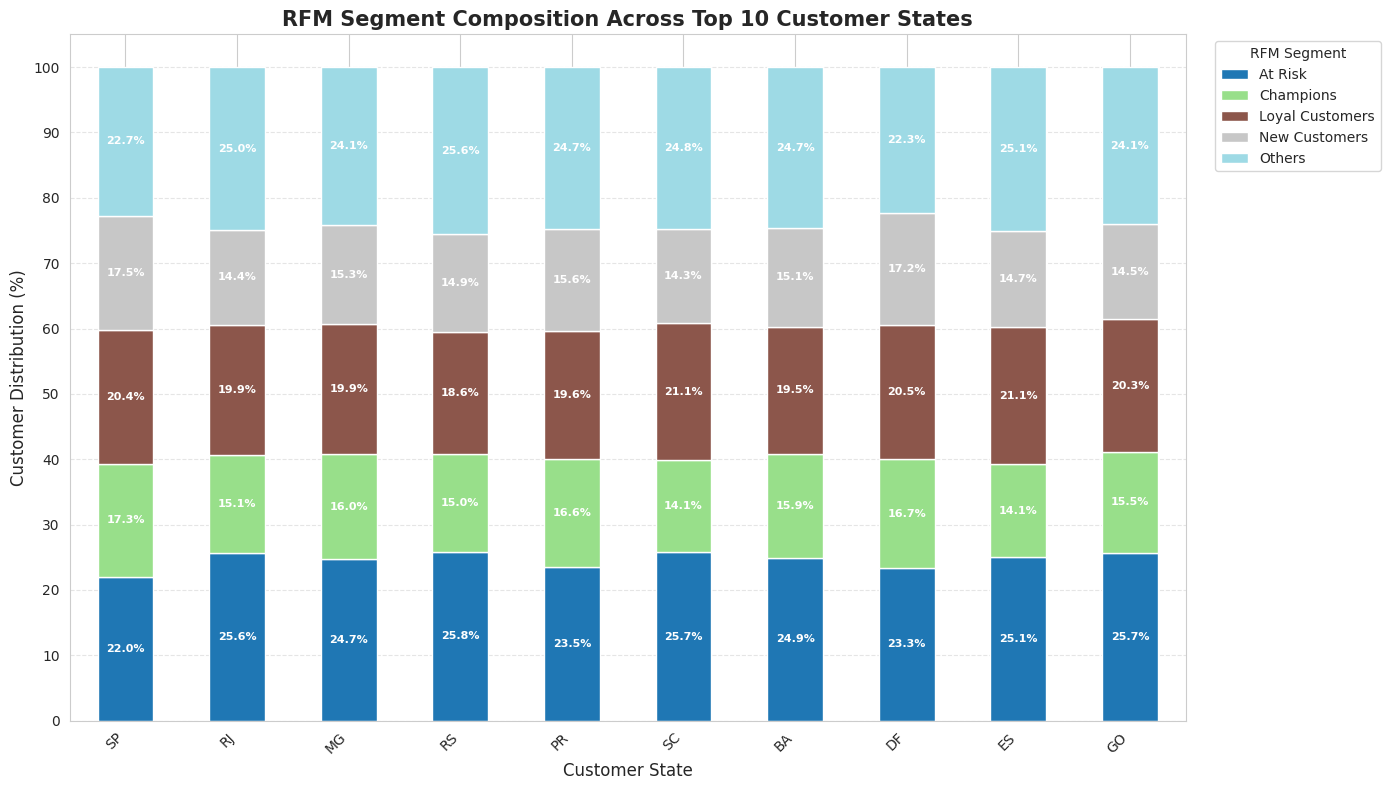

In [95]:
# ================================
# Visualisasi distribusi Segmen RFM
# pada 10 negara bagian dengan pelanggan terbanyak
# ================================

# Menentukan 10 negara bagian dengan total pelanggan terbanyak
top_10_states = (
    total_customers_per_state
    .sort_values("Total Customers in State", ascending=False)
    .head(10)["customer_state"]
)

# Memfilter data hanya untuk 10 negara bagian teratas
top_states_segment_dist = customer_geo_segment[
    customer_geo_segment["customer_state"].isin(top_10_states)
]

# Membuat pivot tabel: baris = state, kolom = segmen, nilai = jumlah pelanggan
pivoted_data = (
    top_states_segment_dist
    .pivot_table(
        index="customer_state",
        columns="Segment",
        values="Total Customers", # Using 'Total Customers' from customer_geo_segment
        fill_value=0
    )
    .loc[top_10_states]  # Menjaga urutan state
)

# Mengonversi jumlah menjadi persentase agar mudah dibandingkan antar state
pivoted_data_percent = pivoted_data.div(
    pivoted_data.sum(axis=1), axis=0
) * 100

# Membuat figure dan stacked bar chart
plt.figure(figsize=(14, 8))
ax = pivoted_data_percent.plot(
    kind="bar",
    stacked=True,
    colormap="tab20",
    edgecolor="white",
    ax=plt.gca() # Menggunakan ax=plt.gca() untuk plot DataFrame pada figure saat ini
)

# Pengaturan judul dan label agar komunikatif
plt.title(
    "RFM Segment Composition Across Top 10 Customer States",
    fontsize=15,
    weight="bold"
)
plt.xlabel("Customer State", fontsize=12)
plt.ylabel("Customer Distribution (%)", fontsize=12)

# Memperjelas sumbu dan grid
plt.xticks(rotation=45, ha="right")
plt.yticks(range(0, 101, 10))
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Legenda dipindahkan agar tidak menutupi grafik
plt.legend(
    title="RFM Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# ===============================
# TAMBAHAN: LABEL PERSENTASE
# ===============================

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 3:  # hanya tampilkan jika >3% agar tidak terlalu padat
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{height:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white",
                weight="bold"
            )

plt.tight_layout()
plt.show()

Insight (Distribusi Geografis Segmen RFM):
- **Dominasi Sao Paulo (SP)**: Sao Paulo secara konsisten muncul sebagai negara bagian dengan jumlah pelanggan tertinggi di seluruh segmen RFM. Hal ini menunjukkan bahwa wilayah ini merupakan pasar utama bagi platform e-commerce dan area yang sangat penting untuk semua strategi keterlibatan pelanggan.
- **Proporsi Segmen yang Konsisten di Negara Bagian Teratas**: Untuk sebagian besar negara bagian teratas, distribusi segmen RFM (misalnya, Pelanggan Berisiko, Pelanggan Juara, Pelanggan Loyal, Pelanggan Baru, dan Lainnya) tampak relatif konsisten dalam hal proporsi. Hal ini mengindikasikan bahwa pola perilaku pelanggan, sebagaimana ditangkap oleh RFM, relatif serupa di berbagai wilayah geografis utama.
- **Peluang untuk Kampanye Regional yang Tertarget**: Meskipun proporsinya secara umum konsisten, perbedaan kecil dapat dimanfaatkan untuk kampanye yang lebih tertarget. Sebagai contoh, jika suatu negara bagian memiliki proporsi 'Pelanggan Baru' yang sedikit lebih tinggi, upaya di wilayah tersebut dapat difokuskan pada proses onboarding dan mendorong pembelian berulang. Sebaliknya, negara bagian dengan proporsi 'Pelanggan Berisiko' yang lebih tinggi mungkin akan lebih diuntungkan dari kampanye re-engagement.
- **Peningkatan Logistik dan Layanan**: Memahami sebaran geografis pelanggan 'Pelanggan Berisiko' dapat membantu mengidentifikasi wilayah di mana masalah pengiriman (misalnya, `delivery_time_days` yang lebih lama) atau kekhawatiran terkait kualitas produk mungkin lebih sering terjadi, sehingga mendorong perbaikan lokal dalam logistik atau manajemen penjual.
- **Strategi Skalabilitas**: Distribusi yang konsisten di negara bagian utama menunjukkan bahwa strategi berbasis RFM yang berhasil di satu negara bagian besar (seperti SP) berpotensi untuk direplikasi, dengan penyesuaian kecil, di negara bagian besar lainnya seperti RJ, MG, dan RS.


#### Visualisasi Choropleth Map untuk Distribusi Geografis Segmen RFM

##### Memuat Data Geografis (GeoJSON)

**Penting**: Pastikan Anda telah mengunggah file GeoJSON (misalnya, `brazil_states.geojson`) ke lingkungan Colab Anda atau menyediakan path yang benar ke file tersebut. File ini berisi batas geografis untuk setiap negara bagian di Brasil.

In [96]:
# Path lokal untuk file GeoJSON yang akan digunakan atau diunduh
geojso_local_path = 'brazil-states.geojson'

# URL publik untuk file GeoJSON negara bagian Brasil
geojso_url_source = 'https://raw.githubusercontent.com/codeforgermany/click_that_hood/48ba05ad4c6969e3b3c25735492169227ae411f1/public/data/brazil-states.geojson'

# Memeriksa apakah file GeoJSON sudah ada secara lokal dan berukuran memadai
# (Sebagai heuristic, GeoJSON untuk state tidak mungkin kurang dari 1KB)
if not os.path.exists(geojso_local_path) or os.path.getsize(geojso_local_path) < 1024:
    print(f"File '{geojso_local_path}' tidak ditemukan atau ukurannya mencurigakan. Mencoba mengunduh dari URL: {geojso_url_source}")
    try:
        response = requests.get(geojso_url_source)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(geojso_local_path, 'wb') as f:
            f.write(response.content)
        print(f"File GeoJSON berhasil diunduh dan disimpan ke '{geojso_local_path}'.")
    except requests.exceptions.RequestException as e:
        print(f"Terjadi kesalahan saat mengunduh GeoJSON dari URL: {e}")
        print("Pastikan koneksi internet Anda stabil dan URL GeoJSON valid.")
        raise # Re-raise to stop execution if download fails

try:
    # Memuat data geografis
    brazil_states_gdf = gpd.read_file(geojso_local_path)
    print("Data GeoJSON berhasil dimuat.")
    display(brazil_states_gdf.head())
except Exception as e:
    print(f"Terjadi kesalahan saat memuat GeoJSON dari '{geojso_local_path}': {e}")
    print("Pastikan file GeoJSON yang diunduh valid dan tidak rusak.")

File 'brazil-states.geojson' tidak ditemukan atau ukurannya mencurigakan. Mencoba mengunduh dari URL: https://raw.githubusercontent.com/codeforgermany/click_that_hood/48ba05ad4c6969e3b3c25735492169227ae411f1/public/data/brazil-states.geojson
File GeoJSON berhasil diunduh dan disimpan ke 'brazil-states.geojson'.
Data GeoJSON berhasil dimuat.


,id,name,sigla,regiao_id,codigo_ibg,cartodb_id,created_at,updated_at,geometry
0,1,Acre,AC,3,12,1,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-73.60818 -7.20194, -72.86963 ..."
1,2,Alagoas,AL,4,27,2,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-35.46516 -8.82549, -35.46626 ..."
2,3,Amazonas,AM,3,13,3,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-67.32553 2.03012, -67.32234 2..."
3,4,Amapá,AP,3,16,4,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-51.18168 4.00889, -51.179 3.9..."
4,5,Bahia,BA,4,29,5,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-39.2882 -8.5629, -39.28229 -8..."


##### Mempersiapkan Data RFM untuk Visualisasi Peta

Kita akan menggunakan DataFrame `customer_geo_segment_readable` yang telah Anda buat sebelumnya. Kita perlu memastikan nama kolom negara bagian cocok antara data geografis dan data RFM. File GeoJSON biasanya menggunakan singkatan negara bagian atau nama lengkap dalam bahasa Portugis. Anda mungkin perlu melakukan *mapping* jika nama tidak cocok.

In [97]:
# Menghitung total pelanggan unik di setiap negara bagian
total_customers_per_state = (
    master_orders
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .reset_index(name="Total Customers in State")
)

# Menggabungkan total pelanggan per negara bagian ke data segmentasi geografis
customer_geo_segment_readable = (
    customer_geo_segment
    .merge(
        total_customers_per_state,
        on="customer_state",
        how="left"
    )
)

# Menghitung persentase setiap segmen RFM dalam suatu negara bagian
customer_geo_segment_readable["Segment Percentage (%)"] = (
    customer_geo_segment_readable["Total Customers"]
    / customer_geo_segment_readable["Total Customers in State"]
    * 100
).round(2)

# Mengurutkan agar kombinasi dengan proporsi terbesar muncul di atas
customer_geo_segment_readable = customer_geo_segment_readable.sort_values(
    ["customer_state", "Segment Percentage (%)"],
    ascending=[True, False]
)


# Contoh: Memilih segmen 'Champions' untuk divisualisasikan
selected_segment = 'Champions'

# Filter data RFM untuk segmen yang dipilih
segment_data_for_map = customer_geo_segment_readable[
    customer_geo_segment_readable['Segment'] == selected_segment
].copy()

# Memastikan nama kolom negara bagian cocok (sesuaikan jika diperlukan)
# Misalnya, jika GeoJSON menggunakan 'sigla' (singkatan) dan data Anda 'customer_state'
# Anda mungkin perlu menyesuaikan nama kolom atau melakukan mapping.
# Contoh: Mengganti nama kolom 'customer_state' menjadi 'sigla_uf' jika GeoJSON memiliki kolom 'sigla_uf'
# brazil_states_gdf = brazil_states_gdf.rename(columns={'sigla_uf': 'customer_state'}) # Lakukan jika nama kolom di GeoJSON berbeda

# Rename 'customer_state' to 'sigla' to match a common GeoJSON column name for state abbreviations
segment_data_for_map = segment_data_for_map.rename(columns={'customer_state': 'sigla'})

# Menggabungkan data geografis dengan data RFM segmen yang dipilih
# Asumsi 'sigla' adalah kolom singkatan negara bagian di GeoJSON
merged_map_data = brazil_states_gdf.merge(
    segment_data_for_map,
    on='sigla',
    how='left'
)

# Mengisi NaN (negara bagian tanpa data) dengan 0 untuk visualisasi
merged_map_data['Segment Percentage (%)'] = merged_map_data['Segment Percentage (%)'].fillna(0)

print(f"Data gabungan untuk visualisasi segmen {selected_segment}:")
display(merged_map_data.head())

Data gabungan untuk visualisasi segmen Champions:


,id,name,sigla,regiao_id,codigo_ibg,cartodb_id,created_at,updated_at,geometry,Segment,Total Customers,Total Customers in State,Segment Percentage (%)
0,1,Acre,AC,3,12,1,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-73.60818 -7.20194, -72.86963 ...",Champions,7,77,9.09
1,2,Alagoas,AL,4,27,2,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-35.46516 -8.82549, -35.46626 ...",Champions,57,401,14.21
2,3,Amazonas,AM,3,13,3,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-67.32553 2.03012, -67.32234 2...",Champions,15,143,10.49
3,4,Amapá,AP,3,16,4,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-51.18168 4.00889, -51.179 3.9...",Champions,12,67,17.91
4,5,Bahia,BA,4,29,5,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-39.2882 -8.5629, -39.28229 -8...",Champions,521,3277,15.90


##### Create Choropleth Map Generator Class

In [98]:
class ChoroplethMapGenerator:
    """
    Class untuk menghasilkan peta choropleth distribusi segmen RFM
    serta menyoroti Top-N wilayah dengan persentase tertinggi.
    """

    def __init__(
        self,
        geo_df,
        segment_name,
        value_column='Segment Percentage (%)',
        region_column='sigla',
        cmap='Blues',
        top_n=5
    ):
        # Inisialisasi parameter utama untuk peta
        self.geo_df = geo_df
        self.segment_name = segment_name
        self.value_column = value_column
        self.region_column = region_column
        self.cmap = cmap
        self.top_n = top_n

    def _validate_data(self):
        # Memastikan kolom yang dibutuhkan tersedia dalam dataset geospasial
        required_cols = [self.value_column, self.region_column, 'geometry']
        missing_cols = [col for col in required_cols if col not in self.geo_df.columns]

        if missing_cols:
            raise ValueError(f"Kolom berikut tidak ditemukan: {missing_cols}")

    def _get_top_regions(self):
        # Mengambil Top-N wilayah dengan nilai tertinggi (selain nol)
        return (
            self.geo_df[self.geo_df[self.value_column] > 0]
            .sort_values(self.value_column, ascending=False)
            .head(self.top_n)
        )

    def generate_map(self, figsize=(12, 9)):
        # Memvalidasi data sebelum membuat visualisasi
        self._validate_data()

        # Membuat figure dan axis untuk peta
        fig, ax = plt.subplots(figsize=figsize)

        # Membuat peta choropleth berdasarkan kolom nilai persentase
        self.geo_df.plot(
            column=self.value_column,
            cmap=self.cmap,
            linewidth=0.8,
            ax=ax,
            edgecolor='0.8',
            legend=True,
            legend_kwds={
                'label': f'{self.segment_name} Customers (%)',
                'shrink': 0.6,
                'format': mticker.FuncFormatter(lambda x, _: f'{x:.1f}%')
            }
        )

        # Mengambil wilayah dengan nilai tertinggi untuk diberi highlight
        top_regions = self._get_top_regions()

        for _, row in top_regions.iterrows():
            # Mengambil titik centroid dari setiap wilayah
            centroid = row.geometry.centroid

            # Menambahkan marker pada centroid wilayah
            ax.scatter(
                centroid.x,
                centroid.y,
                color='lightcyan',
                s=17,
                zorder=5
            )

            # Menambahkan anotasi kode wilayah dan persentase
            ax.annotate(
                f"{row[self.region_column]}\n{row[self.value_column]:.1f}%",
                xy=(centroid.x, centroid.y),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=7,
                weight='bold',
                color='lightcyan'
            )

        # Menambahkan judul pada peta
        ax.set_title(
            f'Top {self.top_n} Distribusi Pelanggan Segmen {self.segment_name}',
            fontsize=15,
            weight='bold',
            pad=12
        )

        # Menghilangkan sumbu agar tampilan peta lebih bersih
        ax.axis('off')

        # Menampilkan peta
        plt.show()


##### Visualisasi Choropleth Map untuk Segmen 'Champions'



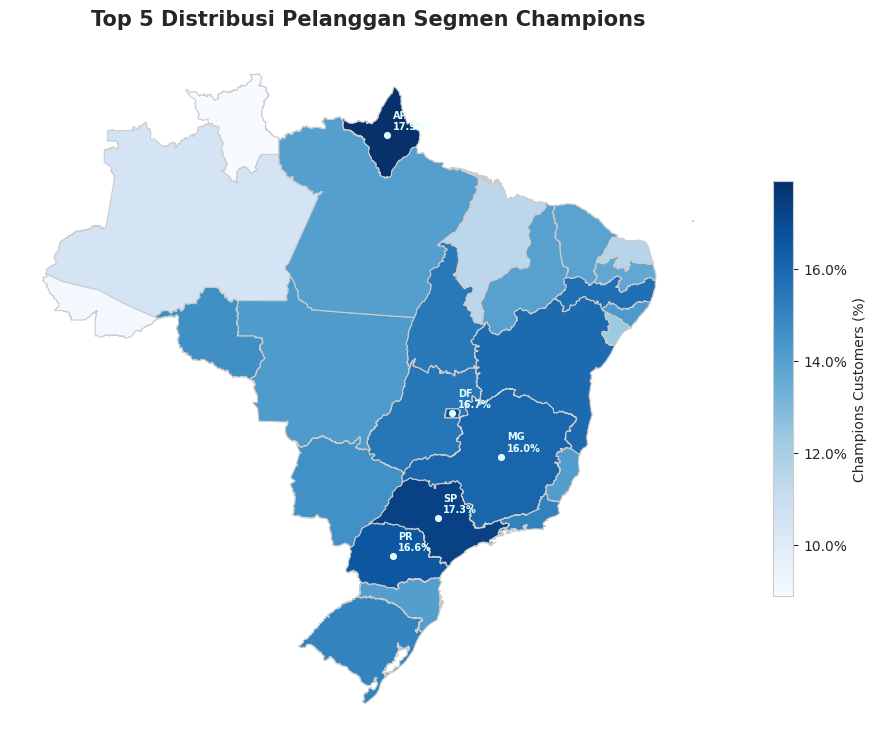

In [99]:
selected_segment = 'Champions'

# Filter data RFM untuk segmen yang dipilih
segment_data_for_map = customer_geo_segment_readable[
    customer_geo_segment_readable['Segment'] == selected_segment
].copy()

# Rename 'customer_state' to 'sigla' to match GeoJSON column name for state abbreviations
segment_data_for_map = segment_data_for_map.rename(columns={'customer_state': 'sigla'})

# Menggabungkan data geografis dengan data RFM segmen yang dipilih
merged_map_data = brazil_states_gdf.merge(
    segment_data_for_map,
    on='sigla',
    how='left'
)

# Mengisi NaN (negara bagian tanpa data) dengan 0 untuk visualisasi
merged_map_data['Segment Percentage (%)'] = merged_map_data['Segment Percentage (%)'].fillna(0)

# Instantiate and generate the map for the current segment
map_generator = ChoroplethMapGenerator(merged_map_data, selected_segment, top_n=5)
map_generator.generate_map()

Insight:


*   **Dominasi Wilayah Tenggara (Southeast Region)**: Choropleth map untuk segmen 'Champions' dengan jelas menunjukkan konsentrasi tertinggi pelanggan 'Champions' di wilayah Tenggara Brasil, khususnya negara bagian **Sao Paulo (SP)** dan **Rio de Janeiro (RJ)**. Kedua negara bagian ini memiliki persentase pelanggan 'Champions' yang signifikan dibandingkan dengan negara bagian lain.
*   **Kepentingan Sao Paulo (SP)**: Sao Paulo (SP) tidak hanya memiliki jumlah pelanggan keseluruhan terbesar, tetapi juga menunjukkan proporsi 'Champions' yang tinggi, menegaskan posisinya sebagai pasar utama untuk pelanggan bernilai tinggi dan paling aktif.
*   **Pola Geografis Konsisten**: Pola distribusi ini konsisten dengan temuan sebelumnya yang menunjukkan Sao Paulo sebagai pusat utama bagi seluruh segmen pelanggan. Ini mengindikasikan bahwa faktor-faktor seperti infrastruktur logistik yang lebih baik, kepadatan populasi, atau daya beli yang lebih tinggi di wilayah-wilayah ini berperan dalam menghasilkan dan mempertahankan 'Champions' customers.



##### Visualisasi Choropleth Map untuk Segmen 'New Customers'

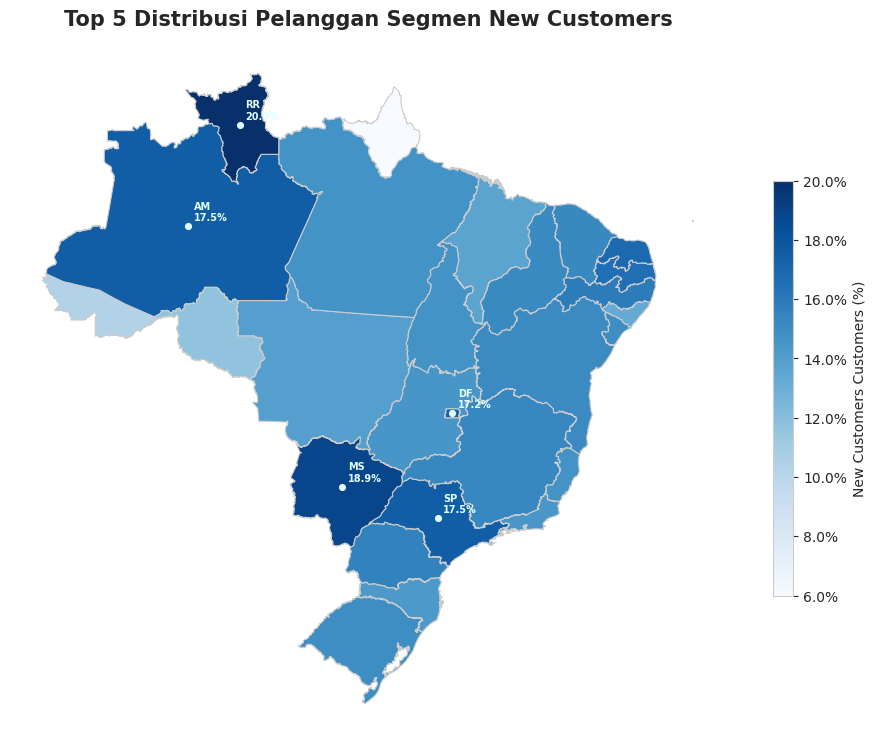

In [100]:
selected_segment = 'New Customers'

# Filter data RFM untuk segmen yang dipilih
segment_data_for_map = customer_geo_segment_readable[
    customer_geo_segment_readable['Segment'] == selected_segment
].copy()

# Rename 'customer_state' to 'sigla' to match GeoJSON column name for state abbreviations
segment_data_for_map = segment_data_for_map.rename(columns={'customer_state': 'sigla'})

# Menggabungkan data geografis dengan data RFM segmen yang dipilih
merged_map_data = brazil_states_gdf.merge(
    segment_data_for_map,
    on='sigla',
    how='left'
)

# Mengisi NaN (negara bagian tanpa data) dengan 0 untuk visualisasi
merged_map_data['Segment Percentage (%)'] = merged_map_data['Segment Percentage (%)'].fillna(0)

# Instantiate and generate the map for the current segment
map_generator = ChoroplethMapGenerator(merged_map_data, selected_segment, top_n=5)
map_generator.generate_map()

**Insight**:

-   **Konsentrasi Tinggi di Wilayah Metropolitan:** Wilayah-wilayah padat penduduk dan kota-kota besar, seperti Sao Paulo (SP), Rio de Janeiro (RJ), dan Minas Gerais (MG), menunjukkan persentase `New Customers` yang lebih tinggi. Hal ini mengindikasikan bahwa pelanggan baru cenderung berasal dari pusat-pusat ekonomi utama, di mana akses ke e-commerce mungkin lebih mudah dan penetrasi pasar lebih tinggi.
-   **Pola Distribusi Serupa dengan Total Pelanggan:** Distribusi geografis `New Customers` secara umum mencerminkan distribusi total basis pelanggan. Ini menunjukkan bahwa meskipun mereka baru, pola akuisisi pelanggan baru tidak secara signifikan berbeda dari distribusi pelanggan yang sudah ada.


##### Visualisasi Choropleth Map untuk Segmen 'Loyal Customers'

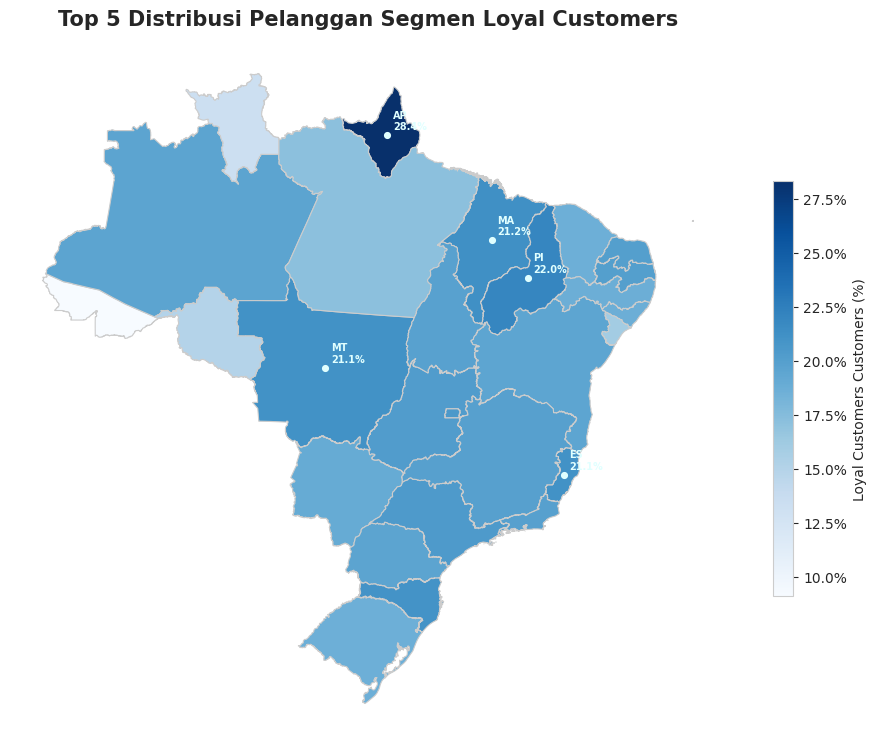

In [101]:
selected_segment = 'Loyal Customers'

# Filter data RFM untuk segmen yang dipilih
segment_data_for_map = customer_geo_segment_readable[
    customer_geo_segment_readable['Segment'] == selected_segment
].copy()

# Rename 'customer_state' to 'sigla' to match GeoJSON column name for state abbreviations
segment_data_for_map = segment_data_for_map.rename(columns={'customer_state': 'sigla'})

# Menggabungkan data geografis dengan data RFM segmen yang dipilih
merged_map_data = brazil_states_gdf.merge(
    segment_data_for_map,
    on='sigla',
    how='left'
)

# Mengisi NaN (negara bagian tanpa data) dengan 0 untuk visualisasi
merged_map_data['Segment Percentage (%)'] = merged_map_data['Segment Percentage (%)'].fillna(0)

# Instantiate and generate the map for the current segment
map_generator = ChoroplethMapGenerator(merged_map_data, selected_segment, top_n=5)
map_generator.generate_map()

**Insight**:
-   **Konsentrasi Tinggi di Wilayah Metropolitan:** Mirip dengan segmen lainnya, 'Loyal Customers' menunjukkan konsentrasi tertinggi di negara bagian São Paulo (SP), Rio de Janeiro (RJ), dan Minas Gerais (MG). Ini mengindikasikan bahwa wilayah-wilayah ini, yang merupakan pusat ekonomi dan populasi Brasil, adalah basis utama bagi pelanggan setia.
-   **Pola Distribusi yang Konsisten:** Distribusi 'Loyal Customers' cenderung mencerminkan pola distribusi pelanggan secara keseluruhan. Negara bagian dengan populasi dan aktivitas ekonomi yang lebih besar secara otomatis akan memiliki jumlah pelanggan yang lebih tinggi di semua segmen, termasuk pelanggan setia.
-   **Relevansi untuk Pemasaran Regional:** Meskipun pelanggan ini loyal, mereka memiliki skor ulasan rata-rata yang lebih rendah dibandingkan 'Champions' atau 'New Customers'. Visualisasi geografis ini membantu dalam mengidentifikasi wilayah mana yang memerlukan perhatian lebih untuk meningkatkan pengalaman pelanggan loyal mereka. Misalnya, jika ada anomali dalam kualitas layanan atau pengiriman di suatu negara bagian tertentu, hal ini akan lebih mudah diidentifikasi dan ditargetkan.
-   **Peluang Retensi dan Engagement:** Mengidentifikasi konsentrasi geografis pelanggan loyal memungkinkan kampanye retensi dan program *engagement* yang lebih terfokus secara regional. Misalnya, acara khusus pelanggan, promosi yang disesuaikan dengan preferensi regional, atau peningkatan layanan pengiriman di area tersebut dapat diterapkan.

##### Visualisasi Choropleth Map untuk Segmen 'At Risk'

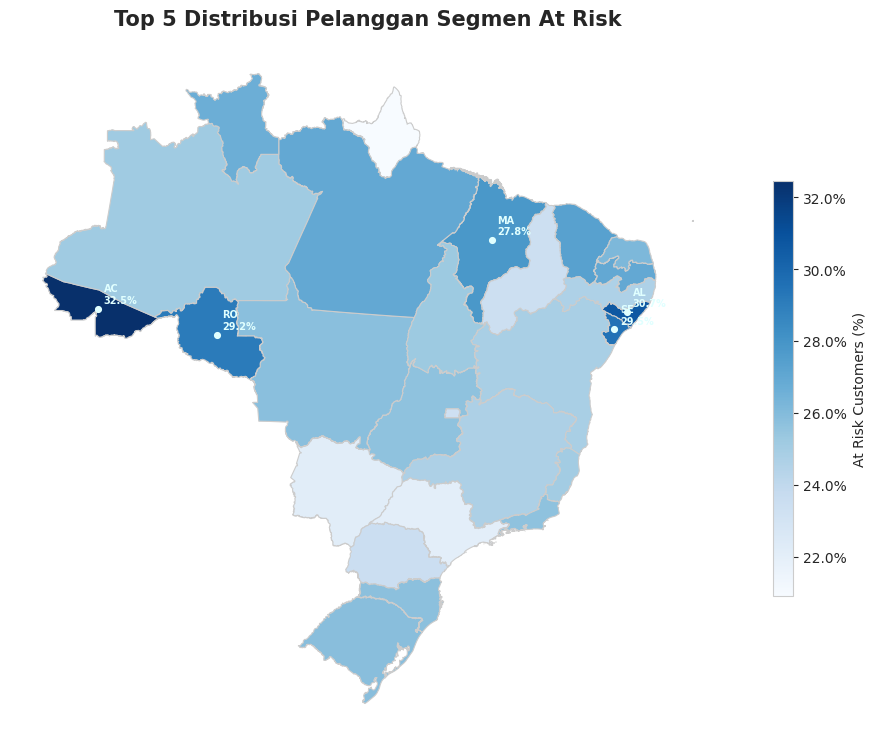

In [102]:
selected_segment = 'At Risk'

# Filter data RFM untuk segmen yang dipilih
segment_data_for_map = customer_geo_segment_readable[
    customer_geo_segment_readable['Segment'] == selected_segment
].copy()

# Rename 'customer_state' to 'sigla' to match GeoJSON column name for state abbreviations
segment_data_for_map = segment_data_for_map.rename(columns={'customer_state': 'sigla'})

# Menggabungkan data geografis dengan data RFM segmen yang dipilih
merged_map_data = brazil_states_gdf.merge(
    segment_data_for_map,
    on='sigla',
    how='left'
)

# Mengisi NaN (negara bagian tanpa data) dengan 0 untuk visualisasi
merged_map_data['Segment Percentage (%)'] = merged_map_data['Segment Percentage (%)'].fillna(0)

# Instantiate and generate the map for the current segment
map_generator = ChoroplethMapGenerator(merged_map_data, selected_segment, top_n=5)
map_generator.generate_map()

**Insight**:

Visualisasi choropleth map untuk segmen 'At Risk' menunjukkan konsentrasi pelanggan berisiko di beberapa negara bagian utama, yang mengindikasikan prioritas geografis untuk strategi retensi.

-   **Dominasi Sao Paulo (SP)**: Seperti segmen lainnya, Sao Paulo (SP) menunjukkan jumlah dan proporsi pelanggan 'At Risk' tertinggi. Ini menegaskan SP sebagai pasar kunci di mana upaya retensi akan memiliki dampak terbesar pada keseluruhan basis pelanggan.
-   **Konsentrasi di Wilayah Padat Penduduk**: Negara bagian seperti Rio de Janeiro (RJ), Minas Gerais (MG), dan Rio Grande do Sul (RS) juga menunjukkan persentase yang signifikan dari pelanggan 'At Risk'. Wilayah-wilayah ini, yang juga merupakan pasar besar, harus menjadi fokus utama kedua untuk kampanye retensi.
-   **Peluang Retensi di Wilayah Lain**: Meskipun persentasenya lebih rendah, negara bagian lain yang menunjukkan warna lebih gelap pada peta (misalnya, beberapa negara bagian di timur laut dan selatan) juga memiliki segmen 'At Risk' yang perlu diperhatikan. Perusahaan dapat menerapkan strategi retensi yang lebih ringan atau otomatis di wilayah-wilayah ini.
-   **Implikasi untuk Logistik dan Layanan Pelanggan**: Konsentrasi pelanggan 'At Risk' di wilayah tertentu dapat mengindikasikan masalah regional yang mendasari, seperti keterlambatan pengiriman yang lebih sering, kualitas produk yang tidak konsisten dari penjual lokal, atau layanan pelanggan yang kurang responsif di area tersebut. Mengatasi masalah-masalah operasional ini secara spesifik di wilayah-wilayah berisiko tinggi dapat secara signifikan meningkatkan peluang retensi.

Secara keseluruhan, peta ini menyoroti bahwa strategi retensi harus memiliki pendekatan yang terpusat di SP, diikuti oleh wilayah besar lainnya, dengan penyesuaian strategi berdasarkan karakteristik dan potensi masalah spesifik di setiap geografi.


##### Visualisasi Choropleth Map untuk Segmen 'Others'

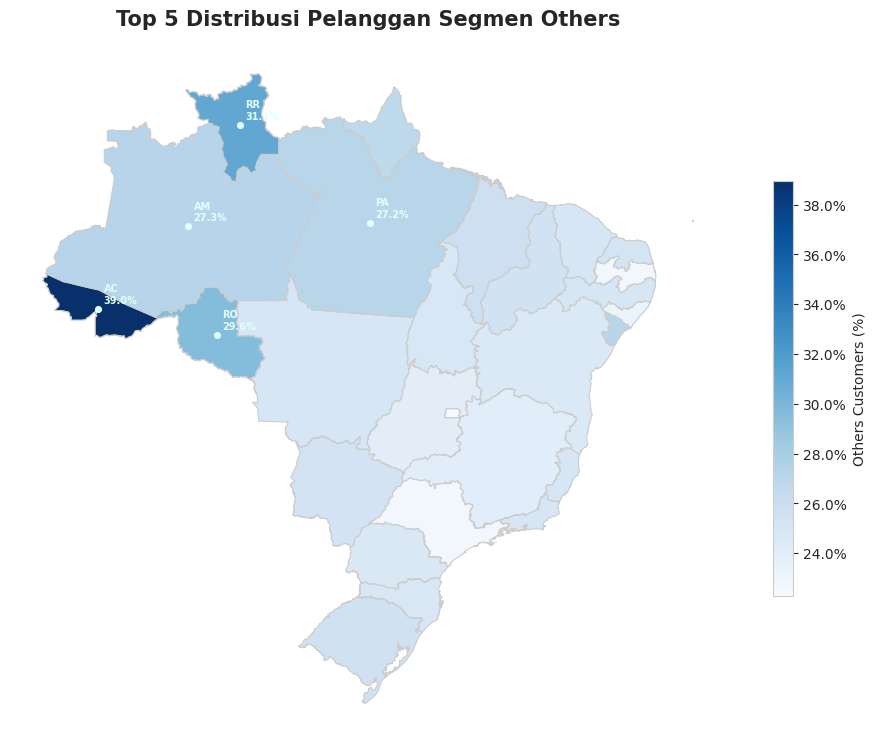

In [103]:
selected_segment = 'Others'

# Filter data RFM untuk segmen yang dipilih
segment_data_for_map = customer_geo_segment_readable[
    customer_geo_segment_readable['Segment'] == selected_segment
].copy()

# Rename 'customer_state' to 'sigla' to match GeoJSON column name for state abbreviations
segment_data_for_map = segment_data_for_map.rename(columns={'customer_state': 'sigla'})

# Menggabungkan data geografis dengan data RFM segmen yang dipilih
merged_map_data = brazil_states_gdf.merge(
    segment_data_for_map,
    on='sigla',
    how='left'
)

# Mengisi NaN (negara bagian tanpa data) dengan 0 untuk visualisasi
merged_map_data['Segment Percentage (%)'] = merged_map_data['Segment Percentage (%)'].fillna(0)

# Instantiate and generate the map for the current segment
map_generator = ChoroplethMapGenerator(merged_map_data, selected_segment, top_n=5)
map_generator.generate_map()

**Insight**:
* **Distribusi Luas**: Segmen 'Others' tersebar luas di hampir semua provinsi di Brasil. Hal ini wajar mengingat ini adalah kategori tangkap-semua untuk pelanggan yang tidak masuk ke segmen RFM yang lebih spesifik.
* **Konsentrasi di Provinsi Besar**: Mirip dengan segmen lainnya, segmen 'Others' menunjukkan konsentrasi yang lebih tinggi (dalam hal kontribusi persentase terhadap total pelanggan di provinsi) di provinsi yang padat penduduk seperti Sao Paulo (SP), Rio de Janeiro (RJ), Minas Gerais (MG), dan provinsi lain di wilayah Tenggara dan Selatan. Ini mencerminkan distribusi keseluruhan basis pelanggan.
* **Proporsi yang Beragam**: Meskipun hadir di mana-mana, *proporsi* pelanggan 'Others' dalam total basis pelanggan tiap provinsi dapat bervariasi. Provinsi dengan jumlah pelanggan yang lebih sedikit mungkin menunjukkan persentase 'Others' yang relatif lebih tinggi atau lebih rendah tergantung pada faktor lokal tertentu atau prevalensi pelanggan 'Champions', 'Loyal', 'New', atau 'At Risk'.

#### Insight Visualisasi Geografis Distribusi Segmen Pelanggan


Wawasan distribusi geografis secara keseluruhan untuk semua segmen RFM mengungkapkan pola yang konsisten: pelanggan paling bernilai (`Champions`, `New Customers`, `Loyal Customers`, `At Risk`) sebagian besar terkonsentrasi di negara bagian tenggara Brasil yang lebih maju.

**Temuan Utama Analisis Data**

* **Segmen Champions**: Konsentrasi tertinggi pelanggan 'Champions' ditemukan di wilayah Tenggara Brasil, khususnya di São Paulo (SP), Rio de Janeiro (RJ), Minas Gerais (MG), dan Paraná (PR). São Paulo (SP) disorot sebagai pasar utama karena proporsi signifikan pelanggan bernilai tinggi ini.

* **Segmen New Customers**: 'New Customers' sangat terkonsentrasi di wilayah metropolitan dan daerah berpenduduk padat seperti São Paulo (SP), Rio de Janeiro (RJ), dan Minas Gerais (MG), mencerminkan distribusi basis pelanggan secara keseluruhan.

* **Segmen Loyal Customers**: Serupa dengan segmen lainnya, 'Loyal Customers' juga menunjukkan konsentrasi tertinggi mereka di wilayah metropolitan São Paulo (SP), Rio de Janeiro (RJ), dan Minas Gerais (MG), yang menunjukkan bahwa wilayah-wilayah ini merupakan basis inti untuk loyalitas pelanggan.

* **Segmen At Risk Customers**: Segmen 'At Risk' juga menunjukkan konsentrasi yang signifikan di São Paulo (SP), diikuti oleh negara bagian berpenduduk besar lainnya seperti Rio de Janeiro (RJ), Minas Gerais (MG), dan Rio Grande do Sul (RS). Hal ini menunjukkan bahwa wilayah-wilayah ini memiliki jumlah pelanggan terbesar yang memerlukan upaya retensi.

* **Segmen Others Customers**: Segmen 'Others' tersebar luas di hampir seluruh negara bagian Brasil tetapi tetap menunjukkan konsentrasi yang lebih tinggi di negara bagian utama seperti São Paulo (SP), Rio de Janeiro (RJ), dan Minas Gerais (MG), yang mencerminkan distribusi populasi pelanggan secara umum.

* **Dominasi Regional yang Konsisten**: Di seluruh segmen RFM, negara bagian di wilayah Tenggara (terutama São Paulo, Rio de Janeiro, dan Minas Gerais) secara konsisten muncul sebagai wilayah kunci karena kepadatan penduduk yang lebih tinggi, aktivitas ekonomi, dan kemungkinan infrastruktur e-commerce yang lebih baik.


#### Memeriksa Skor Ulasan berdasarkan Segmen RFM

⭐ Rata-rata Review Score per Segmen RFM


,Segment,review_score
1,Champions,4.16
3,New Customers,4.15
0,At Risk,4.08
4,Others,4.05
2,Loyal Customers,4.02


/tmp/ipython-input-2492709532.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


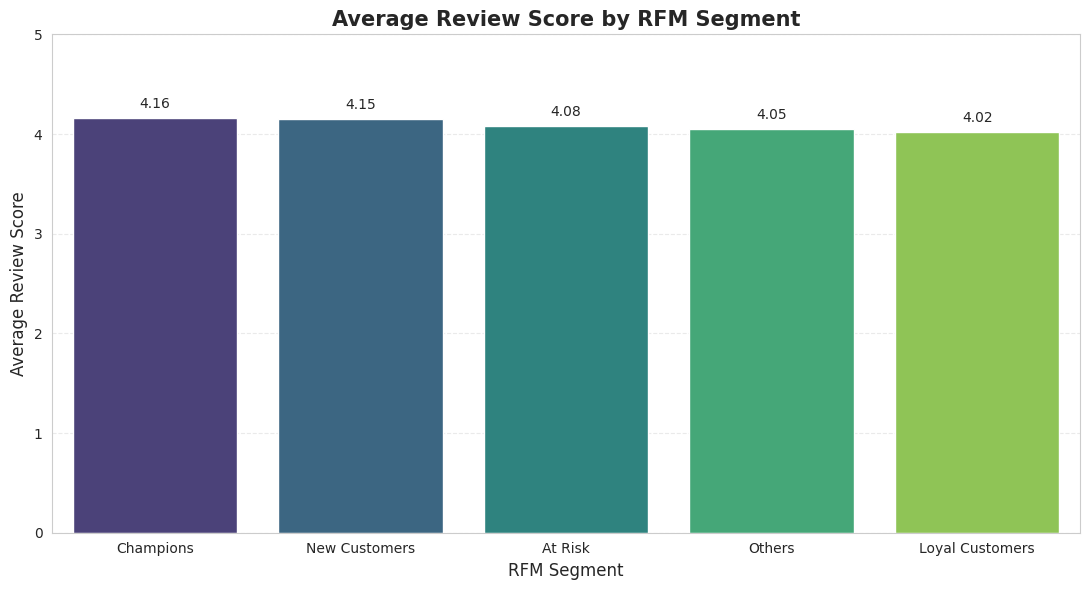

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================
# Menghitung rata-rata review score
# untuk setiap segmen RFM
# ======================================
rfm_review_scores = (
    master_orders
    .groupby("Segment", as_index=False)["review_score"]
    .mean()
    .round(2)  # Membulatkan agar mudah dibaca
    .sort_values("review_score", ascending=False)
)

print("⭐ Rata-rata Review Score per Segmen RFM")
display(rfm_review_scores)

# ======================================
# Visualisasi rata-rata review score
# ======================================
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=rfm_review_scores,
    x="Segment",
    y="review_score",
    palette="viridis"
)

# Judul dan label yang komunikatif
plt.title("Average Review Score by RFM Segment", fontsize=15, weight="bold")
plt.xlabel("RFM Segment", fontsize=12)
plt.ylabel("Average Review Score", fontsize=12)

# Menambahkan label nilai di atas setiap bar
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 5),
        textcoords="offset points"
    )

# Memperjelas sumbu Y
plt.ylim(0, 5)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


Insight (Skor Ulasan berdasarkan Segmen RFM):
- **Champions dan New Customers memimpin dalam kepuasan**: Segmen 'Champions' dan 'New Customers' menunjukkan rata-rata skor ulasan tertinggi (masing-masing sekitar 4,16 dan 4,15). Hal ini wajar untuk 'Champions' karena mereka merupakan pelanggan paling bernilai dan paling terlibat, yang mencerminkan tingkat kepuasan mereka. Bagi 'New Customers', tingkat kepuasan awal yang tinggi sangat penting untuk retensi.
- **At Risk dan Others memiliki kepuasan moderat**: Segmen 'At Risk' dan 'Others' memiliki rata-rata skor ulasan yang sedikit lebih rendah (sekitar 4,08 dan 4,05). Meskipun masih tergolong positif, hal ini menunjukkan adanya potensi area untuk perbaikan atau menjadi alasan mengapa pelanggan dalam segmen ini kurang terlibat atau berisiko untuk churn.
- **Loyal Customers justru paling rendah**: Segmen 'Loyal Customers' memiliki rata-rata skor ulasan terendah di antara segmen yang dikategorikan (sekitar 4,02). Ini merupakan temuan yang menarik dan berpotensi mengkhawatirkan. Meskipun mereka loyal (sebagaimana didefinisikan oleh frekuensi pembelian), tingkat kepuasan mereka tidak setinggi 'Champions' atau 'New Customers'. Hal ini dapat mengindikasikan perlunya intervensi khusus atau program loyalitas yang dapat meningkatkan pengalaman mereka, karena loyalitas tidak selalu berarti kepuasan puncak.
- **Kepuasan tinggi secara keseluruhan**: Di seluruh segmen, rata-rata skor ulasan berada di atas 4, yang menunjukkan tingkat kepuasan pelanggan yang secara umum tinggi pada platform. Namun, perbedaan kecil antar segmen menyoroti adanya peluang untuk strategi yang lebih tertarget guna meningkatkan kepuasan, terutama bagi 'Loyal Customers' dan pelanggan yang 'At Risk'.

#### Insight (RFM Analysis)

**Temuan Utama Analisis Data**

* **Karakteristik Segmen RFM:**
  * **Champions:** Menunjukkan rata-rata Recency terendah (sekitar 140 hari) dan nilai Monetary rata-rata tertinggi (sekitar R\$179,49), yang mengindikasikan pelanggan yang baru **melakukan** pembelian dan memiliki pengeluaran tinggi dengan frekuensi sedang (1,10).
  * **New Customers:** Menunjukkan rata-rata Recency yang rendah (sekitar 141 hari) dan nilai Monetary rata-rata yang moderat (sekitar R\$164,65), namun dengan frekuensi terendah (1,00).
  * **Loyal Customers:** Memiliki rata-rata Recency yang lebih tinggi (sekitar 219 hari) dibandingkan Champions dan New Customers, dengan nilai Monetary (R\$161,73) dan frekuensi (1,04) yang moderat.
  * **At Risk:** Menunjukkan rata-rata Recency yang jauh lebih tinggi (sekitar 446 hari) tetapi dengan nilai Monetary (R\$168,84) dan frekuensi (1,05) yang moderat, yang menunjukkan bahwa mereka sebelumnya aktif namun sudah lama tidak melakukan pembelian.
  * **Others:** Memiliki rata-rata Recency tertinggi (sekitar 389 hari) dan frekuensi terendah (1,00) dengan nilai Monetary yang moderat (R\$161,06), yang mengindikasikan tingkat keterlibatan yang lebih rendah.

* **Preferensi Produk berdasarkan Segmen:**
  * Kategori seperti `bed_bath_table`, `health_beauty`, `furniture_decor`, dan `sports_leisure` secara konsisten populer di sebagian besar segmen RFM.
  * `Champions` dan `New Customers` menunjukkan minat yang kuat pada `health_beauty`, `bed_bath_table`, dan `housewares`.
  * `Loyal Customers` juga lebih menyukai `computers_accessories`.

* **Distribusi Geografis:**
  * Sao Paulo (SP) merupakan negara bagian yang dominan dengan jumlah pelanggan tertinggi di seluruh segmen RFM.
  * Distribusi proporsional segmen RFM relatif konsisten di negara bagian teratas, yang menunjukkan pola perilaku pelanggan yang serupa di wilayah-wilayah utama.

* **Kepuasan Pelanggan (Skor Ulasan):**
  * `Champions` dan `New Customers` menunjukkan skor ulasan rata-rata tertinggi (masing-masing sekitar 4,16 dan 4,15), yang mengindikasikan tingkat kepuasan yang tinggi.
  * Segmen `At Risk` dan `Others` memiliki skor ulasan rata-rata yang sedikit lebih rendah (sekitar 4,08 dan 4,05).
  * `Loyal Customers` secara mengejutkan memiliki skor ulasan rata-rata terendah di antara segmen yang dikategorikan (sekitar 4,02), meskipun mereka tergolong loyal.


Analisis RFM telah memberikan pemahaman mendalam tentang segmentasi pelanggan dan perilaku mereka, memungkinkan perumusan strategi yang lebih terarah:

-   **Metrik RFM Rata-rata per Segmen**: Segmentasi telah berhasil mengelompokkan pelanggan berdasarkan perilaku pembelian mereka. Pelanggan 'Champions' adalah yang paling aktif dan menghabiskan paling banyak, sementara 'New Customers' memiliki recency yang baik tetapi frekuensi rendah. Segmen 'At Risk' menunjukkan recency yang buruk tetapi secara historis memiliki pengeluaran yang moderat, menjadikannya target penting untuk upaya retensi.

-   **Preferensi Produk Berdasarkan Segmen**: Terdapat kategori produk yang secara konsisten populer di hampir semua segmen RFM, seperti `bed_bath_table`, `health_beauty`, `furniture_decor`, dan `sports_leisure`. Ini menunjukkan daya tarik universal kategori-kategori ini. Preferensi spesifik juga muncul di beberapa segmen, misalnya `Loyal Customers` juga menyukai `computers_accessories` dan `Champions`/`New Customers` menyukai `housewares`. Informasi ini krusial untuk strategi *cross-selling* dan *upselling* yang ditargetkan.

-   **Distribusi Geografis Segmen RFM**: Sao Paulo (SP) adalah pusat pelanggan terbesar di semua segmen RFM, menegaskan perannya sebagai pasar utama. Distribusi proporsional segmen RFM yang relatif konsisten di negara bagian-negara bagian teratas menunjukkan pola perilaku pelanggan yang serupa di wilayah utama, meskipun perbedaan kecil dapat dimanfaatkan untuk kampanye regional yang disesuaikan.

-   **Skor Ulasan Berdasarkan Segmen RFM**: Pelanggan 'Champions' dan 'New Customers' menunjukkan kepuasan tertinggi, yang penting untuk mempertahankan pelanggan baru dan menghargai pelanggan terbaik. Namun, **'Loyal Customers' memiliki rata-rata skor ulasan terendah**, sebuah temuan krusial yang memerlukan investigasi lebih lanjut dan intervensi untuk meningkatkan pengalaman mereka meskipun loyalitas mereka. Segmen 'At Risk' dan 'Others' memiliki kepuasan moderat, yang bisa menjadi indikator area perbaikan.

Secara keseluruhan, analisis RFM ini memberikan gambaran yang jelas tentang siapa pelanggan Anda, bagaimana mereka berperilaku, apa yang mereka beli, di mana mereka berada, dan seberapa puas mereka. Ini adalah dasar yang kuat untuk mengembangkan strategi pemasaran, retensi, dan peningkatan layanan yang dipersonalisasi.

#### Merumuskan Rekomendasi Bisnis yang Dapat Ditindaklanjuti

Berdasarkan semua wawasan yang dikumpulkan dari analisis RFM yang ditingkatkan, termasuk karakteristik segmen, preferensi produk, pola geografis, dan tingkat kepuasan, rumuskan rekomendasi bisnis yang konkret dan dapat ditindaklanjuti yang disesuaikan untuk setiap segmen pelanggan. Ini dapat mencakup strategi retensi untuk pelanggan 'Berisiko', upselling/cross-selling untuk 'Juara' dan 'Pelanggan Setia', atau strategi aktivasi untuk 'Pelanggan Baru'.

##### Wawasan Konsolidasi untuk Rekomendasi Bisnis:

1.  **Metrik RFM Rata-rata per Segmen (`rfm_avg_metrics`):**
    *   **Juara (Champions):** Recency terendah (140 hari), Frekuensi sedang (1.10), dan nilai Moneter tertinggi (Rp179.49). Ini adalah pelanggan yang baru saja membeli, agak sering (dalam konteks dataset ini), dan pengeluaran tinggi.
    *   **Pelanggan Baru (New Customers):** Recency rendah (141 hari), Frekuensi terendah (1.00), dan Moneter sedang (Rp164.65). Pelanggan ini baru saja melakukan pembelian pertama mereka.
    *   **Pelanggan Setia (Loyal Customers):** Recency sedang (219 hari), Frekuensi sedang (1.04), dan Moneter sedang (Rp161.73).
    *   **Berisiko (At Risk):** Recency tinggi (446 hari), Frekuensi sedang (1.05), dan Moneter sedang (Rp168.84). Mereka sudah lama tidak membeli tetapi dulunya adalah pembeli yang cukup sering dan menghabiskan cukup banyak uang.
    *   **Lainnya (Others):** Recency tertinggi (389 hari), Frekuensi terendah (1.00), dan Moneter sedang (Rp161.06). Ini adalah kelompok yang beragam, tetapi secara umum kurang terlibat dan kurang aktif baru-baru ini.

2.  **Preferensi Produk berdasarkan Segmen RFM:**
    *   **Kategori Populer Konsisten:** `bed_bath_table`, `health_beauty`, `furniture_decor`, dan `sports_leisure` secara konsisten populer di sebagian besar segmen.
    *   **Juara:** Preferensi kuat untuk `health_beauty`, `bed_bath_table`, `housewares`, `sports_leisure`.
    *   **Pelanggan Baru:** Juga menunjukkan minat tinggi pada `health_beauty`, `bed_bath_table`, dan `housewares`.
    *   **Berisiko:** Lebih suka `bed_bath_table`, `furniture_decor`, `sports_leisure`, `health_beauty`.

3.  **Distribusi Geografis Segmen RFM:**
    *   **Dominasi Sao Paulo (SP):** SP memiliki jumlah pelanggan tertinggi di seluruh segmen RFM, menjadi pasar utama.
    *   **Proporsi Konsisten:** Untuk sebagian besar negara bagian teratas, distribusi segmen RFM relatif konsisten, menunjukkan pola perilaku yang serupa di wilayah utama.

4.  **Skor Ulasan Rata-rata berdasarkan Segmen RFM (`rfm_review_scores`):**
    *   **Juara & Pelanggan Baru:** Memiliki skor ulasan rata-rata tertinggi (masing-masing 4.16 dan 4.15), menunjukkan kepuasan tinggi.
    *   **Berisiko & Lainnya:** Memiliki skor ulasan rata-rata sedikit lebih rendah (masing-masing sekitar 4.08 dan 4.05), menunjukkan potensi ketidakpuasan atau masalah yang belum terselesaikan.
    *   **Pelanggan Setia:** Anehnya, memiliki skor ulasan rata-rata terendah di antara segmen yang ditentukan (4.02), terlepas dari kesetiaan mereka. Ini perlu perhatian.

##### Rekomendasi Bisnis yang Dapat Ditindaklanjuti per Segmen:

---

**1. Juara (Champions) (R-score >= 4 dan F-score >= 4)**

*   **Profil:** Ini adalah pelanggan terbaik Anda – mereka membeli baru-baru ini, relatif sering (dalam konteks dataset ini), dan menghabiskan paling banyak. Mereka sangat puas.
*   **Rekomendasi:**
    *   **Pertahankan Kesetiaan & Dorong Advokasi:** Tawarkan keuntungan eksklusif, akses awal ke produk baru (terutama di `health_beauty`, `bed_bath_table`, `housewares`), dan komunikasi yang dipersonalisasi. Dorong mereka untuk menjadi advokat merek melalui program referral atau komunitas VIP. Mengingat kepuasan mereka yang tinggi, mereka adalah kandidat utama untuk testimonial dan ulasan.
    *   **Upselling & Cross-selling:** Perkenalkan versi premium dari produk yang sering mereka beli atau item pelengkap dalam kategori pilihan mereka. Manfaatkan riwayat pembelian mereka untuk rekomendasi yang sangat terarah.

---

**2. Pelanggan Setia (Loyal Customers) (R-score >= 3 dan F-score >= 3)**

*   **Profil:** Pelanggan reguler yang telah menunjukkan komitmen, tetapi aktivitas terbaru mereka mungkin moderat, dan kepuasan mereka secara mengejutkan adalah yang terendah di antara segmen yang ditentukan. Mereka lebih suka `bed_bath_table`, `health_beauty`, `computers_accessories`.
*   **Rekomendasi:**
    *   **Tingkatkan Kepuasan & Cegah Churn:** Selidiki alasan di balik skor ulasan mereka yang relatif lebih rendah. Lakukan survei atau analisis komentar ulasan terperinci untuk mengidentifikasi masalah umum (misalnya, kualitas produk, masalah pengiriman di wilayah tertentu). Tawarkan dukungan proaktif dan diskon yang dipersonalisasi pada kategori pilihan mereka untuk melibatkan kembali mereka. Terapkan program loyalitas yang memberikan penghargaan untuk pembelian berulang.
    *   **Cross-sell & Upsell:** Berdasarkan riwayat pembelian mereka, rekomendasikan produk baru atau peningkatan, terutama di `computers_accessories` dan `health_beauty`. Gabungkan produk yang sering dibeli bersama.

---

**3. Pelanggan Baru (New Customers) (R-score >= 4 dan F-score <= 2)**

*   **Profil:** Pelanggan yang baru saja diperoleh dengan kepuasan tinggi tetapi frekuensi rendah. Mereka tertarik pada `health_beauty`, `bed_bath_table`, `housewares`.
*   **Rekomendasi:**
    *   **Kembangkan Keterlibatan & Dorong Pembelian Berulang:** Terapkan proses orientasi yang kuat dengan email seri selamat datang. Berikan konten bernilai tambah yang terkait dengan pembelian pertama mereka. Tawarkan insentif untuk pembelian kedua mereka, dengan fokus pada kategori yang serupa dengan minat awal mereka (`health_beauty`, `bed_bath_table`) atau produk pelengkap. Pastikan dukungan purnajual yang luar biasa untuk mempertahankan kepuasan awal mereka yang tinggi.
    *   **Konten Edukasi:** Berikan panduan atau tips tentang cara memaksimalkan penggunaan produk yang mereka beli.

---

**4. Berisiko (At Risk) (R-score <= 2 dan F-score >= 3)**

*   **Profil:** Pelanggan yang dulunya aktif dan menghabiskan banyak uang tetapi sudah lama tidak membeli. Kepuasan mereka sedang. Mereka lebih suka `bed_bath_table`, `furniture_decor`, `sports_leisure`, `health_beauty`. Mereka juga berkontribusi paling banyak terhadap total pendapatan.
*   **Rekomendasi:**
    *   **Kampanye Keterlibatan Ulang (Re-engagement Campaigns):** Kembangkan kampanye win-back yang ditargetkan. Tawarkan diskon yang dipersonalisasi atau penawaran eksklusif pada kategori produk yang sebelumnya mereka beli atau sukai (`bed_bath_table`, `furniture_decor`, `sports_leisure`).
    *   **Atasi Masalah:** Selidiki alasan di balik ketidakaktifan mereka. Analisis ulasan negatif sebelumnya atau interaksi dukungan. Jika pola geografis pelanggan 'Berisiko' muncul, atasi potensi masalah logistik lokal atau ketersediaan produk.
    *   **Umpan Balik & Pendekatan Pelanggan:** Lakukan survei atau kirim pesan pribadi untuk memahami kebutuhan mereka saat ini dan mengapa mereka berhenti membeli. Soroti kedatangan produk baru atau peningkatan yang mungkin mengatasi kekhawatiran mereka sebelumnya.

---

**5. Lainnya (Others) (Semua segmen lainnya)**

*   **Profil:** Kelompok yang beragam, umumnya kurang terlibat, dengan recency yang lebih tinggi dan frekuensi yang lebih rendah. Nilai moneter mereka sedang, dan kepuasan sedikit lebih rendah.
*   **Rekomendasi:**
    *   **Aktivasi & Migrasi:** Identifikasi sub-segmen dalam 'Lainnya' berdasarkan perilaku spesifik. Untuk pelanggan yang tidak aktif, jalankan kampanye kesadaran umum. Untuk pelanggan dengan nilai moneter rendah, tawarkan produk atau paket tingkat pemula. Targetkan mereka dengan promosi pada kategori populer (`bed_bath_table`, `sports_leisure`, `furniture_decor`) untuk mendorong pembelian signifikan pertama mereka.
    *   **Pemasaran Edukasi:** Berikan konten yang menunjukkan proposisi nilai platform dan produk populer untuk menarik minat dan berpotensi memindahkan mereka ke 'Pelanggan Baru' atau bahkan 'Pelanggan Setia'.

## Conclution

### Kesimpulan Pertanyaan Bisnis 1: Faktor apa saja yang paling berpengaruh terhadap kepuasan pelanggan (review score) pada platform e-commerce?

Faktor-faktor utama yang paling berpengaruh terhadap kepuasan pelanggan, sebagaimana tercermin dari `review_score`, adalah:

1.  **Waktu Pengiriman (`delivery_time_days`)**: Ini adalah faktor paling dominan dengan korelasi negatif yang kuat. Semakin lama waktu pengiriman, semakin rendah `review_score` yang diberikan pelanggan. Pesanan dengan skor 1.0 memiliki rata-rata waktu pengiriman terlama (sekitar 21 hari), sedangkan skor 5.0 memiliki rata-rata waktu pengiriman tercepat (sekitar 10 hari).
2.  **Status Pesanan (`order_status`)**: Status pesanan secara langsung memengaruhi kepuasan. Pesanan yang dibatalkan (`canceled`) atau tidak tersedia (`unavailable`) menghasilkan `review_score` yang sangat rendah atau tidak ada. Sebaliknya, pesanan yang berhasil terkirim (`delivered`) memiliki rata-rata `review_score` yang jauh lebih tinggi.
3.  **Kategori Produk (`product_category_name_english`)**: Terdapat variasi kepuasan yang signifikan antar kategori. Kategori seperti `cds_dvds_musicals` dan `fashion_childrens_clothes` memiliki skor tinggi, sedangkan `security_and_services` dan `office_furniture` cenderung memiliki skor rendah.
4.  **Lokasi Pelanggan (`customer_state`)**: Ada perbedaan geografis dalam kepuasan pelanggan, menunjukkan bahwa faktor regional (misalnya, logistik atau ketersediaan produk) mungkin berperan. Negara bagian seperti AP, AM, dan PR menunjukkan skor ulasan rata-rata yang lebih tinggi, sementara RR, AL, dan MA memiliki skor yang lebih rendah.

Faktor-faktor seperti total harga produk, ongkos kirim (dalam batas normal), jumlah item, jumlah penjual unik, dan jumlah metode pembayaran tidak menunjukkan korelasi kuat atau pola signifikan dengan `review_score`.


### Kesimpulan Pertanyaan Bisnis 2: Karakteristik pelanggan seperti apa yang memberikan nilai transaksi tertinggi, dan bagaimana pola perilaku belanjanya?

Pelanggan dengan nilai transaksi tertinggi (segmen 'High Value' atau kontributor pendapatan terbesar dalam RFM seperti 'At Risk' dan 'Champions') memiliki karakteristik dan pola perilaku belanja sebagai berikut:

1.  **Karakteristik Pelanggan Bernilai Transaksi Tertinggi**:
    *   **Nilai Pesanan Rata-rata Tinggi**: Mereka dicirikan oleh nilai rata-rata pesanan (`avg_order_value`) yang sangat tinggi, bukan oleh frekuensi pembelian yang sering. Pelanggan 'High Value' memiliki rata-rata pengeluaran dan nilai pesanan yang jauh lebih tinggi dibandingkan segmen lainnya.
    *   **Kontribusi Pendapatan Signifikan**: Segmen 'At Risk' dan 'Champions' adalah kontributor pendapatan terbesar, menunjukkan bahwa pelanggan yang berisiko (dulunya aktif) dan pelanggan juara adalah kunci bagi total pendapatan.

2.  **Pola Perilaku Belanja**:
    *   **Frekuensi Pembelian Rendah**: Sebagian besar pelanggan, termasuk yang bernilai tinggi, adalah pembeli tunggal atau memiliki frekuensi pembelian yang sangat rendah (`total_orders` rata-rata mendekati 1). Ini mengindikasikan model bisnis yang lebih mengarah pada transaksi besar satu kali daripada pembelian berulang yang sering.
    *   **Preferensi Produk Spesifik**: Pelanggan bernilai tinggi menunjukkan preferensi yang jelas terhadap kategori produk tertentu. Kategori teratas yang sering dibeli oleh mereka adalah `bed_bath_table`, `computers_accessories`, `furniture_decor`, `health_beauty`, dan `watches_gifts`.
    *   **Konsentrasi Geografis**: Pelanggan bernilai tinggi, seperti semua segmen RFM, terkonsentrasi di wilayah geografis tertentu, terutama Sao Paulo (SP), yang merupakan pasar utama dengan kontribusi pendapatan tertinggi.
    *   **Kompleksitas Pembayaran Tidak Signifikan**: Tidak ada korelasi signifikan antara jumlah jenis pembayaran yang digunakan (`payment_types`) dan total pengeluaran, menunjukkan bahwa kompleksitas pembayaran bukan pembeda untuk pelanggan bernilai tinggi.

## Menyimpan Semua Dataframe yang Relevan ke File CSV untuk Dashboard Streamlit

In [488]:
# Menyimpan DataFrame master_orders (data transaksi utama yang terintegrasi)
master_orders.to_csv('master_orders.csv', index=False)
print("master_orders.csv berhasil disimpan.")

# Menyimpan DataFrame rfm (hasil segmentasi RFM pelanggan)
rfm.to_csv('rfm_segmentation.csv', index=False)
print("rfm_segmentation.csv berhasil disimpan.")

# Menyimpan DataFrame category_review_scores (rata-rata skor ulasan per kategori produk)
category_review_scores.to_csv('category_review_scores.csv', index=False)
print("category_review_scores.csv berhasil disimpan.")

# Menyimpan DataFrame state_review_summary (rata-rata skor ulasan per negara bagian)
state_review_summary.to_csv('state_review_summary.csv', index=False)
print("state_review_summary.csv berhasil disimpan.")

# Menyimpan DataFrame monthly_revenue (tren pendapatan bulanan)
monthly_revenue_df = monthly_revenue.reset_index()
monthly_revenue_df.columns = ['month', 'total_revenue']
monthly_revenue_df.to_csv('monthly_revenue.csv', index=False)
print("monthly_revenue.csv berhasil disimpan.")

# Menyimpan DataFrame orders_monthly (volume pesanan bulanan)
orders_monthly_df = orders_monthly.reset_index()
orders_monthly_df.columns = ['month', 'order_count']
orders_monthly_df.to_csv('orders_monthly.csv', index=False)
print("orders_monthly.csv berhasil disimpan.")

# Menyimpan DataFrame high_value_product_preferences (preferensi produk pelanggan bernilai tinggi)
high_value_product_preferences.to_csv('high_value_product_preferences.csv', index=True)
print("high_value_product_preferences.csv berhasil disimpan.")

# Menyimpan DataFrame customer_value (ringkasan nilai pelanggan berdasarkan total pengeluaran)
customer_value.to_csv('customer_value.csv', index=False)
print("customer_value.csv berhasil disimpan.")

# Menyimpan DataFrame payment_customer (analisis metode pembayaran dan nilai pelanggan)
payment_customer.to_csv('payment_customer.csv', index=False)
print("payment_customer.csv berhasil disimpan.")

# Menyimpan DataFrame items_products (detail item pesanan dan produk)
items_products.to_csv('items_products.csv', index=False)
print("items_products.csv berhasil disimpan.")

print("Semua file data yang relevan telah disimpan ke CSV.")

master_orders.csv berhasil disimpan.
rfm_segmentation.csv berhasil disimpan.
category_review_scores.csv berhasil disimpan.
state_review_summary.csv berhasil disimpan.
monthly_revenue.csv berhasil disimpan.
orders_monthly.csv berhasil disimpan.
high_value_product_preferences.csv berhasil disimpan.
customer_value.csv berhasil disimpan.
payment_customer.csv berhasil disimpan.
items_products.csv berhasil disimpan.
Semua file data yang relevan telah disimpan ke CSV.


## Mengarsipkan Semua Data CSV yang Disimpan ke dalam File ZIP

In [489]:
import zipfile
import os

# Daftar file CSV yang akan dimasukkan ke dalam zip
csv_files = [
    'master_orders.csv',
    'rfm_segmentation.csv',
    'category_review_scores.csv',
    'state_review_summary.csv',
    'monthly_revenue.csv',
    'orders_monthly.csv',
    'high_value_product_preferences.csv',
    'customer_value.csv',
    'payment_customer.csv',
    'items_products.csv'
]

# Nama file zip yang akan dibuat
zip_filename = 'streamlit_dashboard_data.zip'

# Membuat file zip
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in csv_files:
        if os.path.exists(file):
            zipf.write(file, os.path.basename(file))
            print(f"Menambahkan {file} ke {zip_filename}")
        else:
            print(f"Peringatan: File {file} tidak ditemukan dan tidak akan ditambahkan ke zip.")

print(f"\nSemua file CSV yang tersedia telah digabungkan ke {zip_filename}.")
print(f"Anda dapat mengunduh '{zip_filename}' dari panel file Colab Anda.")

Menambahkan master_orders.csv ke streamlit_dashboard_data.zip
Menambahkan rfm_segmentation.csv ke streamlit_dashboard_data.zip
Menambahkan category_review_scores.csv ke streamlit_dashboard_data.zip
Menambahkan state_review_summary.csv ke streamlit_dashboard_data.zip
Menambahkan monthly_revenue.csv ke streamlit_dashboard_data.zip
Menambahkan orders_monthly.csv ke streamlit_dashboard_data.zip
Menambahkan high_value_product_preferences.csv ke streamlit_dashboard_data.zip
Menambahkan customer_value.csv ke streamlit_dashboard_data.zip
Menambahkan payment_customer.csv ke streamlit_dashboard_data.zip
Menambahkan items_products.csv ke streamlit_dashboard_data.zip

Semua file CSV yang tersedia telah digabungkan ke streamlit_dashboard_data.zip.
Anda dapat mengunduh 'streamlit_dashboard_data.zip' dari panel file Colab Anda.
